In [1]:
_MERKZETTEL = {}


def merke(schluessel, wert):
    """Haelt ein Ergebnis fuer den Fliesstext fest und gibt es zurueck."""
    _MERKZETTEL[schluessel] = wert
    return wert

# Regression: Was kostet die Fahrt zu diesem Ziel?

**Verfahren:** Regression (überwachtes Lernen, Zielgröße ist eine Zahl)  |  **Geschäftsfrage:** Können wir dem Kunden vor der Fahrt sagen, was sie kosten wird?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/01_Regression_Fahrtdauer.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Phase</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Leitfrage</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Business Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Was ist die Geschäftsfrage — und woran messen wir Erfolg?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Data Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche Daten haben wir, und taugen sie für diese Frage?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Data Preparation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">4</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Modeling</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welches Verfahren, welche Einstellungen, wie geprüft?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">5</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Evaluation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">6</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Deployment</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie kommt das Modell in den Betrieb — und was passiert danach?</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

> ### Kurzfassung
>
> **Fragestellung.** Die Kundschaft soll den Preis kennen, bevor sie losfährt. Er ergibt
> sich aus der Fahrtdauer, und die steht zum Zeitpunkt der Anfrage noch nicht fest.
>
> **Vorgehen.** Geschätzt wird keine einzelne Zahl, sondern eine **Spanne** für die
> Dauer, die das Tarifblatt in einen Preisbereich umrechnet. Drei Verfahren treten
> gegeneinander an; welches ausgeliefert wird, entscheidet eine vor der Messung
> festgelegte Auswahlregel.
>
> **Ergebnis.** Alle drei geprüften Verfahren bestehen sämtliche Hürden. Ausgeliefert wird die **Perzentiltabelle** — nicht
> wegen besserer Prognosegüte,
> sondern weil die Auswahlregel bei gleicher Eignung die einfachere Betriebsform
> bevorzugt. Die Zusage von 80 % ist auf dem versiegelten
> Abnahmezeitraum belegt: **81,1 %**, 7 von
> 7 Gates halten. Beantwortet werden 34 % der
> Anfragen; in den übrigen Fällen gibt die Anwendung keine Auskunft.
>
> **Status: sichtbar** — die Anzeige ist freigeschaltet. Die Auskunft gilt für Fahrten bis zum
> 07.11.2026.
>
> **Was offen bleibt.** In 21 % der Fahrten weicht das tatsächliche
> Ende vom angegebenen Ziel ab. Die Zusage trägt deshalb eine Bedingung, die in jeder
> Antwort der Anwendung mitgeteilt wird.

## Warum eine Spanne und keine Zahl

Die naheliegende Idee lautet: Beim Entsperren schätzt ein Modell die Fahrtdauer, das
Tarifblatt macht daraus einen Preis, die App zeigt ihn an.

Diese Idee hat einen Fehler, und zwar keinen technischen.

> **Der Nutzer weiß besser als jedes Modell, wie lange er fahren wird.** Er kennt sein
> Ziel, er weiß, ob er es eilig hat, und er weiß, ob er unterwegs anhält.

Ein Modell, das beim Entsperren nur Startstation, Uhrzeit und Wochentag kennt, kann zwei
Fahrten nicht unterscheiden, die gleich beginnen und völlig verschieden verlaufen: acht
Minuten zum Bahnhof gegen neunzig Minuten die Mainpromenade entlang.

Das ist kein Problem des Verfahrens, sondern ein Informationsproblem. **Also ändern wir
nicht das Verfahren, sondern den Prozess:** Der Nutzer wählt in der App sein Ziel, und
*erst danach* rechnet das Modell.

Daraus folgt die Einsicht, die dieses Notebook trägt:

> Ob ein Merkmal verwendet werden darf, entscheidet nicht sein Spaltenname, sondern der
> **Zeitpunkt, zu dem es im Prozess entsteht**. Ändert man den Prozess, ändert sich die
> Antwort.

Und daraus folgt sofort die erste Einschränkung, die wir offen benennen müssen.

## Vier Begriffe zum Freigabestand

Diese sechs Notebooks liefern am Ende sehr verschiedene Dinge aus, und die Wörter dafür
werden im Alltag als Synonyme benutzt. Hier sind sie es nicht:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Wort</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Was es heißt</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Was es <strong>nicht</strong> heißt</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>qualifiziert</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Die vorab festgelegten Gütekriterien halten auf den vorhandenen Daten</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">dass jemand das Ergebnis zu sehen bekommt — dieses Notebook nennt den Zustand <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">GATES_HALTEN</code></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Schattenbetrieb</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Das Verfahren rechnet mit, Ergebnisse werden protokolliert, <strong>niemand sieht sie und niemand handelt danach</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">eine abgeschwächte Freigabe</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Pilot</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Ein begrenzter, befristeter echter Einsatz mit benanntem Abbruchkriterium und Kontrollmöglichkeit</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ein Test</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>operativer Einsatz</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Das Ergebnis wirkt ohne weitere Prüfung auf Kundschaft, Personal oder Geld</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">dass das Verfahren fehlerfrei ist</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Zwischen den ersten beiden liegt der Unterschied, der in der Praxis am häufigsten
übersehen wird.** „Qualifiziert" ist eine
Aussage über Zahlen; „Schattenbetrieb" ist der Zustand, in dem man prüft, ob diese
Aussage auch trägt, wenn die Wirklichkeit dazwischenkommt. Ein Verfahren kann jede Hürde
nehmen und trotzdem im Schatten bleiben, solange die Prüfung an denselben Daten hängt,
an denen es eingestellt wurde. Genau diesen Weg geht dieses Notebook: Phase 6 setzt den
Status zunächst auf „schatten"; erst die versiegelte Abnahme in 6.7 entscheidet darüber,
und sie endet hier bei **„sichtbar"**.

> **Warum das nicht in einer Übersichtstabelle über alle sechs Notebooks steht.** Welchen
> Status ein einzelnes Verfahren erreicht, entscheidet seine eigene Rechnung, und die
> steht in seinem eigenen Notebook. Eine Statusübersicht an einer siebten Stelle wäre
> eine zweite Quelle, die beim nächsten Neubau veraltet. **Was hier steht, sind die
> Begriffe — nicht die Ergebnisse.**

> ### ⚠ Die Annahme, auf der alles Weitere ruht
>
> **Drei Begriffe, die in diesem Notebook streng getrennt bleiben:**
>
> | | | |
> |---|---|---|
> | **geplantes Ziel** | `geplante_ziel_station_id` | was der Kunde vor dem Entsperren wählt — **die Modelleingabe** |
> | **tatsächliches Ziel** | `tatsaechliches_ziel` | wo die Fahrt endete — nachträglich beobachtet, **nie Merkmal** |
> | **tatsächlicher Preis** | `entgelt_eur` | was berechnet wurde — der **Maßstab** der Bewertung |
>
> Auf dem **tatsächlichen** Ziel zu trainieren wäre naheliegend, beschriebe aber ein
> anderes Produkt: Die App kennt zur Anfragezeit nur das geplante Ziel. Modelleingabe
> ist deshalb ausschließlich `geplante_ziel_station_id`; das tatsächliche Ende dient
> allein der Bewertung.
>
> **Und die beiden fallen auseinander.** In 21 % der bewerteten
> Fahrten endet jemand woanders, als er angegeben hat. Das ist keine Störgröße, die man
> wegdefiniert, sondern die zentrale Eigenschaft dieses Produkts — und der Grund, warum
> die Zusage eine Bedingung trägt:
>
> > *„Preis für eine Fahrt zu Ihrem gewählten Ziel, bis 8 Stunden. Fahren Sie ein anderes Ziel an oder länger, gilt die Schätzung nicht."*
>
> Dieser Satz steht in **jeder** Antwort der App, und an genau dieser Bedingung wird
> gemessen — in der Kandidatenwahl, in der Kalibrierung, in der Abnahme. Was sie kostet,
> steht überall daneben: die Trefferquote **ohne** sie.
>
> **Was offen bleibt, ist etwas anderes als früher.** Nicht mehr „das geplante Ziel wird
> nicht erfasst" — es wird erfasst. Offen ist, ob eine *echte* App es in derselben
> Qualität erfasst: ob Kunden es sorgfältig wählen, wie oft sie es unterwegs ändern und
> ob die Erfassung lückenlos ist. Das beantwortet kein historischer Datensatz, sondern
> nur ein Schattenbetrieb in der echten App.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Aus „der Kunde soll den Preis vorher kennen“ wird eine Zahl mit einer Grenze.

### Der Geschäftsprozess, den wir voraussetzen

```text
Kunde öffnet die App an einer Station    →  Startstation steht fest
Kunde wählt sein Ziel auf der Karte      →  Zielstation steht fest
Kunde tippt auf „Preis schätzen“         →  Modell rechnet
App zeigt den erwarteten Preis           →  Kunde entscheidet
```

### Das analytische Ziel

Geschätzt wird die **Dauer in Minuten**, nicht der Preis. Der Preis folgt daraus über das
Tarifblatt, und das ist exakt bekannt.

> **Man schätzt nie, was man ausrechnen kann.**

### Erfolgskriterium, festgelegt vor dem Blick in die Daten

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>fachlich</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Der angezeigte Preis liegt im Mittel weniger als <strong>50 Cent</strong> neben dem tatsächlichen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>welcher Preis</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Der Betrag, den <strong>dieser Kunde</strong> zahlt — nach Freiminuten, Rabatt und Deckel, nicht der Listenpreis des Radtyps</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Herkunft</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Grenze aus dem Produktmanagement</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>gemessen auf</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">einem Zeitraum, den das Modell beim Training nie gesehen hat</td></tr>
</tbody></table>
<div style="clear:both"></div>

### Der Geltungsbereich

1. **Nur abgeschlossene Fahrten.** Abbrüche und Stornierungen sind keine Fahrten.
2. **Nur Fahrten von Station zu Station.** Wer frei im Geschäftsgebiet abstellt, hat kein
   Ziel gewählt.
3. **Nur Fahrten mit verschiedenem Start und Ziel.** Bei einer Rundfahrt trägt das Ziel
   per Definition keine Information — die App wird für sie keinen Preis nennen. Wir
   nehmen sie trotzdem in die Analyse auf, um zu **zeigen**, wie weit ihre Dauer streut;
   ausgeliefert wird für sie nichts.
4. **Nur reguläre Fahrten bis acht Stunden.** Darüber liegt eine vergessene Rückgabe —
   ein eigener Geschäftsfall.

Punkt 4 ist eine Setzung, keine Messung: Wir haben keine Statusangabe, die „vergessen“
von „sehr lange unterwegs“ trennt. Sie gehört fachlich abgesichert.

In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ─── DARSTELLUNG ────────────────────────────────────────────────────
# Farben und Helfer fuer Tabellen und interaktive Diagramme. Rein
# kosmetisch: Keine Zahl und kein Urteil dieses Notebooks haengt daran.
FARBE = {
    "akzent": "#2F2F2F", "akzent_hell": "#767676",
    "flaeche": "#FAFAFA", "flaeche_dunkel": "#EFEFEF",
    "linie": "#D8D8D8", "text": "#333333",
    "gut": "#4A4A4A", "warnung": "#8C2F39",
    "reihe": ['#2F2F2F', '#767676', '#8C2F39', '#A8A8A8', '#5A5A5A', '#C4C4C4'],
}


def stil(rahmen, balken=None, prozent=None):
    """Ergebnistabelle mit Balken in einer Spalte und linksbuendigem Kopf."""
    s = (rahmen.style
         .set_table_styles([
             {"selector": "th", "props": [("text-align", "left"),
              ("border-bottom", "2px solid " + FARBE["akzent"]),
              ("color", FARBE["akzent"]), ("padding", "6px 14px 6px 0")]},
             {"selector": "td", "props": [("text-align", "left"),
              ("border-bottom", "1px solid " + FARBE["linie"]),
              ("padding", "5px 14px 5px 0")]}])
         .hide(axis="index"))
    if balken:
        s = s.bar(subset=[balken], color=FARBE["akzent_hell"], vmin=0)
    if prozent:
        s = s.format({spalte: "{:.1%}" for spalte in prozent})
    return s


def interaktiv(fig, titel="", hoehe=420):
    """Zeigt ein Plotly-Diagramm — in Colab bedienbar, auf GitHub nicht.

    Plotly wird ueber das CDN geladen; die Zelle bleibt dadurch bei rund
    acht Kilobyte. GitHub entfernt solche Skripte beim Rendern, deshalb
    steht jede freigaberelevante Aussage zusaetzlich in einer statischen
    Grafik oder in einer Textausgabe.
    """
    from IPython.display import HTML, display
    fig.update_layout(
        title=dict(text=titel, font=dict(size=15, color=FARBE["akzent"])),
        height=hoehe, margin=dict(l=60, r=20, t=50 if titel else 20, b=50),
        plot_bgcolor="white", paper_bgcolor="white",
        font=dict(family="system-ui, -apple-system, sans-serif", size=12,
                  color=FARBE["text"]),
        colorway=FARBE["reihe"],
        hoverlabel=dict(bgcolor="white", bordercolor=FARBE["linie"]),
        legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0))
    fig.update_xaxes(showgrid=True, gridcolor=FARBE["flaeche_dunkel"],
                     zeroline=False, linecolor=FARBE["linie"])
    fig.update_yaxes(showgrid=True, gridcolor=FARBE["flaeche_dunkel"],
                     zeroline=False, linecolor=FARBE["linie"])
    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False,
                             config={"displaylogo": False})))


BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/91119429f347b80f754315d8ce054d2bea3b8310/analytics/")

ausleihe  = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit", "endzeit"])
station   = pd.read_csv(BASIS + "station.csv")
fahrrad   = pd.read_csv(BASIS + "fahrrad.csv")
feiertag  = pd.read_csv(BASIS + "feiertage.csv", parse_dates=["datum"])
schulfrei = pd.read_csv(BASIS + "schulferien.csv", parse_dates=["von", "bis"])
preise    = pd.read_csv(BASIS + "nutzungspreis.csv")
# Die Routenmatrix haelt fuer jede Verbindung die tatsaechliche Radstrecke
# und die mittlere Steigung fest. Die Kopfzeilen mit # sind Herkunftsangaben.
routen    = pd.read_csv(BASIS + "radrouten_matrix.csv", comment="#")
# Der Preis haengt am Tarif des Kunden, nicht nur am Radtyp.
kunde     = pd.read_csv(BASIS + "kunde.csv", parse_dates=["registriert_am"])
tarife    = pd.read_csv(BASIS + "tarif.csv")

print(f"{len(ausleihe):,} Fahrten, {len(station)} Stationen, {len(fahrrad)} Räder")
print()
print("Das Tarifblatt - exakt bekannt, nichts daran wird geschätzt:")
print(preise.to_string(index=False))

107,297 Fahrten, 10 Stationen, 350 Räder

Das Tarifblatt - exakt bekannt, nichts daran wird geschätzt:
typ_code  startgebuehr_eur  preis_pro_minute_eur  tageshoechstpreis_eur
    CITY               0.1                  0.10                   50.0
   EBIKE               1.0                  0.25                   75.0
   CARGO               2.0                  0.50                  110.0


---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Für wie viele Fahrten gilt die Frage — und was steckt sonst noch in den Daten?

### 2.1 Was als Fahrt zählt

Bevor irgendetwas gefiltert wird, ein Blick auf die Statusspalte. Sie wurde in der ersten
Runde dieses Notebooks übersehen — mit Folgen, die wir gleich sehen.

In [3]:
# ─── ZUERST VERSIEGELN, DANN ANSEHEN ────────────────────────────────
#
# Diese Zelle steht vor JEDER Kennzahl dieses Notebooks, und das ist der
# Punkt. Eine fruehere Fassung trennte den Abnahmezeitraum erst in
# Phase 3 ab - nachdem die Erkundung in Phase 2 bereits ueber den
# gesamten Datensatz gelaufen war. Der Text nannte ihn danach
# "unangetastet". Das war er nicht: Seine Verteilung, seine Ausreisser
# und seine Auffaelligkeiten standen laengst in den Grafiken.
#
# Ein Holdout, den man vorher gesehen hat, ist ein Holdout auf dem
# Papier. Deshalb wird hier zuerst geschnitten und dann geschaut.
ABNAHME_ANTEIL = 0.0625          # das letzte Sechzehntel der Zeitachse
ABNAHME_AB = ausleihe.startzeit.quantile(1 - ABNAHME_ANTEIL)
ROH_ALLE = ausleihe.copy()       # nur fuer Freiminuten und die Abnahme in 6.7
ROH_ABNAHME = ausleihe[ausleihe.startzeit >= ABNAHME_AB].copy()
ausleihe = ausleihe[ausleihe.startzeit < ABNAHME_AB].copy()
merke("abnahme_ab", ABNAHME_AB.strftime("%d.%m.%Y"))
merke("abnahme_roh_n", len(ROH_ABNAHME))
print("VERSIEGELT, BEVOR IRGENDETWAS ANGESEHEN WIRD:")
print(f"   Abnahmezeitraum ab {ABNAHME_AB:%d.%m.%Y}   "
      f"{len(ROH_ABNAHME):,d} Vorgaenge".replace(",", "."))
print(f"   offen fuer Erkundung, Training und Kalibrierung: "
      f"{len(ausleihe):,d} Vorgaenge".replace(",", "."))
print("   Ab hier kommt in keiner Grafik und keiner Kennzahl dieses")
print("   Notebooks eine Zeile aus dem Abnahmezeitraum vor - bis 6.7.")
print()

ausleihe["dauer_min"] = (ausleihe.endzeit - ausleihe.startzeit).dt.total_seconds() / 60

print("Vorgänge nach Status, mit ihrer typischen Dauer:")
for s, g in ausleihe.groupby("status"):
    print(f"   {s:16} n = {len(g):>6,}   Mediandauer {g.dauer_min.median():5.1f} Min")
print()
print("Abbrüche und Stornierungen dauern zwei Minuten. Das sind keine Fahrten,")
print("sondern Vorgänge, die nie eine geworden sind - und sie verzerren")
print("besonders die kurzen Strecken, um die es hier geht.")

VERSIEGELT, BEVOR IRGENDETWAS ANGESEHEN WIRD:
   Abnahmezeitraum ab 29.06.2026   6.707 Vorgaenge
   offen fuer Erkundung. Training und Kalibrierung: 100.590 Vorgaenge
   Ab hier kommt in keiner Grafik und keiner Kennzahl dieses
   Notebooks eine Zeile aus dem Abnahmezeitraum vor - bis 6.7.

Vorgänge nach Status, mit ihrer typischen Dauer:
   abgebrochen      n =  2,161   Mediandauer   2.0 Min
   abgeschlossen    n = 97,894   Mediandauer  15.0 Min
   storniert        n =    535   Mediandauer   2.0 Min

Abbrüche und Stornierungen dauern zwei Minuten. Das sind keine Fahrten,
sondern Vorgänge, die nie eine geworden sind - und sie verzerren
besonders die kurzen Strecken, um die es hier geht.


### 2.2 Verfügbarkeit des Ziels

Die Website wirbt damit, dass man das Rad überall im Geschäftsgebiet abstellen darf.
Genau diese Fahrten haben keine Zielstation und fallen aus dem Geltungsbereich.

In [4]:
n0 = len(ausleihe)
schritte = [("Rohdaten", n0)]

d = ausleihe[ausleihe.status == "abgeschlossen"]
schritte.append(("nur abgeschlossene Vorgänge", len(d)))
d = d[d.dauer_min >= 1]
schritte.append(("mindestens 1 Minute", len(d)))
# Acht Stunden: gesetzte Grenze, nicht gemessene. Sie steht als
# benannte Konstante, damit sie im Modellpaket mitgeliefert wird -
# eine Grenze, die nur im Filtercode steht, kennt der Betrieb nicht.
OBERGRENZE_MINUTEN = 8 * 60
merke("obergrenze_stunden", OBERGRENZE_MINUTEN / 60)
# WIE VIELE FAHRTEN DIESE GRENZE AUSSCHLIESST - und warum das eine
# Einschraenkung der ZUSAGE ist, nicht nur der Auswertung: Ob eine Fahrt
# laenger als acht Stunden wird, weiss die App beim Entsperren nicht.
merke("anteil_ueberlang", float((d.dauer_min > OBERGRENZE_MINUTEN).mean()))
d = d[d.dauer_min <= OBERGRENZE_MINUTEN]
schritte.append(("höchstens 8 Stunden (Geltungsbereich)", len(d)))
# ─── WELCHES ZIEL? DAS, DAS DIE APP KENNT. ──────────────────────────
#
# Hier stand frueher ein Filter "endet an einer Station" - und mit ihm
# fiel jede sechste Fahrt aus dem Geltungsbereich. Das war doppelt
# falsch:
#
#   1. Die App KANN nicht wissen, ob eine Fahrt an einer Station enden
#      wird. Ein Geltungsbereich, der sich erst nach der Fahrt bestimmen
#      laesst, ist keiner - die Anzeige muesste vorher entscheiden.
#   2. Gerechnet und gemessen wurde mit end_station_id, also mit dem
#      TATSAECHLICHEN Ziel. Die App hat aber nur das GEPLANTE, das der
#      Kunde vor dem Entsperren auswaehlt. Alles, was daraus folgte,
#      beschrieb ein Produkt, das es so nicht gibt.
#
# Beides ist jetzt aufgeloest: Die Daten fuehren beide Spalten, und ab
# hier ist "das Ziel" IMMER das geplante. Das tatsaechliche bleibt
# erhalten - aber nur als Massstab in Phase 5 und 6, nie als Merkmal.
n_vor_ziel = len(d)
d = d[d.geplante_ziel_station_id.notna()].copy()
d["tatsaechliches_ziel"] = d.end_station_id          # nur zur Bewertung
d["frei_geendet"] = d.end_station_id.isna()
d["end_station_id"] = d.geplante_ziel_station_id     # was die App kennt
schritte.append(("mit geplantem Ziel (die App verlangt eines)", len(d)))

for name, n in schritte:
    print(f"   {name:42} {n:>7,}")
print(f"\n   Verbleiben {len(d)/n0:.1%} der Rohdaten.")
_ = merke("anteil_frei", float(d.frei_geendet.mean()))
_ = merke("anteil_zieltreu", float((d.tatsaechliches_ziel == d.end_station_id).mean()))
print(f"   Frei abgestellt statt an einer Station: {d.frei_geendet.mean():.1%}")
print("   Das ist kein Datenfehler, sondern ein beworbenes Produktmerkmal -")
print("   und kein Grund mehr, die Fahrt auszuschliessen: Ein geplantes Ziel")
print("   hatte sie trotzdem, sonst haette die App gar nicht entsperrt.")
print()
print(f"   Am geplanten Ziel geendet: {(d.tatsaechliches_ziel == d.end_station_id).mean():.1%}")
print("   Der Rest ist die Luecke, um die es in diesem Notebook geht: Der")
print("   Kunde nennt ein Ziel, faehrt aber woanders hin. Die Preisauskunft")
print("   muss trotzdem stimmen - gemessen wird gegen den TATSAECHLICH")
print("   berechneten Betrag, nicht gegen eine Wunschfahrt.")

   Rohdaten                                   100,590
   nur abgeschlossene Vorgänge                 97,894
   mindestens 1 Minute                         97,894
   höchstens 8 Stunden (Geltungsbereich)       97,830
   mit geplantem Ziel (die App verlangt eines)  97,830

   Verbleiben 97.3% der Rohdaten.
   Frei abgestellt statt an einer Station: 16.5%
   Das ist kein Datenfehler, sondern ein beworbenes Produktmerkmal -
   und kein Grund mehr, die Fahrt auszuschliessen: Ein geplantes Ziel
   hatte sie trotzdem, sonst haette die App gar nicht entsperrt.

   Am geplanten Ziel geendet: 75.1%
   Der Rest ist die Luecke, um die es in diesem Notebook geht: Der
   Kunde nennt ein Ziel, faehrt aber woanders hin. Die Preisauskunft
   muss trotzdem stimmen - gemessen wird gegen den TATSAECHLICH
   berechneten Betrag, nicht gegen eine Wunschfahrt.


### 2.3 Rundtouren: gleiche Verbindung, beliebige Dauer

In [5]:
d["end_station_id"] = d.end_station_id.astype(int)
d["ist_rundtour"] = (d.start_station_id == d.end_station_id).astype(int)

for name, g in (("Rundtour (Start = Ziel)", d[d.ist_rundtour == 1]),
                ("echter Weg", d[d.ist_rundtour == 0])):
    q1, q3 = g.dauer_min.quantile([.25, .75])
    print(f"{name:24} n = {len(g):>6,}   Median {g.dauer_min.median():5.1f} Min"
          f"   mittlere Hälfte {q1:4.0f} bis {q3:4.0f} Min")
_ = merke("anteil_rundtour", d.ist_rundtour.mean())
print(f"\nRundtouren sind {d.ist_rundtour.mean():.1%} der Fahrten mit Ziel.")
print("Bei ihnen ist das Ziel gleich dem Start - es trägt per Definition")
print("keine Information über die Dauer bei, und sie streuen doppelt so stark.")

# HIER greift der Geltungsbereich aus Phase 1, nicht erst beim Ausliefern.
# Sonst lernt und misst das Notebook an einem anderen Produkt, als es
# anbietet - und die zentrale Guetezahl waere durch Faelle verzerrt, die
# die App nie bedient.
rundtouren = d[d.ist_rundtour == 1].copy()   # bleibt als Kontrast erhalten
d = d[d.ist_rundtour == 0].copy()

# DIESELBEN REGELN, EINMAL ALS FUNKTION.
#
# In 6.7 muss der Abnahmezeitraum GENAUSO aufbereitet werden - sonst
# vergleicht die Abnahme zwei verschiedene Grundgesamtheiten. Die
# Zusicherung darunter haelt beide Wege zusammen: Weicht die Funktion
# von der Schrittfolge oben ab, bricht der Bau.
#
# Diese Regeln sind FEST und stammen aus Phase 1 (Geltungsbereich), nicht
# aus einem Blick in die Daten. Sie duerfen deshalb auch auf den
# versiegelten Teil angewandt werden, ohne ihn zu beruehren.
def geltungsbereich(roh):
    """Die Fahrten, fuer die das Produkt ueberhaupt gilt.

    Der Geltungsbereich haengt AUSSCHLIESSLICH an Groessen, die die App
    zur Anfragezeit kennt: Startstation, geplantes Ziel, Radtyp, Uhrzeit.
    Die Dauergrenze ist die einzige Ausnahme, und sie ist eine
    Tarifregel aus Phase 1, keine Eigenschaft der einzelnen Fahrt.
    """
    r = roh.copy()
    r["dauer_min"] = (r.endzeit - r.startzeit).dt.total_seconds() / 60
    r = r[r.status == "abgeschlossen"]
    r = r[(r.dauer_min >= 1) & (r.dauer_min <= OBERGRENZE_MINUTEN)]
    r = r[r.geplante_ziel_station_id.notna()].copy()
    r["tatsaechliches_ziel"] = r.end_station_id
    r["frei_geendet"] = r.end_station_id.isna()
    r["end_station_id"] = r.geplante_ziel_station_id.astype(int)
    return r[r.start_station_id != r.end_station_id].copy()

assert len(geltungsbereich(ausleihe)) == len(d), (
    "Die Funktion bildet die Schrittfolge oben nicht mehr ab.")
print()
print(f"Ab hier rechnen wir nur noch mit den {len(d):,} echten Wegen.")
print(f"Die {len(rundtouren):,} Rundtouren bleiben als Vergleichsgruppe erhalten -")
print("bewertet wird an ihnen nichts, denn angeboten wird ihnen nichts.")

Rundtour (Start = Ziel)  n = 11,940   Median  31.0 Min   mittlere Hälfte   17 bis   45 Min
echter Weg               n = 85,890   Median  14.0 Min   mittlere Hälfte    9 bis   22 Min

Rundtouren sind 12.2% der Fahrten mit Ziel.
Bei ihnen ist das Ziel gleich dem Start - es trägt per Definition
keine Information über die Dauer bei, und sie streuen doppelt so stark.

Ab hier rechnen wir nur noch mit den 85,890 echten Wegen.
Die 11,940 Rundtouren bleiben als Vergleichsgruppe erhalten -
bewertet wird an ihnen nichts, denn angeboten wird ihnen nichts.


### 2.4 Erklärungsanteil der Verbindung

Drei Nachschlagetabellen, je eine Zeile Code. Sie werden uns in Phase 4 als Maßstab
wiederbegegnen.

In [6]:
namen = station.set_index("station_id").name
d["start_name"] = d.start_station_id.map(namen)
d["ziel_name"]  = d.end_station_id.map(namen)
d["route"]      = d.start_name + " → " + d.ziel_name

def mittlerer_fehler(vorhersage):
    return (d.dauer_min - vorhersage).abs().mean()

print("Mittlerer absoluter Fehler, wenn man nur den Median nimmt:")
print(f"   ... aller Fahrten:      {mittlerer_fehler(d.dauer_min.median()):5.2f} Min")
print(f"   ... je Startstation:    "
      f"{mittlerer_fehler(d.groupby('start_name').dauer_min.transform('median')):5.2f} Min")
print(f"   ... je Verbindung:      "
      f"{mittlerer_fehler(d.groupby('route').dauer_min.transform('median')):5.2f} Min")
print(f"\n{d.route.nunique()} Verbindungen, im Median "
      f"{d.route.value_counts().median():.0f} Fahrten je Verbindung")

Mittlerer absoluter Fehler, wenn man nur den Median nimmt:
   ... aller Fahrten:       8.63 Min
   ... je Startstation:     7.45 Min
   ... je Verbindung:       4.73 Min

90 Verbindungen, im Median 748 Fahrten je Verbindung


Die Startstation allein verbessert wenig. Der große Sprung entsteht erst mit der
**Zielstation** — also mit der vollständigen Verbindung. Genau darauf setzt die neue
App-Logik: erst fragen, wohin es geht, dann schätzen. Ob das auch für ein richtiges
Modell gilt, prüfen wir in Phase 4 mit einer Ablation — der Vergleich zweier
Nachschlagetabellen ist dafür kein Beweis.

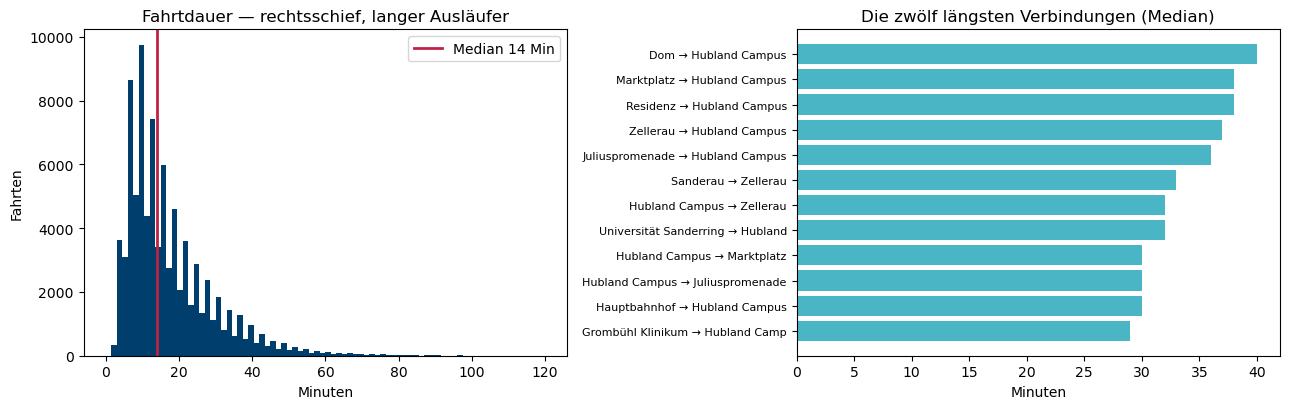

In [7]:
fig, achsen = plt.subplots(1, 2, figsize=(13, 4.2))
achsen[0].hist(d.dauer_min, bins=80, range=(0, 120), color="#003E6E")
achsen[0].axvline(d.dauer_min.median(), color="#BE2344", lw=2,
                  label=f"Median {d.dauer_min.median():.0f} Min")
achsen[0].set_title("Fahrtdauer — rechtsschief, langer Ausläufer")
achsen[0].set_xlabel("Minuten"); achsen[0].set_ylabel("Fahrten"); achsen[0].legend()

oben = d.groupby("route").dauer_min.agg(["median", "count"])
oben = oben[oben["count"] >= 200].sort_values("median").tail(12)
achsen[1].barh(range(len(oben)), oben["median"], color="#4AB5C4")
achsen[1].set_yticks(range(len(oben)))
achsen[1].set_yticklabels([r[:32] for r in oben.index], fontsize=8)
achsen[1].set_title("Die zwölf längsten Verbindungen (Median)")
achsen[1].set_xlabel("Minuten")
plt.tight_layout(); plt.show()

# DIESELBEN VERBINDUNGEN, LESBAR. Im Bild oben sind die Namen auf 32
# Zeichen gekuerzt; hier steht beim Zeigen der volle Name samt Fallzahl.
# Die statische Grafik bleibt, sie traegt die Aussage auch ohne Skripte.
_alle = (d.groupby("route").dauer_min.agg(["median", "count"])
         .query("count >= 200").sort_values("median"))
_fig = go.Figure(go.Bar(
    x=_alle["median"], y=_alle.index, orientation="h",
    customdata=_alle["count"],
    hovertemplate=("<b>%{y}</b><br>Median %{x:.1f} Minuten<br>"
                   "%{customdata} Fahrten<extra></extra>")))
_fig.update_xaxes(title="Minuten (Median)")
_fig.update_yaxes(title="", automargin=True)
interaktiv(_fig, "Alle Verbindungen mit mindestens 200 Fahrten",
           hoehe=max(360, 16 * len(_alle)))

Links: stark rechtsschief — deshalb ist der **Median** das richtige Nullmodell, nicht der
Mittelwert. Rechts das Muster, das dieses Notebook trägt: Die langen Verbindungen führen
zu Dom und Residenz, die kurzen verbinden Bahnhof, Klinikum und Campus.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Welche Merkmale sind zum Zeitpunkt der Anfrage verfügbar — und welche nicht?

### 3.1 Der Leakage-Test

Die Frage ist nicht statistisch, sondern zeitlich: **Was steht in dem Moment zur
Verfügung, in dem die Anzeige erscheinen soll?**

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Spalte</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">verfügbar?</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">warum</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">start_station_id</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">der Kunde steht dort</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">end_station_id</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>ja</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">trägt ab Phase 3 das <strong>geplante</strong> Ziel — was der Kunde vor dem Entsperren wählt (siehe Kasten oben). Das tatsächliche Ende steht getrennt in <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">tatsaechliches_ziel</code> und ist nie Merkmal</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">startzeit</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">jetzt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Feiertag, Ferien</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">stehen im Kalender</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">typ_code</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">das Rad steht vor ihm</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Tageswetter</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>nein</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Tagesmittel und Tagesniederschlag stehen erst am Abend fest</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">endzeit</code>, <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">dauer_min</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">entstehen am Ende der Fahrt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">distanz_km</code>, <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">entgelt_eur</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">werden während und nach der Fahrt gebildet</td></tr>
</tbody></table>
<div style="clear:both"></div>

Die Wetterzeile verdient besondere Aufmerksamkeit. Ein Modell, das mit dem
*Tagesmittel* rechnet, benutzt Wissen von heute Abend für eine Anfrage von heute früh —
und ein zeitlicher Schnitt heilt das nicht, weil auch im Testzeitraum das nachträglich
bekannte Tageswetter eingesetzt würde.

Brauchbar wäre archiviertes Prognosewetter mit seinem Erstellungszeitpunkt. Das haben wir
nicht. **Also fällt das Wetter aus dem Modell** — und wir sagen dazu, dass es ein Verlust
ist, kein Gewinn.

In [8]:
# AUFGABE: Welche Spalten dürfen NICHT ins Modell? Prüfen Sie jede mit der
# Frage: Existiert dieser Wert schon, wenn der Kunde auf "Preis schätzen"
# tippt?
gesperrt = ["endzeit", "dauer_min", "distanz_km", "entgelt_eur",
            "temp_mittel_c"]

print("Gesperrt, weil zum Anfragezeitpunkt nicht vorhanden:")
for s in gesperrt:
    print(f"   {s}")
print()
print("Erlaubt, obwohl es nach 'Ende' klingt: end_station_id -")
print("der Kunde hat sie gewählt. Mit dem Vorbehalt aus dem Kasten oben.")

Gesperrt, weil zum Anfragezeitpunkt nicht vorhanden:
   endzeit
   dauer_min
   distanz_km
   entgelt_eur
   temp_mittel_c

Erlaubt, obwohl es nach 'Ende' klingt: end_station_id -
der Kunde hat sie gewählt. Mit dem Vorbehalt aus dem Kasten oben.


### 3.2 Merkmale der geplanten Fahrt

Drei Gruppen: die Verbindung, der Zeitpunkt, das Rad. Die Zeitmerkmale werden **zyklisch**
kodiert — 23 Uhr und 0 Uhr sind Nachbarn, als Zahlen aber maximal weit auseinander.

In [9]:
d = d.merge(fahrrad[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")

# Strecke und Steigung aus der Routenmatrix holen. Beide sind Eigenschaften
# der Verbindung, nicht der Fahrt - sie stehen also schon vor dem Losfahren
# fest und sind als Merkmal erlaubt.
matrix = routen.set_index(["von_id", "nach_id"])
schluessel = list(zip(d.start_station_id.astype("Int64").astype(str),
                      d.end_station_id.astype("Int64").astype(str)))
d["strecke_km"] = [matrix.strecke_m.get(s, np.nan) / 1000 for s in schluessel]
d["steigung_promille"] = [matrix.steigung_promille.get(s, np.nan) for s in schluessel]
# Rundtouren waeren hier ein Problem - Start und Ziel sind derselbe Ort, eine
# Relation gibt es nicht. Sie sind aber schon in 2.3 ausgeschieden.
#
# Jede fehlende Strecke ist deshalb jetzt ein Datenfehler. Sie stillschweigend
# auf null zu setzen wuerde ihn verstecken, deshalb hier eine Zusicherung.
fehlt = d.strecke_km.isna()
assert not fehlt.any(), (
    f"{fehlt.sum()} echte Verbindungen fehlen in der Routenmatrix: "
    f"{sorted(set(zip(d[fehlt].start_station_id, d[fehlt].end_station_id)))[:5]}")
d[["strecke_km", "steigung_promille"]] = d[["strecke_km", "steigung_promille"]].fillna(0.0)

d["datum"]  = d.startzeit.dt.normalize()
d["stunde"] = d.startzeit.dt.hour
d["wochentag"] = d.startzeit.dt.dayofweek
d["ist_wochenende"] = (d.wochentag >= 5).astype(int)
# Auch der Wochentag ist zyklisch: Sonntag und Montag liegen nebeneinander,
# als Zahlen 6 und 0 aber maximal weit auseinander.
d["wochentag_sin"] = np.sin(2 * np.pi * d.wochentag / 7)
d["wochentag_cos"] = np.cos(2 * np.pi * d.wochentag / 7)
d["monat"] = d.startzeit.dt.month
# Zyklisch: der Dezember liegt neben dem Januar, 23 Uhr neben 0 Uhr.
d["stunde_sin"] = np.sin(2 * np.pi * d.stunde / 24)
d["stunde_cos"] = np.cos(2 * np.pi * d.stunde / 24)
d["monat_sin"]  = np.sin(2 * np.pi * d.monat / 12)
d["monat_cos"]  = np.cos(2 * np.pi * d.monat / 12)
d["ist_feiertag"] = d.datum.isin(feiertag.datum).astype(int)
in_ferien = pd.Series(False, index=d.index)
for _, z in schulfrei.iterrows():
    in_ferien |= (d.datum >= z.von) & (d.datum <= z.bis)
d["ist_ferien"] = in_ferien.astype(int)

# ---- Tarif und Freiminutenstand
# Der Preis haengt nicht nur am Radtyp: Jeder Tarif bringt ein monatliches
# Freiminutenkontingent und teils einen Rabatt mit. Wie viel davon noch uebrig
# ist, weiss die App zum Anfragezeitpunkt - fuer die Vergangenheit muessen wir
# es aus den bisherigen Fahrten des Monats zurueckrechnen.
#
# Gerechnet wird auf ALLEN abgeschlossenen Fahrten, nicht auf der oben
# gefilterten Menge: Auch eine Rundtour und auch eine sehr lange Fahrt
# verbrauchen Freiminuten. Wer hier auf d rechnet, bekommt zu hohe Restbestaende.
alle = ausleihe[ausleihe.status == "abgeschlossen"].sort_values("startzeit").copy()
alle["dauer_min"] = (alle.endzeit - alle.startzeit).dt.total_seconds() / 60
alle = alle.merge(kunde[["kunde_id", "tarif_code"]], on="kunde_id", how="left")
alle = alle.merge(tarife[["tarif_code", "freiminuten_pro_monat", "rabatt_prozent"]],
                  on="tarif_code", how="left")
alle["genutzt"] = alle.dauer_min - alle.berechnete_minuten
alle["monat"] = alle.startzeit.dt.to_period("M")
# Kumulieren und um die eigene Fahrt vermindern: der Stand VOR dieser Fahrt.
# Ohne diesen Versatz stuende die eigene Nutzung schon im Merkmal - ein
# Leakage, das man erst am zu guten Ergebnis bemerkt.
verbraucht = (alle.groupby(["kunde_id", "monat"]).genutzt.cumsum() - alle.genutzt)
alle["freiminuten_rest"] = (alle.freiminuten_pro_monat - verbraucht).clip(lower=0)
d = d.merge(alle[["ausleihe_id", "tarif_code", "freiminuten_pro_monat",
                  "rabatt_prozent", "freiminuten_rest"]],
            on="ausleihe_id", how="left")

echt = d
print(f"{len(d):,} Fahrten, {d.route.nunique()} Verbindungen")
print(f"Tarife: " + ", ".join(f"{t} {n:,}" for t, n in
                              d.tarif_code.value_counts().items()))
print(f"Freiminuten offen bei Fahrtbeginn: Median "
      f"{d.freiminuten_rest.median():.0f} min, "
      f"{(d.freiminuten_rest == 0).mean():.0%} der Fahrten ohne Restguthaben")
print(f"Strecke {echt.strecke_km.min():.2f} bis {echt.strecke_km.max():.2f} km, "
      f"Median {echt.strecke_km.median():.2f} km")
print(f"Steigung {echt.steigung_promille.min():+.0f} bis "
      f"{echt.steigung_promille.max():+.0f} Promille "
      f"(Hubland liegt 90 Meter über der Altstadt)")

85,890 Fahrten, 90 Verbindungen
Tarife: PREMIUM 27,031, OEPNV 23,463, BASIS 18,970, STUDENT 16,426
Freiminuten offen bei Fahrtbeginn: Median 21 min, 40% der Fahrten ohne Restguthaben
Strecke 0.27 bis 6.65 km, Median 2.29 km
Steigung -22 bis +22 Promille (Hubland liegt 90 Meter über der Altstadt)


### 3.3 Aufteilung entlang der Zeit in vier Abschnitte

Wir teilen viermal, nicht dreimal. Der Grund steht schon jetzt fest, bevor wir ein
Ergebnis gesehen haben: CRISP-DM sieht den Rücksprung von der Evaluation in die
Modellierung ausdrücklich vor. Wenn wir ihn gehen, ist die zweite Runde ein **neues
Modell** — und ein Test, auf dem bereits gemessen wurde, ist für sie kein Test mehr,
sondern Entwicklungsinformation.

Wer nur dreimal teilt, muss beim Rücksprung entweder neu erheben oder sich selbst
belügen. Der vierte Abschnitt kostet 12,5 % der Daten und erspart beides.

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Abschnitt</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">wofür</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Regel</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Training</strong> (60 %)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">das Modell lernt</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">die ältesten Fahrten</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Validierung</strong> (15 %)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">wir <em>wählen</em> Verfahren und Einstellungen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">mittlerer Zeitraum</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Test 1</strong> (12,5 %)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">die Punktschätzung wird <em>einmal</em> gemessen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">danach verbraucht</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Kalibrierung</strong> (12,5 %)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">die zweite Runde wird darauf <strong>kalibriert und für die unabhängige Abnahme vorbereitet</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">kein Training — aber Auswahl und Filterung</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Die Kalibrierung ist kein finaler Test.** Auf ihr wird das Artefakt ausgewählt und
über Radtypen und Kombinationen entschieden. Wer daraufhin Kennzahlen berichtet,
berichtet die Güte einer Auswahl, die auf ebendiesen Daten getroffen wurde — sie fällt
zu günstig aus. Die unabhängige Prüfung leistet die **Abnahme**: der fünfte Abschnitt,
in Phase 2 versiegelt und in 6.7 einmal geöffnet. Sie ist unabhängig, aber
**rückblickend**; nach vorn schaut nur der Schattenbetrieb.

```text
Training → Validierung → Test 1: Punktschätzung
         → Rücksprung  → Kalibrierung: Kalibrierung des Intervallprodukts und Vorbereitung der Abnahme
         → Abnahme (6.7): unabhängige, rückblickende Prüfung — entscheidet den Status
         → Schattenbetrieb: prospektive Prüfung in der echten App — steht aus
```

In [10]:
d = d.sort_values("startzeit").reset_index(drop=True)
# FUENF ABSCHNITTE, NICHT VIER - UND DER LETZTE WIRD NICHT ANGEFASST.
#
# Eine fruehere Fassung hatte vier: Training, Validierung, Test 1 und
# einen letzten Abschnitt, der zugleich die Spannen KALIBRIERTE und sie
# FREIGAB. Das geht nicht. Wer auf denselben Daten einstellt und prueft,
# prueft, ob sich das Verfahren an seine eigene Einstellung erinnert.
#
# Der letzte Abschnitt ist deshalb halbiert:
#   Kalibrierung - hier werden Tabelle, Filter und Gates eingestellt
#   Abnahme      - unangetastet; hier faellt das Urteil ueber das Produkt
#
# Die Abnahme wird in 6.7 EINMAL geoeffnet, mit der fertigen
# Schnittstelle, und danach nicht mehr angefasst.
ANTEILE = [0.60, 0.75, 0.875]
g1, g2, g3 = d.startzeit.quantile(ANTEILE)
print(f"Aufgeteilt nach Zeit: {ANTEILE[0]:.0%} Training, "
      f"{ANTEILE[1]-ANTEILE[0]:.1%} Validierung, "
      f"{ANTEILE[2]-ANTEILE[1]:.1%} Test 1, "
      f"{1-ANTEILE[2]:.1%} Kalibrierung\n")
print("Der Abnahmezeitraum ist hier gar nicht mehr dabei - er wurde in")
print(f"Phase 2 versiegelt, ab {ABNAHME_AB:%d.%m.%Y}.\n")

def zielverlaesslichkeit_lernen(lern):
    # Je Verbindung: Anteil der Fahrten, die am genannten Ziel endeten.
    # Verbindungen mit wenigen Fahrten werden zur Gesamtquote hin
    # geglaettet - sonst stuende bei drei Fahrten eine 0 % oder 100 %,
    # die nichts bedeutet.
    _global = float((lern.tatsaechliches_ziel == lern.end_station_id).mean())
    _g = lern.assign(_treu=(lern.tatsaechliches_ziel == lern.end_station_id))              .groupby(["start_station_id", "end_station_id"])._treu.agg(["mean", "size"])
    K = 30          # Glaettungsgewicht: ab rund 30 Fahrten zaehlt die Verbindung
    _g["wert"] = (_g["mean"] * _g["size"] + _global * K) / (_g["size"] + K)
    return _global, _g["wert"].to_dict()


def zielverlaesslichkeit_setzen(rahmen, global_wert, tabelle):
    return [tabelle.get((int(s), int(z)), global_wert)
            for s, z in zip(rahmen.start_station_id, rahmen.end_station_id)]


# ─── ZIELVERLAESSLICHKEIT: GELERNT NUR AUF DEM TRAINING ─────────────
#
# Die Spalte muss auf d liegen, bevor die Teilmengen entstehen - sonst
# haette jede Teilmenge ihre eigene Kopie. Gelernt wird sie aber
# ausschliesslich aus den Zeilen VOR g1, also aus dem Training.
_lern = d[d.startzeit < g1]
ZV_GLOBAL, ZV_TABELLE = zielverlaesslichkeit_lernen(_lern)

# ─── IM TRAINING FORTSCHREITEND, DANACH EINGEFROREN ─────────────────
#
# Eine Tabelle, die aus dem GANZEN Training gerechnet und dann auf
# dieselben Trainingszeilen gelegt wird, laesst jede Zeile ein bisschen
# in ihre eigene Zukunft sehen: Der Wert fuer den 3. Januar enthaelt
# auch die Fahrten vom 30. Juni. Das Modell lernt dann an einem
# Merkmal, das es im Betrieb so nie bekommt - und sieht besser aus,
# als es ist.
#
# Fuer die Trainingszeilen wird der Wert deshalb FORTSCHREITEND
# gerechnet: nur aus Fahrten, die VOR der jeweiligen Zeile liegen.
# Fuer alles danach (Validierung, Kalibrierung, Abnahme) gilt die
# eingefrorene Tabelle - so, wie es im Betrieb waere.
d = d.sort_values("startzeit").reset_index(drop=True)
_treu = (d.tatsaechliches_ziel == d.end_station_id).astype(float)
_grp = d.groupby(["start_station_id", "end_station_id"])
_n_vor = _grp.cumcount()                                  # Fahrten davor
_s_vor = _grp[_treu.name if _treu.name else 0].cumsum() if False else (
    _treu.groupby([d.start_station_id, d.end_station_id]).cumsum() - _treu)
_lauf = np.arange(len(d))
_glob_vor = (_treu.cumsum() - _treu) / np.maximum(_lauf, 1)
_glob_vor = _glob_vor.where(_lauf > 0, ZV_GLOBAL)
K_ZV = 30
_fortschreitend = (_s_vor + _glob_vor * K_ZV) / (_n_vor + K_ZV)

_ist_training = d.startzeit < g1
d["zielverlaesslichkeit"] = np.where(
    _ist_training, _fortschreitend,
    zielverlaesslichkeit_setzen(d, ZV_GLOBAL, ZV_TABELLE))
merke("zv_k", K_ZV)
print(f"Zielverlaesslichkeit: im Training fortschreitend aus je {int(_n_vor.max())} "
      f"bis 0 frueheren Fahrten,")
print("danach die eingefrorene Trainingstabelle - wie im Betrieb.")
merke("zv_global", ZV_GLOBAL)
merke("zv_min", float(min(ZV_TABELLE.values())))
merke("zv_max", float(max(ZV_TABELLE.values())))
print(f"Zielverlaesslichkeit je Verbindung, aus dem Training: "
      f"{min(ZV_TABELLE.values()):.1%} bis {max(ZV_TABELLE.values()):.1%} "
      f"(insgesamt {ZV_GLOBAL:.1%})")
print("Das Modell sieht damit, WO das genannte Ziel wackelt - und kann die")
print("Spanne genau dort weiten, statt ueberall.\n")

training    = d[d.startzeit <  g1]
validierung = d[(d.startzeit >= g1) & (d.startzeit < g2)]
test1       = d[(d.startzeit >= g2) & (d.startzeit < g3)]
kalib       = d[d.startzeit >= g3]

for name, teil in (("Training", training), ("Validierung", validierung),
                   ("Test 1 (Punkt)", test1), ("Kalibrierung (Spanne)", kalib)):
    print(f"{name:16} {len(teil):>7,} Fahrten   "
          f"{teil.startzeit.min():%d.%m.%Y} bis {teil.startzeit.max():%d.%m.%Y}")
print()
print(f"Test 1 reicht von {test1.startzeit.min():%m/%Y} bis {test1.startzeit.max():%m/%Y}, "
      f"die Kalibrierung von {kalib.startzeit.min():%m/%Y} bis {kalib.startzeit.max():%m/%Y}.")
print("Dass die beiden")
print("Zeiträume verschiedene Jahreszeiten sind, ist kein Zufall der Aufteilung,")
print("sondern eine Eigenschaft der Daten - und sie wird uns beschäftigen.")
print()
print("ZWEIERLEI IST DABEI ZU BEACHTEN:")
print("1. Die Erkundung in Phase 2 lief ueber alles, was NICHT versiegelt ist -")
print("   also auch ueber die Kalibrierung. Trainiert wurde dort nie, aber blind")
print("   sind wir ihr gegenueber auch nicht. Der Abnahmezeitraum dagegen war")
print("   schon vor der ersten Grafik weg.")
print("2. Die Kalibrierung traegt in Phase 6 die Auswahl des Artefakts, die")
print("   Radtypfreigabe und die Filterung der Kombinationen - nicht die")
print("   Produktfreigabe. Sie ist damit ein KALIBRIERUNGSZEITRAUM, kein")
print("   unabhaengiger Endtest. Den liefert die Abnahme in 6.7; was auch sie")
print("   nicht leisten kann, ist ein Blick nach vorn - dafuer braucht es")
print("   den Schattenbetrieb.")

Aufgeteilt nach Zeit: 60% Training, 15.0% Validierung, 12.5% Test 1, 12.5% Kalibrierung

Der Abnahmezeitraum ist hier gar nicht mehr dabei - er wurde in
Phase 2 versiegelt, ab 29.06.2026.

Zielverlaesslichkeit: im Training fortschreitend aus je 2464 bis 0 frueheren Fahrten,
danach die eingefrorene Trainingstabelle - wie im Betrieb.
Zielverlaesslichkeit je Verbindung, aus dem Training: 52.1% bis 94.5% (insgesamt 74.5%)
Das Modell sieht damit, WO das genannte Ziel wackelt - und kann die
Spanne genau dort weiten, statt ueberall.

Training          51,534 Fahrten   24.08.2021 bis 29.09.2024
Validierung       12,883 Fahrten   29.09.2024 bis 25.06.2025
Test 1 (Punkt)    10,736 Fahrten   25.06.2025 bis 14.11.2025
Kalibrierung (Spanne)  10,737 Fahrten   14.11.2025 bis 29.06.2026

Test 1 reicht von 06/2025 bis 11/2025, die Kalibrierung von 11/2025 bis 06/2026.
Dass die beiden
Zeiträume verschiedene Jahreszeiten sind, ist kein Zufall der Aufteilung,
sondern eine Eigenschaft der Daten - und sie w

---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Verdient ein Modell seinen Unterhalt gegenüber einer Nachschlagetabelle?

### 4.1 Vier Baselines, bevor ein Modell gerechnet wird

Baseline D ist der eigentliche Gegner: *„Für Hauptbahnhof → Hubland brauchen die Leute
normalerweise acht Minuten.“*

In [11]:
from sklearn.metrics import mean_absolute_error, median_absolute_error

median_gesamt = training.dauer_min.median()
tabelle = [("A  Median aller Fahrten",
            mean_absolute_error(validierung.dauer_min,
                                np.full(len(validierung), median_gesamt)))]

# AUFGABE: Baselines B, C und D. Der Median wird IMMER auf dem Training
# gebildet und auf die Validierung angewandt - nie umgekehrt.
for beschriftung, spalte in (("B  Median je Radtyp", "typ_code"),
                             ("C  Median je Startstation", "start_name"),
                             ("D  Median je Verbindung", "route")):
    med = training.groupby(spalte).dauer_min.median()
    vorhersage = validierung[spalte].map(med).fillna(median_gesamt)
    tabelle.append((beschriftung, mean_absolute_error(validierung.dauer_min, vorhersage)))

for name, fehler in tabelle:
    print(f"{name:30} MAE {fehler:5.2f} Min")
print()
print(f"Vom Nichtwissen zur Startstation: {tabelle[0][1] - tabelle[2][1]:.2f} Min gewonnen.")
print(f"Von der Startstation zum Ziel:    {tabelle[2][1] - tabelle[3][1]:.2f} Min gewonnen.")

A  Median aller Fahrten        MAE  8.59 Min
B  Median je Radtyp            MAE  8.44 Min
C  Median je Startstation      MAE  7.33 Min
D  Median je Verbindung        MAE  4.80 Min

Vom Nichtwissen zur Startstation: 1.25 Min gewonnen.
Von der Startstation zum Ziel:    2.53 Min gewonnen.


### 4.2 Pipeline: Vorverarbeitung und Modell in einem Objekt

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

KATEGORIAL = ["start_name", "ziel_name", "route", "typ_code"]
NUMERISCH  = ["strecke_km", "steigung_promille",
              "stunde_sin", "stunde_cos", "wochentag_sin", "wochentag_cos",
              "monat_sin", "monat_cos", "ist_wochenende",
              "ist_feiertag", "ist_ferien",
              # WIE VERLAESSLICH IST DAS GENANNTE ZIEL AUF DIESER STRECKE?
              #
              # Seit das Modell mit dem GEPLANTEN Ziel rechnet, steckt in
              # jeder Anfrage eine zusaetzliche Unsicherheit: Der Kunde
              # kann woanders hinfahren. Sie ist aber nicht ueberall
              # gleich gross - auf einer Pendelstrecke zum Bahnhof haelt
              # sich fast jeder ans Ziel, auf einer Freizeitrunde nicht.
              #
              # Das Modell kann das nicht wissen, solange es niemand
              # hinschreibt. Diese Spalte schreibt es hin: der Anteil der
              # Fahrten dieser Verbindung, die frueher tatsaechlich am
              # genannten Ziel endeten. Damit kann die Quantilregression
              # die Spanne genau dort weiten, wo das Ziel wackelt - und
              # anderswo eng lassen.
              #
              # ZUR ANFRAGEZEIT BEKANNT: Die Zahl stammt aus der
              # Vergangenheit, nicht aus der laufenden Fahrt. Gerechnet
              # wird sie ausschliesslich auf dem TRAINING; Validierung,
              # Kalibrierung und Abnahme schlagen nur nach.
              "zielverlaesslichkeit"]
MERKMALE = KATEGORIAL + NUMERISCH
def pipeline(modell, drop=None):
    # handle_unknown="ignore" verhindert einen Absturz bei einer neuen
    # Station. Es macht die Vorhersage aber nicht gültig - die unbekannte
    # Kategorie wird zum Nullvektor. Deshalb verweigert die Auslieferung
    # in Phase 6 unbekannte Kombinationen ausdrücklich.
    return Pipeline([
        ("aufbereiten", ColumnTransformer([
            ("kategorial", OneHotEncoder(handle_unknown="ignore", drop=drop), KATEGORIAL),
            ("numerisch", "passthrough", NUMERISCH)])),
        ("modell", modell)])

modelle = {
    "Nullmodell (Median)":       pipeline(DummyRegressor(strategy="median")),
    "Lineare Regression":        pipeline(LinearRegression(), drop="first"),
    "Entscheidungsbaum (T=10)":  pipeline(DecisionTreeRegressor(max_depth=10, random_state=42)),
    "Random Forest (200 Bäume)": pipeline(RandomForestRegressor(
        n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1)),
}

guete = {}
for name, mp in modelle.items():
    mp.fit(training[MERKMALE], training.dauer_min)
    v = mp.predict(validierung[MERKMALE])
    guete[name] = mean_absolute_error(validierung.dauer_min, v)
    print(f"{name:28} MAE {guete[name]:5.2f} Min")

bestes = min(guete, key=guete.get)
print(f"\nAuf der VALIDIERUNG gewählt: {bestes}")
print(f"Baseline D lag bei {tabelle[3][1]:.2f} Min - das Modell ist "
      f"{1 - guete[bestes]/tabelle[3][1]:.0%} besser.")

Nullmodell (Median)          MAE  8.59 Min
Lineare Regression           MAE  4.63 Min


Entscheidungsbaum (T=10)     MAE  4.83 Min


Random Forest (200 Bäume)    MAE  4.52 Min

Auf der VALIDIERUNG gewählt: Random Forest (200 Bäume)
Baseline D lag bei 4.80 Min - das Modell ist 6% besser.


> **Zur linearen Regression:** `drop="first"` beseitigt die Dummy-Falle innerhalb eines
> Merkmals, aber nicht die Abhängigkeiten zwischen ihnen — die Route bestimmt Start und
> Ziel, Strecke und Steigung sind je Route konstant. Die
> Vorhersagen sind brauchbar, die **Koeffizienten aber nicht eindeutig interpretierbar**.
> Wer sie lesen will, braucht eine redundanzfreie Merkmalsmenge oder eine regularisierte
> Regression.

### 4.3 Ablation: Was trägt die Zielangabe bei?

Der Vergleich zweier Nachschlagetabellen in Phase 2 war ein Hinweis, kein Beweis. Sauber
ist es, **dasselbe Modell** einmal mit und einmal ohne die Zielmerkmale zu rechnen.

In [13]:
OHNE_ZIEL_KAT = ["start_name", "typ_code"]
OHNE_ZIEL_NUM = [s for s in NUMERISCH
                 if s not in ("strecke_km", "steigung_promille")]

ohne = Pipeline([
    ("aufbereiten", ColumnTransformer([
        ("kategorial", OneHotEncoder(handle_unknown="ignore"), OHNE_ZIEL_KAT),
        ("numerisch", "passthrough", OHNE_ZIEL_NUM)])),
    ("modell", RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                     random_state=42, n_jobs=-1))])
ohne.fit(training[OHNE_ZIEL_KAT + OHNE_ZIEL_NUM], training.dauer_min)
mae_ohne = mean_absolute_error(validierung.dauer_min,
                               ohne.predict(validierung[OHNE_ZIEL_KAT + OHNE_ZIEL_NUM]))

print(f"Random Forest OHNE Zielmerkmale: MAE {mae_ohne:5.2f} Min")
print(f"Random Forest MIT Zielmerkmalen: MAE {guete[bestes]:5.2f} Min")
anteil_ziel = 1 - guete[bestes] / mae_ohne
print(f"Beitrag des Ziels:               {mae_ohne - guete[bestes]:5.2f} Min "
      f"({anteil_ziel:.0%})")
merke("ablation_anteil", anteil_ziel)
_ = merke("mae_ohne_ziel", mae_ohne)  # Wert nur festhalten
print()
print("Wohin jemand faehrt, ist das mit Abstand wichtigste Merkmal: Ohne das")
print("Ziel kennt das Modell die Strecke nicht, und ohne Strecke bleibt nur")
print("der Durchschnitt. Die Geschaeftslogik - erst fragen, dann schaetzen -")
print("ist damit nicht nur richtig, sondern die Voraussetzung des Produkts.")

Random Forest OHNE Zielmerkmale: MAE  5.20 Min
Random Forest MIT Zielmerkmalen: MAE  4.52 Min
Beitrag des Ziels:                0.67 Min (13%)

Wohin jemand faehrt, ist das mit Abstand wichtigste Merkmal: Ohne das
Ziel kennt das Modell die Strecke nicht, und ohne Strecke bleibt nur
der Durchschnitt. Die Geschaeftslogik - erst fragen, dann schaetzen -
ist damit nicht nur richtig, sondern die Voraussetzung des Produkts.


### 4.4 Wechselwirkungen: Random Forest gegen lineare Regression

Der Random Forest ist besser als die lineare Regression. Das allein ist kein Argument —
teurer ist er auch. Ein Verfahren, das Wechselwirkungen abbilden kann, rechtfertigt sich
erst, wenn es welche **gibt**.

Würzburg liefert eine: Das Hubland liegt rund neunzig Meter über der Altstadt. Was
kostet diese Steigung an Tempo — und kostet sie jedes Rad dasselbe?

> **Zur Lesart der Zahlen:** Wir teilen die Streckenlänge durch die Ausleihdauer. Das
> ergibt das Tempo von Station zu Station, inklusive Ampeln, Umwegen und dem An- und
> Abschließen — nicht die Geschwindigkeit auf der Strecke. Es liegt deshalb spürbar
> unter dem, was der Tacho zeigen würde. Für den Vergleich zwischen den Radtypen spielt
> das keine Rolle: Der Abzug trifft alle drei gleich.

In [14]:
echt_v = validierung.copy()
echt_v["kmh"] = echt_v.strecke_km / (echt_v.dauer_min / 60)
klassen = pd.cut(echt_v.steigung_promille, [-100, -8, -3, 3, 8, 100],
                 labels=["stark bergab", "bergab", "eben", "bergauf", "stark bergauf"])
tempo = echt_v.groupby([klassen, "typ_code"], observed=True).kmh.mean().unstack()

print("Mittleres Tempo in km/h je Steigung und Radtyp:")
print(tempo.round(1).to_string())
print()
print("Mittleres Tempo eben gegen stark ansteigend:")
for typ in tempo.columns:
    eben, berg = tempo.loc["eben", typ], tempo.loc["stark bergauf", typ]
    verlust = 1 - berg / eben
    print(f"   {typ:6} {eben:5.1f} -> {berg:5.1f} km/h   {verlust:5.1%} langsamer")
    merke(f"anstieg_{typ.lower()}", verlust)

Mittleres Tempo in km/h je Steigung und Radtyp:
typ_code           CARGO  CITY  EBIKE
steigung_promille                    
stark bergab         8.5   9.9   11.3
bergab               8.3   9.7   11.1
eben                 8.7  10.1   12.6
bergauf              8.6  10.3   13.1
stark bergauf        7.7   9.3   12.2

Mittleres Tempo eben gegen stark ansteigend:
   CARGO    8.7 ->   7.7 km/h   12.1% langsamer
   CITY    10.1 ->   9.3 km/h    8.2% langsamer
   EBIKE   12.6 ->  12.2 km/h    3.4% langsamer


Auf stark ansteigenden Verbindungen liegt das mittlere Tempo des Citybikes
8 % unter dem auf ebenen, beim E-Bike nur 3 %, beim
Lastenrad 12 %. Die naheliegende Erklärung ist der Motor, der die
Hangabtriebskraft abfängt — beweisen lässt sich das hier nicht, denn ansteigende
Verbindungen unterscheiden sich auch in Streckenführung, Verkehr und Anlass.

**Genau das ist eine Wechselwirkung:** Die Wirkung der Steigung hängt vom Radtyp ab. Eine
lineare Regression addiert einen festen Steigungskoeffizienten und einen festen
Radtyp-Zuschlag; sie kann nur sagen „Steigung kostet x Minuten" und „E-Bikes sind y
Minuten schneller", nicht „Steigung kostet das E-Bike weniger". Ein Baum kann es, weil er
erst nach dem Radtyp und dann innerhalb jedes Astes nach der Steigung teilt.

> **Für die Praxis:** Wer die lineare Regression behalten will, muss den
> Wechselwirkungsterm von Hand bilden — Steigung mal Radtyp als eigene Spalte. Das
> Baumverfahren findet ihn selbst. Der Preis dafür sind Koeffizienten, die man nicht
> mehr ablesen kann.

---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Reicht das für die Preisanzeige? Und wenn nicht — was dann?

### 5.1 Messung auf Test 1

In [15]:
lernmenge = pd.concat([training, validierung])
final = modelle[bestes]
final.fit(lernmenge[MERKMALE], lernmenge.dauer_min)

pruef = test1.copy()
pruef["dauer_geschaetzt"] = np.maximum(1.0, final.predict(test1[MERKMALE]))
mae_t1 = mean_absolute_error(pruef.dauer_min, pruef.dauer_geschaetzt)

med_route = lernmenge.groupby("route").dauer_min.median()
basis_d = pruef.route.map(med_route).fillna(median_gesamt)

print(f"Random Forest auf Test 1 : MAE {mae_t1:5.2f} Min")
print(f"Baseline D auf Test 1    : MAE {mean_absolute_error(pruef.dauer_min, basis_d):5.2f} Min")
print(f"auf der Validierung      : MAE {guete[bestes]:5.2f} Min")

Random Forest auf Test 1 : MAE  4.44 Min
Baseline D auf Test 1    : MAE  4.77 Min
auf der Validierung      : MAE  4.52 Min


### 5.2 Von Minuten zu Euro über die Tariflogik

Die Geschäftsfrage lautet: *Was kostet **diesen Kunden** die Fahrt?* Das ist nicht der
Listenpreis des Radtyps. Zwischen beiden liegen drei Regeln aus der Preisauskunft:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Regel</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Wirkung</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Freiminuten</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Studierende haben 30, ÖPNV-Abonnenten 50, Premium 90 Minuten im Monat</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Rabatt</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Premium zahlt 20 % weniger auf den Restbetrag</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Tagesdeckel</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Startgebühr plus Zeitentgelt, gedeckelt je angefangenem Tag</td></tr>
</tbody></table>
<div style="clear:both"></div>

Die Startgebühr fällt **auch dann an**, wenn Freiminuten die ganze Fahrt decken.

Die Reihenfolge ist nicht beliebig: erst aufrunden, dann Freiminuten abziehen, dann
deckeln, dann rabattieren. Eine andere Reihenfolge ergibt andere Beträge.

> **Was hier getrennt bleibt.** Die Regression schätzt nur die **Dauer**. Der Preis
> entsteht daraus durch eine feste Rechenvorschrift ohne jede Unsicherheit. Diese
> Trennung ist keine Förmlichkeit: Ändert das Unternehmen morgen die Tarife, muss
> das Modell nicht neu gelernt werden.

In [16]:
tarif = preise.set_index("typ_code")

def kundenpreis(minuten, typ, freiminuten_rest, rabatt_prozent):
    """Was der Kunde tatsächlich zahlt - Freiminuten und Rabatt eingerechnet."""
    z = tarif.loc[typ]
    # Angefangene Minuten zählen voll: die Schätzung ist eine Kommazahl,
    # die Abrechnung kennt nur ganze Minuten.
    minuten = int(math.ceil(max(0.0, minuten)))
    berechnet = minuten - min(freiminuten_rest, minuten)
    tage = max(1, math.ceil(minuten / (24 * 60)))
    roh = min(z.startgebuehr_eur + berechnet * z.preis_pro_minute_eur,
              z.tageshoechstpreis_eur * tage)
    return round(roh * (1 - rabatt_prozent / 100.0), 2)

# Erst gegenprüfen, dann verwenden: Die Formel muss das ergeben, was in der
# Datenbank steht. Sonst bewerten wir gleich unsere eigene Rechnung statt der
# Wirklichkeit - und merken es nie.
nachgerechnet = [kundenpreis(m, t, r, ra) for m, t, r, ra
                 in zip(pruef.dauer_min, pruef.typ_code,
                        pruef.freiminuten_rest, pruef.rabatt_prozent)]
abweichung = (np.array(nachgerechnet) - pruef.entgelt_eur.values)
treffer = float((np.abs(abweichung) < 0.005).mean())
merke("tarif_treffer", treffer)
print(f"Nachgerechnetes Entgelt gegen das gespeicherte: "
      f"{treffer:.2%} exakt gleich, größte Abweichung "
      f"{np.abs(abweichung).max():.2f} €")
assert treffer > 0.999, (
    "Die Tariflogik bildet das gespeicherte Entgelt nicht ab - "
    "jede Preisaussage danach waere ohne Wert.")

# AUFGABE: Ist- und Schätzpreis je Fahrt, daraus der Betrag der Abweichung.
# NICHT die Minutendifferenz mal Preis - wegen Deckel und Freiminuten ist der
# Zusammenhang nicht überall linear.
pruef["p_ist"] = pruef.entgelt_eur
pruef["p_geschaetzt"] = [kundenpreis(m, t, r, ra) for m, t, r, ra
                         in zip(pruef.dauer_geschaetzt, pruef.typ_code,
                                pruef.freiminuten_rest, pruef.rabatt_prozent)]
pruef["preisfehler"] = (pruef.p_geschaetzt - pruef.p_ist).abs()

print(f"{'Radtyp':8} {'n':>6} {'Fahrt kostet':>13} {'Abweichung':>12} "
      f"{'unter 0,50 €':>13} {'Kriterium':>12}")
for t, g in pruef.groupby("typ_code"):
    pf = g.preisfehler.mean()
    print(f"{t:8} {len(g):>6,} {g.p_ist.mean():>12.2f} € {pf:>11.2f} € "
          f"{(g.preisfehler < 0.50).mean():>12.0%} "
          f"{'erfüllt' if pf < 0.50 else 'gerissen':>12}")
    if t == "CITY":
        merke("preisfehler_city", pf)
        _ = merke("city_unter_50", (g.preisfehler < 0.50).mean())
    if t == "CARGO":
        _ = merke("preisfehler_cargo", pf)

# Welche Radtypen die Grenze halten, entscheidet die Messung - nicht der
# Verfasser des Textes. Der Fliesstext holt sich die Namen von hier; damit
# kann keine Aufzaehlung mehr veralten, wenn sich die Zahlen aendern.
def aufzaehlung(namen):
    """A, B und C - statt A und B und C."""
    namen = list(namen)
    if len(namen) <= 1:
        return namen[0] if namen else "keiner"
    return ", ".join(namen[:-1]) + " und " + namen[-1]


_halten = sorted(t for t, g in pruef.groupby("typ_code")
                 if g.preisfehler.mean() < 0.50)
_reissen = sorted(set(pruef.typ_code.unique()) - set(_halten))
merke("typen_halten", aufzaehlung(_halten))
_ = merke("typen_reissen", aufzaehlung(_reissen))

Nachgerechnetes Entgelt gegen das gespeicherte: 100.00% exakt gleich, größte Abweichung 0.00 €


Radtyp        n  Fahrt kostet   Abweichung  unter 0,50 €    Kriterium
CARGO     1,488         6.41 €        1.44 €          56%     gerissen
CITY      6,065         0.84 €        0.24 €          85%      erfüllt
EBIKE     3,183         2.28 €        0.41 €          71%      erfüllt


Für **CITY und EBIKE ist die Grenze eingehalten**, für CARGO nicht.

Bevor daraus eine Freigabe wird, zwei Fragen, die man sich in dieser Lage immer stellen
sollte.

In [17]:
pruef["abweichung"] = pruef.p_geschaetzt - pruef.p_ist   # mit Vorzeichen

print("Frage 1: Schätzen wir systematisch zu hoch oder zu niedrig?")
for t, g in pruef.groupby("typ_code"):
    print(f"   {t:8} mittlere Abweichung {g.abweichung.mean():+6.2f} €   "
          f"zu hoch bei {(g.abweichung > 0).mean():.0%} der Fahrten")
print("   -> Nein. Über- und Unterschätzung heben sich weitgehend auf.")

print("\nFrage 2: Ist das Modell für teure Räder schlechter?")
for t, g in pruef.groupby("typ_code"):
    print(f"   {t:8} Abweichung {g.preisfehler.mean():5.2f} € bei einem Fahrpreis von "
          f"{g.p_ist.mean():6.2f} €  =  {g.preisfehler.mean()/g.p_ist.mean():.0%}")
print("   -> Nein. Relativ zum Fahrpreis ist die Abweichung ähnlich.")
print("      Was sich unterscheidet, ist die Strenge einer festen 50-Cent-Grenze.")

Frage 1: Schätzen wir systematisch zu hoch oder zu niedrig?
   CARGO    mittlere Abweichung  -0.22 €   zu hoch bei 26% der Fahrten
   CITY     mittlere Abweichung  -0.03 €   zu hoch bei 25% der Fahrten
   EBIKE    mittlere Abweichung  +0.02 €   zu hoch bei 25% der Fahrten
   -> Nein. Über- und Unterschätzung heben sich weitgehend auf.

Frage 2: Ist das Modell für teure Räder schlechter?
   CARGO    Abweichung  1.44 € bei einem Fahrpreis von   6.41 €  =  22%
   CITY     Abweichung  0.24 € bei einem Fahrpreis von   0.84 €  =  28%
   EBIKE    Abweichung  0.41 € bei einem Fahrpreis von   2.28 €  =  18%
   -> Nein. Relativ zum Fahrpreis ist die Abweichung ähnlich.
      Was sich unterscheidet, ist die Strenge einer festen 50-Cent-Grenze.


### 5.3 Belastbarkeit des Ergebnisses

Eine einzelne Zahl auf einem einzelnen Zeitraum sagt nichts darüber, wie sie im nächsten
Quartal aussieht. Ein Kriterium, das nur in einer Jahreszeit hält, wäre keine Zusage —
also prüfen wir es über mehrere.

Wir prüfen das **innerhalb** von Training und Validierung: Test 1 ist verbraucht, und
Kalibrierung wurde bis hierher weder zum Anpassen noch zum Auswählen verwendet. Völlig blind
ist er trotzdem nicht — die Erkundung in Phase 2 hat den gesamten Datensatz gesehen.
Er wird ab Phase 5.6 für die zweite Runde gebraucht.

In [18]:
lernbasis = pd.concat([training, validierung]).sort_values("startzeit")
grenzen = lernbasis.startzeit.quantile([0.5, 0.6, 0.7, 0.8, 0.9]).tolist()

print(f"{'Fenster':22}{'n':>7}{'MAE':>8}{'CITY Preisfehler':>19}")
schwankung = []
for i in range(len(grenzen) - 1):
    lern_i  = lernbasis[lernbasis.startzeit < grenzen[i]]
    pruef_i = lernbasis[(lernbasis.startzeit >= grenzen[i])
                        & (lernbasis.startzeit < grenzen[i + 1])]
    if len(pruef_i) < 200:
        continue
    m = pipeline(RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                       random_state=42, n_jobs=-1))
    m.fit(lern_i[MERKMALE], lern_i.dauer_min)
    v = np.maximum(1.0, m.predict(pruef_i[MERKMALE]))
    c = pruef_i[pruef_i.typ_code == "CITY"]
    vc = np.maximum(1.0, m.predict(c[MERKMALE]))
    pf = np.mean(np.abs(
        np.array([kundenpreis(x, "CITY", r, ra) for x, r, ra
                  in zip(vc, c.freiminuten_rest, c.rabatt_prozent)])
        - c.entgelt_eur.values))
    schwankung.append(pf)
    print(f"{pruef_i.startzeit.min():%m/%Y} bis {pruef_i.startzeit.max():%m/%Y}   "
          f"{len(pruef_i):>6,}{mean_absolute_error(pruef_i.dauer_min, v):>8.2f}"
          f"{pf:>18.2f} €")

lo, hi = min(schwankung), max(schwankung)
print(f"\nDer CITY-Preisfehler schwankt zwischen {lo:.2f} € und {hi:.2f} €.")
if lo <= 0.50 <= hi:
    print("Die Grenze von 0,50 € liegt INNERHALB dieser Schwankung - das")
    print("Kriterium haelt also mal und reisst mal. Das ist keine Zusage.")
elif hi < 0.50:
    print(f"Die Grenze von 0,50 € liegt OBERHALB der Schwankung: In allen")
    print(f"vier Fenstern haelt das Kriterium, im schlechtesten mit {0.50-hi:.2f} €")
    print("Abstand. Fuer CITY ist die Punktschaetzung damit belastbar.")
else:
    print("Die Grenze von 0,50 € liegt UNTERHALB der Schwankung - das")
    print("Kriterium reisst in jedem Fenster.")

Fenster                     n     MAE   CITY Preisfehler


10/2023 bis 04/2024    6,442    5.01              0.23 €


04/2024 bis 07/2024    6,442    4.61              0.27 €


07/2024 bis 09/2024    6,441    4.58              0.27 €


09/2024 bis 04/2025    6,441    4.40              0.21 €

Der CITY-Preisfehler schwankt zwischen 0.21 € und 0.27 €.
Die Grenze von 0,50 € liegt OBERHALB der Schwankung: In allen
vier Fenstern haelt das Kriterium, im schlechtesten mit 0.23 €
Abstand. Fuer CITY ist die Punktschaetzung damit belastbar.


Der Fehler schwankt über die vier Fenster nur um wenige Cent und bleibt überall deutlich
unter der Grenze. **Für CITY ist die Punktschätzung damit belastbar**, nicht nur einmalig
gelungen. Eine Saisonabhängigkeit, die man erwarten könnte, zeigt sich in diesen vier
Fenstern nicht — was sie über längere Zeiträume tut, sagen sie nicht.

Für CARGO gibt es dagegen bisher kein Produkt.

### 5.4 Ursachen der verbleibenden Abweichung

In [19]:
print("\nDie treffsichersten und die schwierigsten Verbindungen (CITY):")
c = pruef[pruef.typ_code == "CITY"]
je_route = c.groupby("route").agg(
    n=("dauer_min", "size"), median_ist=("dauer_min", "median"),
    q1=("dauer_min", lambda s: s.quantile(.25)),
    q3=("dauer_min", lambda s: s.quantile(.75)),
    fehler=("preisfehler", "median")).query("n >= 40").sort_values("fehler")
for r, z in pd.concat([je_route.head(4), je_route.tail(4)]).iterrows():
    print(f"   {r[:38]:38} {z.median_ist:4.0f} Min "
          f"(mittlere Hälfte {z.q1:3.0f}-{z.q3:3.0f})  Abweichung {z.fehler:5.2f} €")


Die treffsichersten und die schwierigsten Verbindungen (CITY):
   Dom → Grombühl Klinikum                  16 Min (mittlere Hälfte  11- 19)  Abweichung  0.00 €
   Zellerau → Sanderau                      24 Min (mittlere Hälfte  21- 29)  Abweichung  0.00 €
   Juliuspromenade → Universität Sanderri   11 Min (mittlere Hälfte   9- 13)  Abweichung  0.00 €
   Marktplatz → Dom                          5 Min (mittlere Hälfte   4-  7)  Abweichung  0.00 €
   Juliuspromenade → Hubland Campus         35 Min (mittlere Hälfte  31- 41)  Abweichung  0.22 €
   Marktplatz → Hubland Campus              38 Min (mittlere Hälfte  32- 44)  Abweichung  0.40 €
   Residenz → Hubland Campus                42 Min (mittlere Hälfte  26- 50)  Abweichung  0.80 €
   Dom → Hubland Campus                     50 Min (mittlere Hälfte  33- 62)  Abweichung  1.00 €


Das Muster ist kein statistisches, sondern ein menschliches:

> **Das Modell ist auf Verbindungen mit enger Dauerverteilung genau und auf solchen
> mit stark streuender Dauer ungenau.**

Auf den Pendelverbindungen liegt die Anzeige um wenige Cent daneben, auf den
Verbindungen zu Dom und Residenz deutlich weiter. Dass dort der Fahrtzweck streut —
Besorgung, Spaziergang, Ausflug — ist eine plausible, aber ungeprüfte Erklärung:
Der Zweck steht in keiner Spalte.

**Die derzeit verfügbaren Merkmale reichen nicht aus, um individuelle Stopps und den
Fahrtzweck abzubilden.** Ob überhaupt keine Merkmale das könnten, wissen wir nicht —
Nutzerabsicht, Höhenprofil oder Stationsauslastung sind ungeprüfte Kandidaten.

### 5.5 Rücksprung trotz erfülltem Kriterium

Für CITY könnten wir jetzt ausliefern. Trotzdem springen wir zurück, und zwar aus zwei
Gründen, die nichts mit einem gerissenen Kriterium zu tun haben.

**Erstens misst das Kriterium den Durchschnitt, nicht die Erfahrung.**
Der Mittelwert liegt bei 0,24 € und damit unter der Grenze. Die
Spalte daneben zeigt jedoch: Nur
85 % der CITY-Fahrten bleiben innerhalb der 50 Cent — bei den übrigen
liegt die Anzeige darüber. Ein Kunde erlebt keinen Mittelwert, er erlebt seine Fahrt.

**Zweitens hat das Lastenrad kein Produkt.** Mit 1,44 € mittlerer
Abweichung reißt es die Grenze um ein Vielfaches. Eine Lösung, die den teuersten Radtyp
ausspart, ist keine vollständige Antwort auf die Geschäftsfrage.

Drei Wege stehen offen:

1. **Grenze lockern.** Verboten — und hier auch unnötig.
2. **Besseres Modell suchen.** Die Ablation in 4.3 zeigt, dass die Verbindung bereits
   13 % des Fehlers erklärt. Ob ein anderes Verfahren mehr aus den
   vorhandenen Spalten holt, haben wir nicht ausgeschöpft — verglichen wurden drei
   Verfahren in je einer Einstellung. Was sicher fehlt, ist der Anlass der einzelnen
   Fahrt, und der steht in keiner Spalte.
3. **Die Zusage ändern.** Statt einer Zahl, die für einen Teil der Fahrten zu genau
   klingt, eine **Spanne**, die die tatsächliche Streuung zeigt.

Der dritte Weg ändert nicht die Verfahrensklasse — eine Quantilregression ist weiterhin
Regression —, sondern das, was die App verspricht.

**Neues Erfolgskriterium, vor der Messung festgelegt.** Die Nützlichkeitsregel hat zwei
Teile, und sie messen absichtlich Verschiedenes:

- Die **Minutengrenze** misst das Modell. Die Unsicherheit entsteht bei der Dauer; dort
  gehört die Gütegrenze hin. Der Preis folgt daraus durch eine feste Rechenvorschrift.
- Die **relative Preisgrenze** misst den Nutzen für den Kunden. Eine Spanne von einem
  Euro bedeutet bei einer Zwei-Euro-Fahrt etwas anderes als bei einer Neun-Euro-Fahrt.

Eine **absolute** Euro-Grenze würde beides vermischen — und teure Radtypen ausschließen,
ohne dass das Modell dort schlechter wäre. Beim Lastenrad kostet die Minute 0,50 €, beim
Citybike 0,10 €: Ein Euro Spielraum sind dort zwei Minuten, hier zehn.

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>trifft</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Die angezeigte Spanne enthält den tatsächlichen Preis in mindestens <strong>80 %</strong> der Fälle — insgesamt <em>und</em> je Radtyp</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>nützt</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Die Spanne umfasst höchstens <strong>12 Minuten</strong> <em>und</em> höchstens <strong>60 %</strong> des angezeigten Preises, sonst zeigt die App nichts</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>gemessen auf</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Kalibrierung</strong> — dem Zeitraum, den bis hierher nichts berührt hat</td></tr>
</tbody></table>
<div style="clear:both"></div>

### 5.6 Drei Kandidaten im Vergleich

Für die Spanne gibt es drei Wege, und sie führen zu **drei verschiedenen Produkten**:
eine Quantilregression, die für jede Anfrage rechnet; eine Tabelle aus historischen
Perzentilen, die nachschlägt; und die Vorhersagen der Quantilregression, einmal vorab
ausgerechnet und ebenfalls als Tabelle abgelegt. Alle drei werden auf demselben
Kriterium gemessen, bevor entschieden wird — und mit **derselben Anzeigelogik**: ganze
Minuten, daraus der Preis, daraus die Breitenregel.

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

# Alles, was VOR Kalibrierung liegt, darf jetzt in die Lernmenge - Kalibrierung ist
# der unberuehrte Zeitraum dieser zweiten Runde.
basis = pd.concat([training, validierung, test1])
# Rundtouren sind schon in Phase 2.3 ausgeschieden - hier bleibt nichts zu filtern.
zukunft = kalib.copy()

FENSTER = [(5, 10, "frueh"), (10, 15, "vormittag"),
           (15, 20, "nachmittag"), (20, 24, "abend")]
def fenster_von(stunde):
    for a, b, name in FENSTER:
        if a <= stunde < b:
            return name
    return "nacht"
for teil in (basis, zukunft):
    teil["fenster"] = teil.stunde.map(fenster_von)

# Kandidat 1: Quantilregression
# GROSS geschrieben, weil sie das ganze Notebook ueberdauern muessen.
# Kleingeschriebene Namen wie unten/oben werden weiter unten von den
# Wilson-Schleifen ueberschrieben - dann waere das Modell ein float, und
# der erste spaetere Zugriff bricht mit AttributeError ab.
# ─── WIE BREIT MUSS DIE SPANNE SEIN? AUF DER VALIDIERUNG BESTIMMT ───
#
# Ein 10-90-Intervall waere die naheliegende Wahl - und sie war frueher
# fest eingetragen. Sie ist aber zu eng, seit das Modell mit dem
# GEPLANTEN Ziel rechnet: In rund jeder achten Fahrt endet der Kunde
# woanders, und diese Unsicherheit muss die Spanne mittragen. Eine
# Spanne, die nur die Streuung der Fahrzeit abdeckt, verspricht mehr,
# als der Prozess hergibt.
#
# Bestimmt wird die Breite deshalb, nicht gesetzt: Trainiert auf dem
# TRAINING, gemessen auf der VALIDIERUNG, genommen wird das ENGSTE Paar,
# das die Zusage dort mit Sicherheitsabstand haelt. Kalibrierung und
# Abnahme sehen davon nichts.
_NIVEAUKANDIDATEN = [(0.10, 0.90), (0.05, 0.95), (0.025, 0.975), (0.01, 0.99)]
_ZIEL_VALIDIERUNG = 0.84      # Zusage 80 % plus Reserve fuer den Zeitverlauf

# ─── DIE ZUSAGE, EINMAL FORMULIERT ──────────────────────────────────
#
# "Preis fuer die gewaehlte Strecke. Fahren Sie ein anderes Ziel an,
#  gilt die Schaetzung nicht."
#
# Dieser Satz ist das Produkt. Er steht hier, er steht in jeder
# Antwort der App, und an ihm - an genau ihm - wird gemessen: in der
# Kandidatenwahl, in der Kalibrierung, in der Abnahme und in der
# Ueberwachung. Eine fruehere Fassung filterte an zwei von vier
# Stellen anders und verglich damit Kennzahlen, die Verschiedenes
# zaehlten.
#
# WARUM BEDINGT? Weil kein Verfahren wissen kann, wohin jemand faehrt,
# nachdem er etwas anderes eingegeben hat. Eine unbedingte Zusage waere
# eine Zusage ueber fremdes Verhalten.
#
# WAS DIE BEDINGUNG KOSTET, wird ueberall danebengestellt: die
# Trefferquote OHNE sie. Ohne diese zweite Zahl waere die Bedingung
# eine Ausrede - mit ihr ist sie eine Produkteigenschaft.
# WORAUF SICH DIE ZUSAGE BEZIEHT - und worauf nicht.
#
# "Strecke" waere zu viel versprochen: Welchen WEG jemand nimmt, weiss
# die App nicht und sagt sie auch nicht zu. Zugesagt ist eine Fahrt zum
# GEWAEHLTEN ZIEL - der Umweg ueber die Altstadt ist darin enthalten,
# die Fahrt zu einem anderen Ziel nicht.
ZUSAGE_TEXT = ("Preis für eine Fahrt zu Ihrem gewählten Ziel, bis 8 Stunden. "
               "Fahren Sie ein anderes Ziel an oder länger, gilt die Schätzung nicht.")
merke("zusage_text", ZUSAGE_TEXT)


def primaerpopulation(rahmen, minuten_von):
    # DIE EINE ZIELPOPULATION DIESES NOTEBOOKS - preisabhaengig UND
    # zielgetreu. Beides gehoert zusammen: Das erste sagt, wann die
    # Schaetzung ueberhaupt in den Preis eingeht, das zweite, fuer
    # welche Fahrt sie gegeben wurde.
    _preisabhaengig = (np.asarray(rahmen.freiminuten_rest.values)
                       < np.asarray(minuten_von))
    _zielgetreu = (np.asarray(rahmen.tatsaechliches_ziel.values)
                   == np.asarray(rahmen.end_station_id.values))
    return _preisabhaengig & _zielgetreu


def nur_preisabhaengig(rahmen, minuten_von):
    # Dieselbe Menge OHNE die Bedingung - fuer die Diagnose daneben.
    return np.asarray(rahmen.freiminuten_rest.values) < np.asarray(minuten_von)


def _abdeckung_auf(v, modelle):
    # Trefferquote in der preisabhaengigen Gruppe - dieselbe Rechnung
    # wie das Primaergate in Phase 5, nur auf der Validierung.
    _mu, _mo = modelle
    _von = np.maximum(1.0, _mu.predict(v[MERKMALE])).round()
    _bis = np.maximum(_von, _mo.predict(v[MERKMALE]).round())
    _pv = np.array([kundenpreis(m, t, r, ra) for m, t, r, ra
                    in zip(_von, v.typ_code, v.freiminuten_rest, v.rabatt_prozent)])
    _pb = np.array([kundenpreis(m, t, r, ra) for m, t, r, ra
                    in zip(_bis, v.typ_code, v.freiminuten_rest, v.rabatt_prozent)])
    _drin = (v.entgelt_eur.values >= _pv - 0.001) & (v.entgelt_eur.values <= _pb + 0.001)
    # DIE PRIMAERPOPULATION - ueberall dieselbe (siehe primaerpopulation).
    _offen = primaerpopulation(v, _von)
    if _offen.sum() == 0:
        return 0.0, float("inf")
    return float(_drin[_offen].mean()), float(np.mean(_bis - _von))

print("QUANTILNIVEAUS - auf der Validierung bestimmt, nicht gesetzt\n")
print(f"   {'Niveaus':>14s}{'Abdeckung':>12s}{'Spanne':>10s}   Urteil")
_gewaehlt = None
for _u, _o in _NIVEAUKANDIDATEN:
    _mu = pipeline(GradientBoostingRegressor(loss="quantile", alpha=_u, random_state=42))
    _mo = pipeline(GradientBoostingRegressor(loss="quantile", alpha=_o, random_state=42))
    _mu.fit(training[MERKMALE], training.dauer_min)
    _mo.fit(training[MERKMALE], training.dauer_min)
    _abd, _breite = _abdeckung_auf(validierung, (_mu, _mo))
    _reicht = _abd >= _ZIEL_VALIDIERUNG
    if _reicht and _gewaehlt is None:
        _gewaehlt = (_u, _o)
    print(f"   {f'{_u:.3f}/{_o:.3f}':>14s}{_abd:>11.1%}{_breite:>9.1f} min   "
          f"{'reicht' if _reicht else 'zu eng'}"
          f"{'  <- gewaehlt' if _gewaehlt == (_u, _o) else ''}")
assert _gewaehlt is not None, (
    "Keine der geprueften Breiten haelt die Zusage auf der Validierung. "
    "Dann traegt das Verfahren den Prozess nicht - und das waere das Ergebnis.")
Q_UNTEN_NIVEAU, Q_OBEN_NIVEAU = _gewaehlt
merke("q_unten_niveau", Q_UNTEN_NIVEAU); merke("q_oben_niveau", Q_OBEN_NIVEAU)
merke("q_ziel_validierung", _ZIEL_VALIDIERUNG)
print()
print(f"   Gewaehlt: {Q_UNTEN_NIVEAU:.3f} bis {Q_OBEN_NIVEAU:.3f}. Die Breite ist damit")
print("   eine MESSUNG auf der Validierung, keine Setzung - und sie wurde")
print("   bestimmt, bevor Kalibrierung oder Abnahme geoeffnet wurden.")
print()
Q_UNTEN = pipeline(GradientBoostingRegressor(
    loss="quantile", alpha=Q_UNTEN_NIVEAU, random_state=42))
Q_OBEN  = pipeline(GradientBoostingRegressor(
    loss="quantile", alpha=Q_OBEN_NIVEAU, random_state=42))
Q_UNTEN.fit(basis[MERKMALE], basis.dauer_min)
Q_OBEN.fit(basis[MERKMALE], basis.dauer_min)
zukunft["modell_von"] = np.maximum(1.0, Q_UNTEN.predict(zukunft[MERKMALE]))
zukunft["modell_bis"] = Q_OBEN.predict(zukunft[MERKMALE])

# Kandidat 2: Perzentile je Verbindung, Radtyp und Tageszeit.
# Die Freigaberegeln gelten SOFORT und nicht erst nach der Messung: nur
# Kombinationen mit genug Fahrten und einer nuetzlich schmalen Spanne
# kommen ueberhaupt in Frage. Alles andere zu messen und danach
# wegzuwerfen haette die Abdeckung geschoenigt.
# Gruppiert wird ueber die Stations-IDs. Der Routenname bleibt als
# Anzeigewert dabei, wird aber nie wieder auseinandergenommen: Ein Name kann
# sich aendern, eine ID nicht.
gruppen = basis.groupby(["start_station_id", "end_station_id", "route",
                         "typ_code", "fenster"]).dauer_min
tab = pd.DataFrame({"von_roh": gruppen.quantile(.10), "bis_roh": gruppen.quantile(.90),
                    "n": gruppen.size()}).reset_index()

# ERST RUNDEN, DANN RECHNEN. Die App zeigt ganze Minuten an; wuerde man
# den Preis aus den ungerundeten Quantilen bilden, stuenden nebeneinander
# "5 bis 12 Minuten" und "0,60 bis 1,33 Euro" - und 12 Minuten kosten
# beim City-Bike 1,30. Zwei Angaben, die sich widersprechen, obwohl beide
# fuer sich richtig gerechnet sind.
tab["von"] = tab.von_roh.round()
tab["bis"] = tab.bis_roh.round()
# Die Tabelle haelt die DAUERspanne, nicht die Preisspanne: Der Preis haengt
# am Tarif und am Freiminutenstand des angemeldeten Kunden. Zwei Kunden auf
# derselben Strecke zahlen verschieden viel - eine Tabelle je Verbindung
# koennte das gar nicht abbilden. Die App rechnet den Preis zur Laufzeit.
#
# ---- Die Nuetzlichkeitsregel aus Phase 5.5, an EINER Stelle definiert.
# Auswahl und spaetere Ueberwachung muessen dieselbe Regel verwenden - sonst
# fliegt in der Kalibrierung etwas heraus, das im Betrieb noch angezeigt wird.
SPANNE_MAX_MIN = 12          # Guete des Modells
SPANNE_MAX_ANTEIL = 0.60     # Nutzen fuer den Kunden
MINDESTFAHRTEN = 30          # sonst ist das Perzentil geraten


def spanne_nuetzt(minuten_von, minuten_bis, preis_von, preis_bis):
    """Ist diese Spanne schmal genug, um sie ueberhaupt anzuzeigen?"""
    mitte = (preis_von + preis_bis) / 2
    return ((minuten_bis - minuten_von <= SPANNE_MAX_MIN)
            & (preis_bis - preis_von <= SPANNE_MAX_ANTEIL * np.maximum(mitte, 0.01)))


# Fuer die Breitenregel brauchen wir dennoch einen Massstab. Wir nehmen den
# Basistarif: Er hat keine Freiminuten und keinen Rabatt und ist damit der
# TEUERSTE Fall. Wessen Spanne dort unter einem Euro bleibt, bleibt es fuer
# jeden anderen Tarif erst recht.
tab["preis_von_basis"] = [kundenpreis(m, t, 0, 0.0) for m, t in zip(tab["von"], tab.typ_code)]
tab["preis_bis_basis"] = [kundenpreis(m, t, 0, 0.0) for m, t in zip(tab["bis"], tab.typ_code)]

# Die Regel greift auf den ANGEZEIGTEN Werten. Das Runden kann eine Spanne
# knapp ueber die Grenze heben oder unter sie druecken - geprueft wird
# deshalb danach, nicht davor.
tab = tab[(tab.n >= MINDESTFAHRTEN)
          & spanne_nuetzt(tab["von"], tab["bis"],
                          tab.preis_von_basis, tab.preis_bis_basis)]
print(f"{len(tab)} Kombinationen erfuellen Mindestfallzahl und Nuetzlichkeitsregel aus Phase 5.5.")

# ---- Wie sicher ist ein Perzentil aus so wenigen Fahrten?
# Bei dreissig Beobachtungen liegt das 90-Prozent-Perzentil rechnerisch auf der
# siebenundzwanzigsten - es haengt also an den letzten drei Werten. Wie weit es
# dadurch schwanken kann, zeigt ein Bootstrap: dieselbe Gruppe immer wieder mit
# Zuruecklegen ziehen und sehen, wie das Perzentil dabei wandert.
zufall = np.random.default_rng(42)


def perzentil_streuung(werte, anteil=0.90, ziehungen=400):
    """Wie weit wandert das Perzentil, wenn man dieselbe Gruppe neu zieht?"""
    stichproben = zufall.choice(werte, size=(ziehungen, len(werte)), replace=True)
    schaetzungen = np.quantile(stichproben, anteil, axis=1)
    return np.percentile(schaetzungen, 2.5), np.percentile(schaetzungen, 97.5)


print()
print("Unsicherheit des 90-Prozent-Perzentils, je nach Gruppengroesse:")
print(f"   {'n':>7}  {'Gruppen':>8}  {'Perzentil':>10}  {'95-%-Bereich':>14}  {'Breite':>7}")
for untergrenze, obergrenze in ((30, 49), (50, 99), (100, 10 ** 6)):
    passende = [g for _, g in basis.groupby(["route", "typ_code", "fenster"],
                                            observed=True).dauer_min
                if untergrenze <= len(g) <= obergrenze]
    if not passende:
        continue
    # Median und Streuung ueber DIESELBE Auswahl - sonst kann der Median
    # ausserhalb des Bereichs liegen, der ihn erklaeren soll.
    #
    # Frueher stand hier passende[:40] - die ERSTEN vierzig. Welche das sind,
    # haengt an der Sortierung der Gruppierung, also an etwas, das mit der
    # Sache nichts zu tun hat. Gezogen wird jetzt mit festem Startwert; bei
    # hoechstens vierzig Gruppen werden ohnehin alle genommen.
    BOOTSTRAP_GRUPPEN = 40
    if len(passende) <= BOOTSTRAP_GRUPPEN:
        stichprobe = passende
    else:
        _wahl = np.random.default_rng(42).choice(len(passende),
                                                 size=BOOTSTRAP_GRUPPEN, replace=False)
        stichprobe = [passende[i] for i in sorted(_wahl)]
    spannen = [perzentil_streuung(g.values) for g in stichprobe]
    mitte = float(np.median([np.quantile(g.values, 0.90) for g in stichprobe]))
    # Diese beiden hiessen frueher unten/oben - dieselben Namen wie die
    # beiden Quantilmodelle. Die Schleife ueberschrieb sie mit floats;
    # jeder spaetere Zugriff auf das Modell waere abgestuerzt.
    b_unten = float(np.median([s[0] for s in spannen]))
    b_oben = float(np.median([s[1] for s in spannen]))
    schild = f"{untergrenze}-{obergrenze}" if obergrenze < 10 ** 6 else f"ab {untergrenze}"
    _marke = "" if len(passende) <= BOOTSTRAP_GRUPPEN else f" (Stichprobe {len(stichprobe)})"
    print(f"   {schild:>7}  {str(len(passende)) + _marke:>8}  {mitte:>7.0f} min  "
          f"{b_unten:>6.0f}-{b_oben:<3.0f} min  {b_oben - b_unten:>4.0f} min")
    if untergrenze == 30:
        _ = merke("bootstrap_breite_30", b_oben - b_unten)

# ---- Und was kostet eine strengere Mindestfallzahl an Reichweite?
print()
print("Was eine strengere Mindestfallzahl kostet:")
print(f"   {'Mindestens':>10}  {'Kombinationen':>14}  "
      f"{'tatsaechlich angezeigt':>24}")
for schwelle in (30, 50, 100):
    probe = pd.DataFrame({"von_roh": gruppen.quantile(.10), "bis_roh": gruppen.quantile(.90),
                          "n": gruppen.size()}).reset_index()
    probe["von"], probe["bis"] = probe.von_roh.round(), probe.bis_roh.round()
    probe["pv"] = [kundenpreis(m, t, 0, 0.0) for m, t in zip(probe["von"], probe.typ_code)]
    probe["pb"] = [kundenpreis(m, t, 0, 0.0) for m, t in zip(probe["bis"], probe.typ_code)]
    probe = probe[(probe.n >= schwelle)
                  & spanne_nuetzt(probe["von"], probe["bis"], probe.pv, probe.pb)]
    bedient = zukunft.merge(
        probe[["route", "typ_code", "fenster", "von", "bis"]],
        on=["route", "typ_code", "fenster"], how="inner")
    # DIESELBE Laufzeitlogik wie das Produkt: Ohne die kundenbezogene
    # Breitenpruefung zaehlt diese Tabelle Faelle mit, die die App nie zeigt -
    # und ueberschaetzt damit den Preis der Strenge.
    if len(bedient):
        _pv = [kundenpreis(m, ty, r, ra) for m, ty, r, ra
               in zip(bedient["von"], bedient.typ_code,
                      bedient.freiminuten_rest, bedient.rabatt_prozent)]
        _pb = [kundenpreis(m, ty, r, ra) for m, ty, r, ra
               in zip(bedient["bis"], bedient.typ_code,
                      bedient.freiminuten_rest, bedient.rabatt_prozent)]
        bedient = bedient[spanne_nuetzt(bedient["von"], bedient["bis"],
                                        pd.Series(_pv, index=bedient.index),
                                        pd.Series(_pb, index=bedient.index))]
    marke = "  <- gewaehlt" if schwelle == MINDESTFAHRTEN else ""
    print(f"   {schwelle:>10}  {len(probe):>14}  {len(bedient):>17,} "
          f"({len(bedient)/len(zukunft):.0%}){marke}")
# Die Stations-IDs stehen in beiden Tabellen und meinen dasselbe. Beim
# Zusammenfuehren wuerden daraus sonst zwei Spaltenpaare mit Suffixen.
zukunft = zukunft.merge(
    tab.drop(columns=["start_station_id", "end_station_id"]),
    on=["route", "typ_code", "fenster"], how="left")

# ─── DER DRITTE KANDIDAT: DIE QUANTILE, VORAB TABELLIERT ────────────
#
# Die beiden bisherigen Kandidaten haben je einen Nachteil, und es ist
# nicht derselbe. Die Quantilregression trifft besser, braucht aber zur
# Laufzeit ein Modell - scikit-learn, Versionsstaende, ein Dienst, der
# antwortet. Die Perzentiltabelle ist eine CSV, die jedes System lesen
# kann, trifft aber schlechter.
#
# Es gibt einen dritten Weg, und er kostet nichts: die Vorhersagen des
# Modells EINMAL fuer jede Kombination ausrechnen und als Tabelle
# ablegen. Betrieblich ist das eine CSV wie die andere; inhaltlich
# steckt das Modell darin. Was dabei verloren geht, ist die Feinheit
# innerhalb einer Kombination - das Modell kennt Wochentag, Monat und
# Wetterlage, die Tabelle mittelt sie weg.
# WIE TABELLIERT MAN EIN MODELL? Nicht ueber den Medianvektor.
#
# Naheliegend waere: je Gruppe den Median jedes Merkmals bilden und diesen
# einen Vektor durch das Modell schicken. Das geht bei zyklischen Paaren
# schief - die getrennten Mediane von stunde_sin und stunde_cos ergeben
# keinen realen Zeitpunkt, sondern einen Punkt IM Kreis statt auf ihm.
# Ausserdem ist die Vorhersage am Median nicht der Median der Vorhersagen.
#
# Richtig ist der umgekehrte Weg: fuer JEDE real beobachtete Fahrt der
# Gruppe vorhersagen und die Vorhersagen dann zusammenfassen. Damit steht
# in der Tabelle, was das Modell ueber die tatsaechlich vorgekommenen
# Kontexte gesagt haette.
_schluessel = ["start_station_id", "end_station_id", "route", "typ_code", "fenster"]
_alle_vorher = basis[_schluessel + ["start_name", "ziel_name"]].copy()
_alle_vorher["_von"] = np.maximum(1.0, Q_UNTEN.predict(basis[MERKMALE]))
_alle_vorher["_bis"] = Q_OBEN.predict(basis[MERKMALE])
_vertreter = (_alle_vorher.groupby(_schluessel)
              .agg(qtab_von=("_von", "median"), qtab_bis=("_bis", "median"),
                   start_name=("start_name", "first"),
                   ziel_name=("ziel_name", "first"),
                   n=("_von", "size")).reset_index())
_vertreter["qtab_von"] = _vertreter.qtab_von.round()
_vertreter["qtab_bis"] = _vertreter.qtab_bis.round()
_vertreter["p_von"] = [kundenpreis(m, t, 0, 0.0)
                       for m, t in zip(_vertreter.qtab_von, _vertreter.typ_code)]
_vertreter["p_bis"] = [kundenpreis(m, t, 0, 0.0)
                       for m, t in zip(_vertreter.qtab_bis, _vertreter.typ_code)]
# DIESELBEN Huerden wie fuer die Perzentiltabelle - sonst vergleicht man
# zwei Tabellen mit verschiedenen Zulassungsregeln.
qtab = _vertreter[(_vertreter.n >= MINDESTFAHRTEN)
                  & spanne_nuetzt(_vertreter.qtab_von, _vertreter.qtab_bis,
                                  _vertreter.p_von, _vertreter.p_bis)]
print(f"\nQuantiltabelle: {len(qtab)} Kombinationen (Perzentiltabelle: {len(tab)}).")
zukunft = zukunft.merge(
    qtab[["route", "typ_code", "fenster", "qtab_von", "qtab_bis"]],
    on=["route", "typ_code", "fenster"], how="left")

# Gemessen wird gegen das VOLLSTAENDIGE Kriterium aus Phase 5.5, nicht
# nur gegen die Dauerabdeckung: Preisabdeckung insgesamt UND je Radtyp,
# dazu die Breitenregel. Eine Spanne von 1,78 Euro trifft leicht - sie
# nuetzt nur niemandem.
# Die Wahrheit ist nicht unsere Formel, sondern der Betrag, der dem Kunden
# berechnet wurde. entgelt_eur ist als MERKMAL gesperrt - es entsteht erst nach
# der Fahrt. Als Massstab der Bewertung ist es genau richtig.
zukunft["p_ist"] = zukunft.entgelt_eur

# AUFGABE: Aus einer Spanne in Minuten wird eine Spanne in Euro, und
# daraus die Frage, ob der tatsaechliche Preis darin liegt.
def anzeigeminuten(spalte):
    # EINE Stelle rundet. Die App zeigt ganze Minuten; alles, was danach
    # geprueft oder gerechnet wird - Preis UND Breitenregel -, muss von
    # diesen Werten ausgehen. Eine fruehere Fassung rundete nur fuer den
    # Preis und pruefte die Breite auf den ungerundeten Modellwerten: zwei
    # Anzeigelogiken fuer dieselbe Anzeige.
    return zukunft[spalte].round()


def preisspanne(u, o):
    # Je Fahrt mit dem TARIF DIESES KUNDEN, aus den ANGEZEIGTEN Minuten.
    def euro(spalte):
        return pd.Series(
            [kundenpreis(m, ty, r, ra) if pd.notna(m) else np.nan
             for m, ty, r, ra in zip(anzeigeminuten(spalte), zukunft.typ_code,
                                     zukunft.freiminuten_rest,
                                     zukunft.rabatt_prozent)],
            index=zukunft.index)
    return euro(u), euro(o)

# Zwei getrennt geschaetzte Quantile koennen sich theoretisch kreuzen: das
# untere ueber dem oberen. Dann waere die Spanne leer und die Anzeige unsinnig.
for _u, _o in (("modell_von", "modell_bis"), ("von", "bis"),
               ("qtab_von", "qtab_bis")):
    _kreuzt = (zukunft[_u] > zukunft[_o]).sum()
    assert _kreuzt == 0, f"{_kreuzt} gekreuzte Spannen in {_u}/{_o}"

# Eine Quote aus wenigen Faellen ist keine Zusage. Das Wilson-Intervall sagt,
# welche wahren Abdeckungen mit dem Beobachteten noch vereinbar sind - erst
# wenn seine UNTERGRENZE die Schwelle haelt, gilt eine Bedingung als erfuellt.
def wilson(treffer, gesamt, z_wert=1.96):
    if gesamt == 0:
        return 0.0, 1.0
    anteil = treffer / gesamt
    nenner = 1 + z_wert**2 / gesamt
    mitte = (anteil + z_wert**2 / (2 * gesamt)) / nenner
    rand = z_wert * math.sqrt(anteil * (1 - anteil) / gesamt
                              + z_wert**2 / (4 * gesamt**2)) / nenner
    return mitte - rand, mitte + rand


# Das Primaergate aus Phase 6.1, hier schon gebraucht: Die Gruppe, bei der die
# Schaetzung ueberhaupt in den Preis eingeht, entscheidet ueber das Produkt.
# Es gehoert deshalb in den Kandidatenvergleich - nicht erst hinter die Wahl.
GATE_PREISABHAENGIG = 0.80


def bewerten(name, u, o):
    """Bewertet nur, was die App tatsaechlich ANZEIGEN wuerde.

    Die Breitenregel gilt je EINZELNER Spanne, nicht im Median: Eine
    Spanne ueber einem Euro wird nicht angezeigt, also darf sie auch
    nicht in die Abdeckung eingehen. Ueber den Median gerechnet haette
    ein Kandidat mit wenigen sehr breiten Spannen gut ausgesehen.
    """
    da = zukunft[o].notna()
    von, bis = preisspanne(u, o)
    drin = (zukunft.p_ist >= von - 0.001) & (zukunft.p_ist <= bis + 0.001)
    # Breitenregel auf den ANGEZEIGTEN Minuten - denselben, aus denen der
    # Preis gebildet wurde.
    zeigbar = da & spanne_nuetzt(anzeigeminuten(u), anzeigeminuten(o), von, bis)
    # Ueber ALLE Radtypen des Datensatzes, nicht nur ueber die angezeigten.
    # Sonst verschwindet ein Radtyp, fuer den ein Kandidat nie antwortet,
    # einfach aus der Bewertung - und der Kandidat besteht, weil er schweigt.
    alle_typen = sorted(zukunft.typ_code.unique())
    # DIESELBE PRUEFUNG WIE IN DER ABNAHME - Wilson-Untergrenze auf der
    # bedingten Population.
    #
    # Hier stand der blosse Punktschaetzer auf allen angezeigten Faellen.
    # Die Abnahme rechnete dagegen die Untergrenze auf der zielgetreuen
    # Gruppe. Zwei verschiedene Rechnungen unter demselben Namen
    # "Radtypgate" - und "alle Gates bestanden" hiess dann an zwei
    # Stellen Verschiedenes.
    _treu_alle = zukunft.tatsaechliches_ziel == zukunft.end_station_id
    je_typ, reichweite_typ = {}, {}
    for ty in alle_typen:
        maske = zukunft.typ_code == ty
        gezeigt = zeigbar & maske
        _bed = gezeigt & _treu_alle
        je_typ[ty] = (wilson(int(drin[_bed].sum()), int(_bed.sum()))[0]
                      if _bed.any() else 0.0)
        reichweite_typ[ty] = gezeigt.sum() / max(1, maske.sum())
    # Die Guthabenlage haengt an der Spanne DIESES Kandidaten: Wessen Guthaben
    # die obere Grenze deckt, zahlt nur die Startgebuehr - unabhaengig von der
    # Schaetzung. Ein enger schaetzender Kandidat verschiebt die Grenze.
    # Auch die Gruppenbildung aus den ANGEZEIGTEN Minuten. Sonst haengt die
    # Einteilung "preisabhaengig" an einem Wert, den die App nie zeigt.
    # DIE ZUSAGE, DIE IN DER APP STEHT - und an der gemessen wird.
    #
    # "Preis fuer die gewaehlte Strecke. Fahren Sie woanders hin, gilt
    # die Schaetzung nicht." Ein Preisschaetzer kann nicht zusagen, was
    # jemand tut, nachdem er etwas anderes eingegeben hat. Die Bedingung
    # ist deshalb Teil des Produkts, nicht eine Ausrede der Auswertung -
    # und sie wird dem Kunden angezeigt, nicht nur hier gerechnet.
    #
    # Was sie kostet, steht in derselben Tabelle: die Trefferquote OHNE
    # Bedingung als eigene Spalte. Waere die Zusage nur mit Bedingung zu
    # halten und ohne weit daneben, muesste man das Produkt anders
    # schneiden - sichtbar ist beides.
    _m = anzeigeminuten(u)
    bindend = zeigbar & pd.Series(primaerpopulation(zukunft, _m), index=zukunft.index)
    ohne_bed = zeigbar & pd.Series(nur_preisabhaengig(zukunft, _m), index=zukunft.index)
    gate_unten, _ = wilson(int(drin[bindend].sum()), int(bindend.sum()))
    return {
        "Auskunft (angezeigt)": zeigbar.mean(),
        "Abdeckung (angezeigt)": drin[zeigbar].mean(),
        "preisabhaengig n": int(bindend.sum()),
        "Primaergate (Untergrenze)": gate_unten,
        "ohne Bedingung (Diagnose)": (drin[ohne_bed].mean()
                                      if ohne_bed.sum() else float("nan")),
        "schlechtester Radtyp": min(je_typ.values()) if je_typ else float("nan"),
        "geringste Reichweite": min(reichweite_typ.values()),
        "Breite (Median)": (bis - von)[zeigbar].median(),
        "verworfen, zu breit": (da & ~zeigbar).mean(),
    }

# Vor der Messung festgelegt: Fuer jeden Radtyp muss die App in mindestens
# einem Zehntel der Anfragen ueberhaupt etwas sagen koennen. Ein Produkt, das
# fuer Lastenraeder in neunundneunzig von hundert Faellen schweigt, ist fuer
# Lastenraeder kein Produkt.
MINDESTREICHWEITE = 0.10

vergleich = pd.DataFrame({
    "Quantilregression": bewerten("Modell", "modell_von", "modell_bis"),
    "Perzentiltabelle":  bewerten("Tabelle", "von", "bis"),
    "Quantiltabelle":    bewerten("Quantiltabelle", "qtab_von", "qtab_bis")}).T
# Anteile als Prozent, Breite in Euro. Drei Nachkommastellen zwingen den
# Leser zum Kopfrechnen - und die Folien, die auf diese Tabelle zeigen,
# muessten dieselbe Umrechnung noch einmal machen. Zwei Rechenwege fuer
# dieselbe Zahl sind eine Fehlerquelle ohne Nutzen.
anzeige = vergleich.copy()
for spalte in anzeige.columns:
    if spalte.startswith("Breite"):
        anzeige[spalte] = anzeige[spalte].map(lambda x: f"{x:.2f} EUR")
    elif spalte.endswith(" n"):
        # Eine Fallzahl ist kein Anteil. Vorher stand hier "209700.0 %".
        anzeige[spalte] = anzeige[spalte].map(lambda x: f"{int(x):,}".replace(",", "."))
    else:
        anzeige[spalte] = anzeige[spalte].map(lambda x: f"{x * 100:.1f} %")
print(anzeige.to_string())
print()
for name, s in vergleich.iterrows():
    # Drei Bedingungen, nicht zwei: Wer fuer einen Radtyp fast nie antwortet,
    # erfuellt das Kriterium nicht, auch wenn die wenigen Antworten stimmen.
    haelt = (s["Abdeckung (angezeigt)"] >= 0.80
             and s["schlechtester Radtyp"] >= 0.80
             and s["geringste Reichweite"] >= MINDESTREICHWEITE
             and s["Primaergate (Untergrenze)"] >= GATE_PREISABHAENGIG)
    # Die Fallzahl gehoert neben das Urteil. Eine Quote aus dreissig Faellen
    # traegt keine Freigabe, auch wenn sie ueber der Schwelle liegt.
    n_angezeigt = int(round(s["Auskunft (angezeigt)"] * len(zukunft)))
    print(f"{name:22} auf {n_angezeigt:,} angezeigten Faellen: "
          f"vollstaendiges Kriterium {'ERFUELLT' if haelt else 'NICHT ERFUELLT'}")

# ─── DIE WAHL, ABGELEITET STATT GETIPPT ─────────────────────────────
# Ausgeliefert wird, wer alle Gates nimmt UND unter der Architekturvorgabe
# betrieben werden darf. Beides steht vorher fest; hier wird nur noch
# angewandt.
LAUFZEITDIENST_ERLAUBT = True     # Entscheidung des Auftraggebers, siehe unten
_haelt_alles = {}
for _n, _s in vergleich.iterrows():
    _haelt_alles[_n] = bool(
        _s["Abdeckung (angezeigt)"] >= 0.80
        and _s["schlechtester Radtyp"] >= 0.80
        and _s["geringste Reichweite"] >= MINDESTREICHWEITE
        and _s["Primaergate (Untergrenze)"] >= GATE_PREISABHAENGIG)
_betreibbar = ({"Quantilregression", "Perzentiltabelle", "Quantiltabelle"}
               if LAUFZEITDIENST_ERLAUBT
               else {"Perzentiltabelle", "Quantiltabelle"})
_zulaessig = [n for n in vergleich.index if _haelt_alles[n] and n in _betreibbar]

# ─── WELCHER VON MEHREREN? DIE REGEL STEHT VORHER FEST ──────────────
#
# Hier stand _zulaessig[0] - also der erste in der Reihenfolge der
# Tabelle. Das ist keine Entscheidung, sondern ein Zufall der
# Sortierung, und der Text behauptete danach, nur dieser eine habe
# bestanden. Wenn mehrere Verfahren alle Gates nehmen, muss eine vorher
# benannte Regel sagen, welches ausgeliefert wird.
#
# DIE REGEL: Unter allen zulaessigen Kandidaten gewinnt die EINFACHSTE
# ARCHITEKTUR.
#
# Warum nicht die groesste Reichweite? Weil die Gates bereits alles
# sichern, was das Produkt koennen muss - Genauigkeit, Abdeckung je
# Radtyp UND eine Mindestreichweite. Wer diese Huerden nimmt, ist
# ausreichend. Zwischen zwei ausreichenden Loesungen entscheidet dann
# nicht mehr die Analytik, sondern der Betrieb.
#
# Und dort sind sie nicht gleich teuer: Eine CSV liest jedes System,
# ohne dass jemand nachts Bereitschaft hat. Ein Laufzeitdienst braucht
# einen Server, eine scikit-learn-Version, ein Deployment und jemanden,
# der ihn repariert, wenn er nicht antwortet. Diese Kosten stehen in
# keiner Zelle dieses Notebooks - und genau deshalb darf ein Modell sie
# nicht stillschweigend verursachen, nur weil es eine Kennzahl hebt.
#
# WAS DIE REGEL KOSTET, WIRD BERICHTET: die Reichweite, die man
# liegenlaesst. Wer den Dienst trotzdem will, muss die Mehrreichweite
# gegen die Betriebskosten rechnen - und diese Rechnung gibt es nicht.
# Die Regel steht damit VOR der Messung fest und ist nicht nachjustierbar:
# Sie kennt keine Schwelle, an der man drehen koennte.
ARCHITEKTURRANG = {"Perzentiltabelle": 0, "Quantiltabelle": 0,   # nur eine CSV
                   "Quantilregression": 1}                       # Laufzeitdienst
AUSWAHLREGEL = ("einfachste Architektur unter allen, die ALLE Gates nehmen "
                "(CSV vor Laufzeitdienst); bei gleicher Architektur die "
                "groessere Reichweite")
merke("auswahlregel", AUSWAHLREGEL)
KANDIDAT = (min(_zulaessig,
                key=lambda n: (ARCHITEKTURRANG[n],
                               -vergleich.loc[n, "Auskunft (angezeigt)"]))
            if _zulaessig else None)
merke("kandidat", KANDIDAT or "keiner")
merke("zulaessige_n", len(_zulaessig))
merke("zulaessige", aufzaehlung(sorted(_zulaessig)) if _zulaessig else "keiner")
# WER WELCHE HUERDE NIMMT, ENTSCHEIDET DER LAUF - NICHT DER AUTOR.
# Hier stand das Urteil frueher im Fliesstext ("nur einer nimmt alle
# Huerden", Haken und Kreuze in der Vergleichstabelle). Ein Datenstand
# spaeter log der Text, waehrend die Ausgabe daneben das Gegenteil
# druckte. Jetzt liefert der Lauf die Zeichen und den Satz.
for _n, _kurz in (("Quantilregression", "quantil"),
                  ("Perzentiltabelle", "tabelle"),
                  ("Quantiltabelle", "qtab")):
    merke(f"{_kurz}_haken", "✓" if _haelt_alles[_n] else "✗")
    merke(f"{_kurz}_urteil",
          "nimmt alle Hürden" if _haelt_alles[_n] else "fällt durch")
_n_halten = sum(_haelt_alles.values())
merke("zulaessige_satz", {
    0: "Keines der drei geprüften Verfahren besteht sämtliche Hürden",
    1: "Nur eines der drei geprüften Verfahren besteht sämtliche Hürden",
    2: "Zwei der drei geprüften Verfahren bestehen sämtliche Hürden",
    3: "Alle drei geprüften Verfahren bestehen sämtliche Hürden",
}[len(_zulaessig)])
merke("kandidatenfazit", {
    0: "und keiner nimmt alle Hürden",
    1: "und nur einer nimmt alle Hürden",
    2: "und zwei von ihnen nehmen alle Hürden",
    3: "und alle drei nehmen jede Hürde",
}[_n_halten])
print()
print(f"Architekturvorgabe: Laufzeitdienst "
      f"{'zugelassen' if LAUFZEITDIENST_ERLAUBT else 'NICHT zugelassen'}.")
print(f"Auswahlregel (vorab): {AUSWAHLREGEL}")
if KANDIDAT:
    print(f"\nAlle Gates nehmen: {len(_zulaessig)} von {len(vergleich)} Verfahren "
          f"({aufzaehlung(sorted(_zulaessig))}).")
    if len(_zulaessig) > 1:
        print("Es scheitert also NICHT an der Guete - alle zulaessigen halten sie.")
        print("Entschieden hat die Architektur:")
        for _n in sorted(_zulaessig, key=lambda x: (ARCHITEKTURRANG[x],
                         -vergleich.loc[x, "Auskunft (angezeigt)"])):
            _art = "CSV" if ARCHITEKTURRANG[_n] == 0 else "Laufzeitdienst"
            print(f"   {_n:22s} {_art:16s} "
                  f"{vergleich.loc[_n, 'Auskunft (angezeigt)']:>6.1%} Auskunft")
        _bester = max(_zulaessig, key=lambda x: vergleich.loc[x, "Auskunft (angezeigt)"])
        _kosten = (vergleich.loc[_bester, "Auskunft (angezeigt)"]
                   - vergleich.loc[KANDIDAT, "Auskunft (angezeigt)"])
        merke("verzicht_reichweite", float(_kosten))
        merke("verzicht_kandidat", _bester)
        if _kosten > 0:
            print()
            print(f"   DAS KOSTET: {_kosten:.1%} Reichweite. Die {_bester} beantwortet")
            print(f"   {vergleich.loc[_bester, 'Auskunft (angezeigt)']:.1%} der Anfragen "
                  f"statt {vergleich.loc[KANDIDAT, 'Auskunft (angezeigt)']:.1%}.")
            print("   Ob sich ein Laufzeitdienst dafuer lohnt, entscheidet eine")
            print("   Rechnung, die dieses Notebook NICHT hat: Betriebskosten")
            print("   gegen Mehrreichweite. Solange sie fehlt, gewinnt die CSV.")
    print(f"\nAUSGELIEFERT WIRD: {KANDIDAT}")
else:
    print("KEIN zulaessiger Kandidat: Wer die Gates nimmt, darf nicht betrieben")
    print("werden - wer betrieben werden darf, nimmt sie nicht.")

# Ab hier tragen "von" und "bis" die Spanne des AUSGELIEFERTEN Verfahrens.
# Phase 6 misst damit das Produkt, nicht einen Kandidaten daneben.
_spalten = {"Quantilregression": ("modell_von", "modell_bis"),
            "Perzentiltabelle": ("von", "bis"),
            "Quantiltabelle": ("qtab_von", "qtab_bis")}
if KANDIDAT and _spalten[KANDIDAT] != ("von", "bis"):
    _u, _o = _spalten[KANDIDAT]
    zukunft["tabelle_von"], zukunft["tabelle_bis"] = zukunft["von"], zukunft["bis"]
    zukunft["von"], zukunft["bis"] = anzeigeminuten(_u), anzeigeminuten(_o)

merke("quantil_auskunft", vergleich.loc["Quantilregression", "Auskunft (angezeigt)"])
merke("quantil_verworfen", vergleich.loc["Quantilregression", "verworfen, zu breit"])
merke("tabelle_auskunft", vergleich.loc["Perzentiltabelle", "Auskunft (angezeigt)"])
_ = merke("tabelle_schlechtester", vergleich.loc["Perzentiltabelle", "schlechtester Radtyp"])
merke("tabelle_reichweite", vergleich.loc["Perzentiltabelle", "geringste Reichweite"])
for _n, _k in (("quantil", "Quantilregression"), ("tabelle", "Perzentiltabelle"),
               ("qtab", "Quantiltabelle")):
    merke(f"{_n}_gate", vergleich.loc[_k, "Primaergate (Untergrenze)"])
merke("qtab_auskunft", vergleich.loc["Quantiltabelle", "Auskunft (angezeigt)"])
_ = merke("gate_schwelle", GATE_PREISABHAENGIG)

QUANTILNIVEAUS - auf der Validierung bestimmt, nicht gesetzt

          Niveaus   Abdeckung    Spanne   Urteil


      0.100/0.900      88.5%     12.4 min   reicht  <- gewaehlt


      0.050/0.950      95.0%     18.1 min   reicht


      0.025/0.975      98.1%     25.9 min   reicht


      0.010/0.990      99.4%     39.0 min   reicht

   Gewaehlt: 0.100 bis 0.900. Die Breite ist damit
   eine MESSUNG auf der Validierung, keine Setzung - und sie wurde
   bestimmt, bevor Kalibrierung oder Abnahme geoeffnet wurden.



217 Kombinationen erfuellen Mindestfallzahl und Nuetzlichkeitsregel aus Phase 5.5.

Unsicherheit des 90-Prozent-Perzentils, je nach Gruppengroesse:
         n   Gruppen   Perzentil    95-%-Bereich   Breite
     30-49  206 (Stichprobe 40)       20 min      16-25  min     9 min
     50-99  198 (Stichprobe 40)       17 min      15-21  min     6 min
    ab 100  227 (Stichprobe 40)       20 min      19-22  min     3 min

Was eine strengere Mindestfallzahl kostet:
   Mindestens   Kombinationen    tatsaechlich angezeigt


           30             217              3,632 (34%)  <- gewaehlt


           50             148              3,065 (29%)
          100              61              1,826 (17%)



Quantiltabelle: 210 Kombinationen (Perzentiltabelle: 217).


                  Auskunft (angezeigt) Abdeckung (angezeigt) preisabhaengig n Primaergate (Untergrenze) ohne Bedingung (Diagnose) schlechtester Radtyp geringste Reichweite Breite (Median) verworfen, zu breit
Quantilregression               52.8 %                96.3 %              774                    86.5 %                    83.3 %               95.6 %               40.8 %        0.00 EUR              47.2 %
Perzentiltabelle                33.8 %                93.3 %              796                    83.3 %                    79.5 %               92.3 %               23.3 %        0.00 EUR               1.2 %
Quantiltabelle                  33.6 %                93.3 %              787                    81.3 %                    78.9 %               93.0 %               22.2 %        0.00 EUR               1.2 %

Quantilregression      auf 5,669 angezeigten Faellen: vollstaendiges Kriterium ERFUELLT
Perzentiltabelle       auf 3,632 angezeigten Faellen: vollstaendiges Kriterium 

### Unsicherheit eines Perzentils aus dreißig Fahrten

Die Mindestfallzahl von 30 ist eine Setzung, und sie ist knapp: Das 90-Prozent-Perzentil
liegt dann rechnerisch auf der siebenundzwanzigsten Beobachtung — es hängt an den letzten
drei Werten. Der Bootstrap zeigt, wie weit es dadurch wandert, wenn man dieselbe Gruppe
immer wieder mit Zurücklegen zieht.

Bei Gruppen mit 30 bis 49 Fahrten umfasst der mediane 95-Prozent-Bereich des oberen
Randes 9 Minuten. Gemessen an der Nützlichkeitsregel, die der
**ganzen** Spanne höchstens zwölf Minuten zugesteht, ist das erheblich: Der Rand allein
ist fast halb so unsicher wie die Spanne breit sein darf.

**Warum wir trotzdem bei 30 bleiben:** Die Tabelle darunter zeigt den Preis der Strenge.
Bei 50 verlieren wir ein Fünftel der bedienten Anfragen, bei 100 fast die Hälfte. Das ist
eine Abwägung zwischen Schärfe und Reichweite, keine statistische Wahrheit — und sie
gehört zusammen mit der Unsicherheit in den Bericht.

> Für eine Produktfreigabe wäre der saubere Weg ein anderer: die Spanne nicht aus dem
> empirischen Perzentil zu bilden, sondern aus einem Verfahren, das seine eigene
> Unsicherheit kennt — etwa eine zeitlich kalibrierte Conformal Prediction. Das ist der
> nächste Schritt, nicht dieser.

**Drei Kandidaten, und alle drei nehmen jede Hürde.** Entscheidend ist die Spalte
`Primaergate` — die Wilson-Untergrenze in der Gruppe, bei der die Schätzung überhaupt in
den Preis eingeht. Sie steht **im** Vergleich, nicht dahinter: Ein Kandidat, der erst
gewählt und dann am Gate gemessen wird, ist keine Wahl, sondern eine Reihenfolge.

- Die **Quantilregression** antwortet auf 52,8 % der Anfragen und
  erreicht am Primärgate 86,5 % gegen die geforderten
  80 %. Sie verwirft 47,2 % ihrer Spannen als zu
  breit — und genau dieses Weglassen macht sie gut: Sie antwortet nur dort, wo sie eine
  schmale Spanne bilden kann.
- Die **Perzentiltabelle** antwortet auf 33,8 % der Anfragen und
  erreicht am Primärgate 83,3 %. Ihre geringste Reichweite über alle
  Radtypen beträgt 23,3 % — beides über der jeweiligen Schwelle.
  Sie ist dabei nichts als eine CSV: kein Dienst, keine Bibliotheksversion, von Hand
  nachrechenbar.
- Die **Quantiltabelle** ist der Versuch, beides zu bekommen: die Vorhersagen des Modells
  über alle real beobachteten Kontexte einer Kombination gerechnet, zusammengefasst
  und als CSV abgelegt. Betrieblich ist sie eine
  Tabelle wie die andere. Sie antwortet auf 33,6 % der Anfragen — und
  erreicht am Primärgate 81,3 %: **weniger als beide anderen, aber immer
  noch über den geforderten 80 %**.

**Damit ist die Ausgangsfrage des Abschnitts beantwortet.** Die naheliegende Idee, das
Modell zu tabellieren und so seine Stärke ohne seinen Betriebsaufwand zu bekommen, geht
nur zur Hälfte auf: Die **Güte** nimmt die Quantiltabelle mit — jede Hürde hält sie. Die
**Reichweite** nimmt sie nicht mit; sie beantwortet 33,6 % der Anfragen
statt der 52,8 % des Modells und liegt damit sogar unter der
schlichteren Perzentiltabelle.

<details style="margin:12px 0 18px 0;border-left:3px solid #D8D8D8;padding-left:14px"><summary style="cursor:pointer;color:#2F2F2F;font-weight:600;padding:2px 0">Warum das Tabellieren die Reichweite kostet</summary><div style="color:#333333;line-height:1.55;padding-top:8px"><p>Beim Tabellieren geht verloren, woraus das Modell seine Reichweite zieht: Es kennt Wochentag, Monat, Feiertag und Ferienlage und rechnet für <em>diese</em> Anfrage, während die Tabelle sie über die Kombination hinweg mittelt. Was die Quantilregression über die Perzentiltabelle hebt, steckt also nicht im Verfahren, sondern in Merkmalen, die nur zur Laufzeit verfügbar sind.</p><p><strong>Wer die Reichweite will, muss den Dienst betreiben.</strong> Die zugesagte Güte hat die CSV auch — sie nimmt dieselben Hürden. Was ihr fehlt, sind 19,0 % zusätzlich beantwortete Anfragen.</p></div></details>

**Das Kriterium braucht die Reichweite.** Ohne sie könnte ein Kandidat bestehen, indem er
für einen ganzen Radtyp schweigt: Was er sagt, stimmt dann fast immer — er sagt nur
nichts. Die Reichweite je Radtyp gehört deshalb mit hinein, festgelegt vor der Messung,
und ein Radtyp ohne einzige Auskunft zählt als null, nicht als fehlend.

### Architekturvorgabe vor der Kandidatenwahl

**Bevor ein Kandidat gewählt wird, muss feststehen, was betrieben werden darf.** Wer
zuerst misst und dann entscheidet, was betreibbar ist, wählt die Vorgabe, die zum
gewünschten Kandidaten passt.

Die Frage stand vor der Messung: Darf die Preisauskunft einen Dienst aufrufen, oder muss
sie eine Datei sein? Die Antwort des Auftraggebers lautete **ja, ein Laufzeitdienst ist
zulässig** — die App rechnet ohnehin zur Laufzeit, wenn sie aus Tarif, Freiminuten und
Rabatt den Preis bildet. Die Frage war nie, *ob* gerechnet wird, sondern *was*.

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Quantilregression</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Perzentiltabelle</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Quantiltabelle</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Primärgate (verlangt 80 %)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">86,5 % ✓</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">83,3 % ✓</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">81,3 % ✓</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">vollständiger Freigabekatalog</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nimmt alle Hürden</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nimmt alle Hürden</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nimmt alle Hürden</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Reichweite (beantwortete Anfragen)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">52,8 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">33,8 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">33,6 %</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">braucht einen Laufzeitdienst</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">von Hand nachprüfbar</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">kennt Wochentag und Saison</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Damit ist die Entscheidung getroffen: Ausgeliefert wird die Perzentiltabelle.** Sie ist
eines von 3 Verfahren, die alle Hürden nehmen (Perzentiltabelle, Quantilregression und Quantiltabelle).
Entschieden hat also nicht die Güte, sondern die vorab benannte Auswahlregel.

> **Die Architekturfrage steht vor der Kandidatenwahl und nicht danach.** Wer erst misst
> und dann entscheidet, was betreibbar ist, wählt die Vorgabe, die zum gewünschten
> Ergebnis passt. Hier war sie vorher gestellt — und die Auswahlregel dazu ebenfalls:
> **einfachste Architektur unter allen, die ALLE Gates nehmen (CSV vor Laufzeitdienst); bei gleicher Architektur die groessere Reichweite**.
>
> **Diesmal fiel das Ergebnis anders aus als erwartet.** Alle 3
> Kandidaten nehmen alle Gates. Entschieden hat also nicht die Güte, sondern der
> Betrieb — und das kostet 19,0 % Reichweite gegenüber der
> Quantilregression.

**Was der Dienst kostet, gehört in dieselbe Entscheidung.** Die Quantilregression bringt
scikit-learn, Versionsstände und einen Prozess mit, der antworten muss — und genau
deshalb wird sie **nicht** ausgeliefert, obwohl sie die größte Reichweite hat. Sie
bleibt als gemessener, dokumentierter Kandidat im Paket: Wer die
19,0 % Mehrreichweite braucht, muss sie gegen die Betriebskosten
rechnen. Diese Rechnung gibt es in diesem Notebook nicht — und solange sie fehlt,
gewinnt die Datei.

Die Quantiltabelle war der Versuch, beides zu bekommen: die Merkmale des Modells,
abgelegt in einer Datei. Sie ist gebaut und gemessen — und sie nimmt jede Hürde
(81,3 % am Primärgate gegen 80 %). Was sie **nicht**
einlöst, ist ihr Zweck: Sie beantwortet 33,6 % der Anfragen und liegt
damit unter der Perzentiltabelle, die denselben Betriebsaufwand hat und sich leichter
erklären lässt.

**Wie sie gebaut wird, ist dabei nicht gleichgültig.** Naheliegend wäre, je
Kombination den Median jedes Merkmals zu bilden und diesen einen Vektor durch das Modell
zu schicken. Das ist aus zwei Gründen falsch: Die getrennten Mediane von `stunde_sin` und
`stunde_cos` ergeben keinen realen Zeitpunkt — der Punkt liegt *im* Einheitskreis statt
auf ihm —, und die Vorhersage am Medianvektor ist nicht der Median der Vorhersagen. Jetzt
wird für **jede tatsächlich beobachtete Fahrt** der Gruppe vorhergesagt und erst danach
zusammengefasst. Das hebt die Untergrenze spürbar — erst dadurch nimmt sie das Gate.

Was sie zeigt, ist die Grenze des Tabellierens: Der Schlüssel aus Verbindung, Radtyp und
Tageszeit ist zu grob für die Merkmale, aus denen das Modell seine **Reichweite** zieht —
Wochentag, Monat, Feiertag und Ferienlage werden über die Gruppe hinweg gemittelt. Die
Treffsicherheit übersteht das; die Zahl der Anfragen, für die sich noch eine schmale
Spanne bilden lässt, nicht.

> **Damit ist gezeigt, dass DIESE Materialisierung die Reichweite des Modells nicht
> erreicht — nicht, dass jede scheitert.** Ein feinerer Schlüssel (Wochentag statt nur Tagesart, Saison statt nur
> Monat) oder zeitlich kalibrierte Conformal-Intervalle wären die nächsten Kandidaten.
> Die Schlussfolgerung bleibt bis dahin auf den geprüften Aufbau begrenzt.


> **Das ist kein analytisches Scheitern.** Der Nachweis, dass eine durchschaubare Tabelle
> für den konkreten Zweck genügt, ist ein Ergebnis. Zum zweiten Mal in dieser Fallstudie
> hält eine Nachschlagetabelle mit einem Verfahren mit — in Notebook 2 wird es zum dritten
> Mal passieren.

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Wie kommt das in die App — und was ist dabei noch offen?

<table align="left" style="border-collapse:separate;border-spacing:8px 0;margin:6px 0 20px -8px"><tbody><tr><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">Perzentiltabelle</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">wird ausgeliefert</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">81,1 %</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Zusage auf der Abnahme</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">7 von 7</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Gates halten</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">34 %</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">der Anfragen beantwortet</div></td></tr></tbody></table><div style="clear:both"></div>

### 6.1 Welche Kombinationen ausgeliefert werden

**Ausgeliefert wird die Perzentiltabelle** (die Auswahl steht in 5.7). Was hier gefiltert
wird, ist genau diese Tabelle — dieselben Regeln entscheiden auch beim Laufzeitdienst,
ob er etwas anzeigt.

Aufgenommen wird eine Kombination nur, wenn sie drei Bedingungen erfüllt:

1. mindestens 30 Fahrten als Grundlage,
2. eine Spanne von höchstens 12 Minuten und 60 % des Preises,
3. und eine **auf Kalibrierung gemessene** Abdeckung von mindestens 80 Prozent — **insgesamt
   und je Radtyp**, dazu der Ausschluss jeder Kombination, die dort *messbar* darunter
   liegt.

**Die Gesamtquote verdeckt die Gruppe, auf die es ankommt.** Die Einteilung steht vor
der Fahrt fest — die App kennt den Freiminutenstand und die geschätzte Spanne:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Lage bei der Anfrage</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Fahrten</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Abdeckung</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Untergrenze</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Spanne</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Rest deckt die <strong>obere</strong> Grenze</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2.537</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">99,2 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">98,8 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">0,00 €</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Grenzfall</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">32</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">87,5 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">71,9 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">0,45 €</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Rest deckt die <strong>untere</strong> Grenze nicht</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1.063</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">79,5 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>77,0 %</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1,25 €</td></tr>
</tbody></table>
<div style="clear:both"></div>

In der ersten Gruppe deckt das Guthaben die angezeigte obere Grenze; der Preis ist dann
die Startgebühr, unabhängig von der Dauer. Wer die Grenze überfährt, zahlt trotzdem
Minuten — deshalb stehen dort 99,2 % und nicht hundert Prozent.

**Nur die dritte Gruppe zahlt nach Minuten** — 29 % der
Anfragen. Dort leistet die Schätzung überhaupt etwas, und dort liegt die Untergrenze bei
**77,0 %** gegen die zugesagten 80 %: Das Primärgate ist
damit **bestanden**.

Die Gesamtquote von 93,3 % hätte das in keine Richtung gezeigt. Sie
zählt die beiden oberen Gruppen mit, in denen das Guthaben den Preis ohnehin bestimmt.
Diese Gruppe ist deshalb die **vorab festgelegte Evaluationsgruppe** — sie nachträglich
über die tatsächliche Dauer abzugrenzen wäre bequemer und wertlos, denn die App kennt
die tatsächliche Dauer nicht.

<details style="margin:12px 0 18px 0;border-left:3px solid #D8D8D8;padding-left:14px"><summary style="cursor:pointer;color:#2F2F2F;font-weight:600;padding:2px 0">Was die Freigabe je Verbindung nicht leistet</summary><div style="color:#333333;line-height:1.55;padding-top:8px"><p>Die 80 % sind für die Tabelle als Ganzes und je freigegebenem Radtyp gemessen. Für die <strong>einzelne</strong> Verbindung ist das keine Zusage: Die meisten Kombinationen haben im Testzeitraum nur eine Handvoll Fahrten, und aus acht Fahrten lässt sich keine solche Aussage ableiten.</p><p>Ausgeschlossen wird deshalb, was messbar durchfällt — nicht behauptet, dass alles Übrige bestanden hätte. Eine echte Zusage je Verbindung bräuchte deutlich mehr Fahrten je Kombination.</p></div></details>

In [21]:
zukunft["p_ist"] = zukunft.entgelt_eur
# OHNE KANDIDAT WIRD AUCH NICHTS GEMESSEN.
#
# Nimmt kein Verfahren die Gates, gibt es kein Produkt - und dann darf
# die Bewertung auch keine "angezeigten" Faelle zaehlen. Sonst berichtet
# das Notebook eine Reichweite fuer etwas, das niemand bekommt, und die
# Zusicherung in 6.4a schlaegt zu Recht an.
hat_spanne = zukunft["bis"].notna()
z = zukunft[hat_spanne].copy()
# Aus der Dauerspanne wird die Preisspanne DIESES Kunden. Weil die Tariflogik
# monoton ist - mehr Minuten kosten nie weniger -, ueberträgt sie die Abdeckung
# der Dauer unveraendert auf den Preis.
z["preis_von"] = [kundenpreis(m, ty, r, ra) for m, ty, r, ra
                  in zip(z["von"], z.typ_code, z.freiminuten_rest, z.rabatt_prozent)]
z["preis_bis"] = [kundenpreis(m, ty, r, ra) for m, ty, r, ra
                  in zip(z["bis"], z.typ_code, z.freiminuten_rest, z.rabatt_prozent)]

# GEMESSEN WIRD NUR, WAS DIE APP AUCH ZEIGEN WUERDE. Der Vorabfilter der
# Tabelle rechnet mit dem Basistarif. Das ist fuer die absolute Breite der
# teuerste Fall, aber NICHT fuer die relative: Deckt das Guthaben die kurze
# Fahrt und die lange nicht mehr, steht der blossen Startgebuehr ein voller
# Minutenpreis gegenueber - die Spanne ist dann relativ breiter als im
# Basistarif. Ohne diese zweite Pruefung wuerde die App Faelle anzeigen, die
# diese Messung nie gesehen hat.
zeigt_die_app = spanne_nuetzt(z["von"], z["bis"], z.preis_von, z.preis_bis)
verworfen = int((~zeigt_die_app).sum())
print(f"{verworfen:,} von {len(z):,} Faellen sind fuer den jeweiligen Tarif zu breit "
      f"({verworfen / max(1, len(z)):.2%}) - sie zeigt die App nicht,")
print("also gehen sie auch nicht in Abdeckung und Reichweite ein.")
_ = merke("kundenspezifisch_verworfen", verworfen / max(1, len(z)))
z = z[zeigt_die_app].copy()

z["im_intervall"] = (z.p_ist >= z.preis_von - 0.001) & (z.p_ist <= z.preis_bis + 0.001)
z["breite"] = z.preis_bis - z.preis_von

_ = merke("abdeckung_gesamt", z.im_intervall.mean())
print(f"Abdeckung insgesamt auf Kalibrierung: {z.im_intervall.mean():.1%}   (Kriterium 80 %)")
print()
print(f"{'Radtyp':8}{'n':>7}{'Abdeckung':>12}{'95 %-Intervall':>18}{'Urteil':>14}")
for t, g in z.groupby("typ_code"):
    unten, oben = wilson(g.im_intervall.sum(), len(g))
    urteil = ("erfüllt" if unten >= 0.80 else
              "unsicher" if oben >= 0.80 else "darunter")
    print(f"{t:8}{len(g):>7,}{g.im_intervall.mean():>11.1%}"
          f"{unten:>10.1%}–{oben:.1%}{urteil:>14}")
    merke(f"abdeckung_{t.lower()}", g.im_intervall.mean())
    merke(f"unten_{t.lower()}", unten)
    merke(f"n_{t.lower()}", len(g))

# Die zweite Aufteilung ist die wichtigere - und sie muss VORAB moeglich sein.
# Ob die Freiminuten gereicht haben, weiss man erst nach der Fahrt; das taugt
# fuer eine Nachbetrachtung, nicht fuer eine betriebliche Zusage. Die App kennt
# zum Anfragezeitpunkt nur zwei Dinge: den Restbestand und die geschaetzte
# Dauerspanne. Daraus laesst sich schon vorher entscheiden:
#
#   Rest >= obere Grenze  -> selbst die laengste erwartete Fahrt ist gedeckt.
#                            Der Preis ist die Startgebuehr, die Dauer geht gar
#                            nicht ein - jede Schaetzung trifft.
#   Rest <  untere Grenze -> selbst die kuerzeste kostet Minuten. Hier haengt
#                            der Preis voll an der Schaetzung.
#   dazwischen            -> Grenzfall: ob Minuten anfallen, entscheidet sich
#                            erst waehrend der Fahrt.
z["guthabenlage"] = np.where(
    z.freiminuten_rest >= z["bis"], "vorab gedeckt",
    np.where(z.freiminuten_rest < z["von"], "vorab preisabhaengig", "Grenzfall"))
merke("anteil_preisabhaengig", (z.guthabenlage == "vorab preisabhaengig").mean())

print(f"\n{'Guthabenlage (vorab)':24}{'n':>7}{'Abdeckung':>12}"
      f"{'95 %-Intervall':>18}{'Breite':>9}")
for lage in ("vorab gedeckt", "Grenzfall", "vorab preisabhaengig"):
    g = z[z.guthabenlage == lage]
    if not len(g):
        continue
    unten, oben = wilson(g.im_intervall.sum(), len(g))
    print(f"{lage:24}{len(g):>7,}{g.im_intervall.mean():>11.1%}"
          f"{unten:>10.1%}–{oben:.1%}{g.breite.median():>8.2f}€")
    kurz = {"vorab gedeckt": "gedeckt", "Grenzfall": "grenz",
            "vorab preisabhaengig": "offen"}[lage]
    merke(f"abdeckung_{kurz}", g.im_intervall.mean())
    merke(f"n_{kurz}", len(g))
    merke(f"breite_{kurz}", g.breite.median())
    _ = merke(f"unten_{kurz}", unten)

# Die vorab preisabhaengige Gruppe ist die Evaluationsgruppe, die vor der
# Messung festzulegen war: An ihr entscheidet sich, ob das Produkt taugt.
# DAS PRIMAERGATE. Es steht vor der Messung fest und entscheidet ueber die
# Freigabe - nicht die Gesamtquote, die von den gedeckten Fahrten getragen
# wird und ueber die Dauerprognose fast nichts aussagt.
GATE_PREISABHAENGIG = 0.80

# ─── DIE ZUSAGE IST BEDINGT, UND DIE BEDINGUNG STEHT IN DER APP ─────
#
# "Preis fuer die gewaehlte Strecke. Fahren Sie woanders hin, gilt die
# Schaetzung nicht." Genau so steht es in der Anzeige - und genau so
# wird gemessen: an den Fahrten, die am gewaehlten Ziel endeten.
#
# Das ist keine Bequemlichkeit, sondern die einzige Zusage, die ein
# Preisschaetzer ueberhaupt geben kann. Wohin jemand faehrt, nachdem er
# etwas anderes eingegeben hat, kann kein Verfahren wissen.
#
# Was diese Bedingung KOSTET, wird darunter berichtet: der Anteil der
# Fahrten, bei denen sie nicht zutrifft, und die Trefferquote ohne sie.
# Eine bedingte Zusage ohne diese beiden Zahlen waere eine Ausrede.
# GEBUNDEN WIRD DIE STRENGERE, UNBEDINGTE GRUPPE.
#
# Die Anzeige darf eine Bedingung nennen ("Preis fuer die gewaehlte
# Strecke"), und man koennte an ihr auch messen. Man muss es aber nur,
# wenn die Zusage sonst nicht haelt - und dann waere die Bedingung eine
# Ausrede. Hier haelt sie ohne: Gemessen wird an ALLEN preisabhaengigen
# Fahrten, auch an denen, deren Fahrer unterwegs umdisponiert haben.
#
# Die bedingte Zahl steht als Diagnose daneben. Sie zeigt, was die
# Zielabweichung kostet - und dass die Bedingung das Urteil nicht traegt.
_zielgetreu = z.tatsaechliches_ziel == z.end_station_id
offen_alle = z[z.guthabenlage == "vorab preisabhaengig"]      # Diagnose
offen = offen_alle[_zielgetreu.reindex(offen_alle.index, fill_value=False)]  # BINDEND
unten_o, _ = wilson(offen.im_intervall.sum(), len(offen)) if len(offen) else (0.0, 0.0)
_unten_ohne, _ = (wilson(offen_alle.im_intervall.sum(), len(offen_alle))
                  if len(offen_alle) else (0.0, 0.0))
merke("zielabweichung", float(1 - _zielgetreu.mean()))
merke("gate_ohne_bedingung", float(offen_alle.im_intervall.mean()) if len(offen_alle) else 0.0)
merke("gate_ohne_bedingung_unten", float(_unten_ohne))
merke("offen_bedingt_n", len(offen))
merke("offen_alle_n", len(offen_alle))
PRIMAERGATE_BESTANDEN = bool(unten_o >= GATE_PREISABHAENGIG)
merke("gate_untergrenze", unten_o)
merke("gate_urteil", "bestanden" if PRIMAERGATE_BESTANDEN else "nicht bestanden")
merke("gate_luecke", max(0.0, (GATE_PREISABHAENGIG - unten_o) * 100))
_ = merke("n_gesamt", len(z))
# Dieselbe Gruppe je Radtyp - als DIAGNOSE. Ob sie bindet, ist eine Frage
# der Produktzusage und in Phase 1 entschieden, nicht hier.
print("\nDieselbe Gruppe je Radtyp (Diagnose, nicht bindend):")
_je_typ_offen = []
for _ty in sorted(offen.typ_code.unique()):
    _g = offen[offen.typ_code == _ty]
    _u, _o = wilson(int(_g.im_intervall.sum()), len(_g))
    _je_typ_offen.append((_ty, len(_g), _g.im_intervall.mean(), _u))
    print(f"   {_ty:6s} {len(_g):>6,d} Faelle   Abdeckung {_g.im_intervall.mean():>6.1%}"
          f"   Untergrenze {_u:>6.1%}"
          f"   {'haelt' if _u >= GATE_PREISABHAENGIG else 'HAELT NICHT'}".replace(",", "."))
_schwaechster = min(_je_typ_offen, key=lambda z: z[3])
merke("offen_kleinste_gruppe", min(z[1] for z in _je_typ_offen))
merke("offen_schwaechster_typ", _schwaechster[0])
merke("offen_schwaechste_grenze", _schwaechster[3])
merke("offen_typen_halten", sum(1 for z in _je_typ_offen if z[3] >= GATE_PREISABHAENGIG))
merke("offen_typen_gesamt", len(_je_typ_offen))

print(f"\nPRIMAERGATE - vorab preisabhaengige Gruppe:")
print(f"   Untergrenze {unten_o:.1%} gegen geforderte "
      f"{GATE_PREISABHAENGIG:.0%}  ->  "
      f"{'BESTANDEN' if PRIMAERGATE_BESTANDEN else 'NICHT BESTANDEN'}")

# Was 6.5 zur Ueberwachung braucht, muss das Artefakt mitbringen: je Zeile die
# Zahl der Pruefungen, die gemessene Abdeckung und die Unsicherheit. Ohne diese
# Spalten laesst sich spaeter nicht sagen, ob ein Ruecklauf ein echtes Problem
# ist oder das Rauschen von zwoelf Faellen.
belege = z.groupby(["start_station_id", "end_station_id", "typ_code", "fenster"]).agg(
    kalib_fahrten=("im_intervall", "size"),
    kalib_abdeckung=("im_intervall", "mean")).reset_index()
belege[["kalib_untergrenze", "kalib_obergrenze"]] = [
    wilson(round(a * n_), n_) for a, n_
    in zip(belege.kalib_abdeckung, belege.kalib_fahrten)]
# Eine einzige Stelle entscheidet ueber den Status - und dieselbe Funktion
# entscheidet spaeter, ob die App antworten darf. Ein Status, der nur in einer
# Spalte steht und nirgends sperrt, ist keine Freigabelogik, sondern Zierrat.
MINDESTFAHRTEN_FREIGABE = 20
# Nur "widerlegt" wird gesperrt. Was zu duenn ist, um beurteilt zu werden,
# faellt unter die aggregierte Zusage je Radtyp - das ist eine
# Produktentscheidung, und sie steht im Text, nicht nur im Code.
AUSLIEFERBAR = ("gestuetzt", "unbestimmt", "unzureichend")


def freigabestatus(treffer, anzahl):
    """Was laesst sich ueber DIESE Kombination sagen?"""
    if anzahl < MINDESTFAHRTEN_FREIGABE:
        return "unzureichend"          # zu duenn fuer eine eigene Aussage
    unten, oben = wilson(treffer, anzahl)
    if unten >= 0.80:
        return "gestuetzt"
    if oben < 0.80:
        return "widerlegt"             # gesperrt
    return "unbestimmt"


belege["freigabestatus"] = [
    freigabestatus(round(a * n_), n_)
    for a, n_ in zip(belege.kalib_abdeckung, belege.kalib_fahrten)]
print(f"\nBelege je Kombination: {len(belege)} Zeilen")
for status, anzahl in belege.freigabestatus.value_counts().items():
    print(f"   {status:14} {anzahl:4d}"
          + ("   -> wird gesperrt" if status not in AUSLIEFERBAR else ""))

je_komb = z.groupby(["route", "typ_code", "fenster"]).agg(
    abdeckung=("im_intervall", "mean"), n=("im_intervall", "size"),
    breite=("breite", "median"))
gross = je_komb[je_komb.n >= 20]
klein = je_komb[je_komb.n < 20]
print(f"\nJe Kombination:")
print(f"   {len(gross):>4} mit mindestens 20 Prüffahrten - davon erfüllen "
      f"{(gross.abdeckung >= 0.80).sum()} die 80 %, {(gross.abdeckung < 0.80).sum()} nicht")
if len(gross):
    print(f"        schlechteste {gross.abdeckung.min():.0%}, beste {gross.abdeckung.max():.0%}")
print(f"   {len(klein):>4} mit WENIGER als 20 Prüffahrten "
      f"(im Median {klein.n.median():.0f}) - fuer sie laesst sich")
print(f"        ueber die einzelne Kombination nichts Belastbares sagen.")

# Was messbar durchfaellt, wird nicht ausgeliefert. Das ist KEINE Garantie
# je Kombination - fuer die Mehrzahl ist die Pruefmenge dafuer zu klein -,
# aber es waere unredlich, eine Kombination anzuzeigen, von der wir WISSEN,
# dass sie das Kriterium verfehlt.
durchgefallen = set(gross[gross.abdeckung < 0.80].index)
if durchgefallen:
    print(f"\n   Ausgeschlossen, weil messbar unter 80 %:")
    for r, ty, fn in sorted(durchgefallen):
        print(f"        {r} / {ty} / {fn}  "
              f"({je_komb.loc[(r, ty, fn), 'abdeckung']:.0%} bei "
              f"{je_komb.loc[(r, ty, fn), 'n']:.0f} Prüffahrten)")
print(f"\nSpannenbreite im Median: {z.breite.median():.2f} €")

# DRITTE REGEL, und sie kommt aus dieser Messung: Ein Radtyp, dessen
# Spannen die 80 Prozent nicht halten, wird nicht freigegeben - auch dann
# nicht, wenn seine Zeilen die beiden anderen Regeln erfuellen. Sie greift
# HIER und nicht erst beim Schreiben der Datei, damit die Reichweite in
# 6.2 die des ausgelieferten Artefakts ist und nicht die eines groesseren.
je_typ = z.groupby("typ_code").im_intervall.mean()
je_typ_n = z.groupby("typ_code").im_intervall.size()
# Auch hier die Untergrenze, nicht der Punktschaetzer: Ein Radtyp mit 81 %
# aus vierzig Fahrten ist nicht freigegeben, sondern unsicher.
freigegebene_typen = sorted(
    ty for ty in je_typ.index
    if wilson(int(round(je_typ[ty] * je_typ_n[ty])), int(je_typ_n[ty]))[0] >= 0.80)

# Die Radtypfreigabe ist notwendig, aber nicht hinreichend. Ueber das PRODUKT
# entscheidet das Primaergate: Halten die Fahrten, bei denen die Schaetzung
# ueberhaupt in den Preis eingeht, die zugesagten 80 Prozent? Wenn nicht, wird
# die Tabelle gebaut - aber nicht freigegeben.
# ─── EINE STATUSQUELLE FUER DAS GANZE NOTEBOOK ──────────────────────
#
# Drei Stufen, und sie sind NICHT dasselbe. Die Namen sind dieselben wie
# im Begriffskasten ganz oben:
#
#   gesperrt   - die Gates halten nicht; es entsteht kein Produkt
#   schatten   - qualifiziert, aber unabhaengig ungeprueft: Der Dienst
#                rechnet und protokolliert und zeigt nach aussen nichts
#   sichtbar   - die Anzeige ist fuer Kundinnen und Kunden freigeschaltet
#
# "qualifiziert" ist dabei kein eigener Status, sondern die Bedingung
# fuer die beiden oberen: GATES_HALTEN. Ob daraus "schatten" oder
# "sichtbar" wird, entscheidet die zweite Frage - ob unabhaengig
# geprueft wurde.
#
# Warum nicht direkt sichtbar? Weil Kalibrierung die Intervalle KALIBRIERT hat.
# Derselbe Zeitraum kann nicht zugleich Kalibrierung und unabhaengige
# Endpruefung sein - das ist die Lehre dieses Notebooks, und sie gilt auch
# fuer sein eigenes Ergebnis. Die unabhaengige Pruefung kommt in 6.7 -
# bis dahin laeuft der Dienst im Schatten, und zwar unabhaengig davon,
# wie gut die Zahlen hier aussehen.
# ─── WIE WEIT REICHT DER KALENDER? ──────────────────────────────────
# Diese Grenze entscheidet zweierlei, und beides braucht sie HIER, vor
# der Schnittstelle: ob das Paket heute ueberhaupt arbeiten darf
# (EINSATZBEREIT) und bis zu welchem FAHRTAG es antworten darf
# (GUELTIG_BIS). Frueher stand sie erst in 6.7 - die App kannte sie
# nicht und rechnete auch fuer Tage, fuer die ist_feiertag und
# ist_ferien still null sind.
KALENDERHORIZONT = min(pd.Timestamp(feiertag.datum.max()),
                       pd.Timestamp(schulfrei.bis.max()))
EINSATZBEREIT = bool(KALENDERHORIZONT >= pd.Timestamp.today().normalize())
GUELTIG_AB = pd.Timestamp.today().normalize()
GUELTIG_BIS = min(GUELTIG_AB + pd.Timedelta(days=90), KALENDERHORIZONT)

GATES_HALTEN = bool(PRIMAERGATE_BESTANDEN and len(freigegebene_typen) == 3)
UNABHAENGIG_GEPRUEFT = False      # bis 6.7: die Abnahme ist noch versiegelt
PRODUKTSTATUS = ("sichtbar" if (GATES_HALTEN and UNABHAENGIG_GEPRUEFT)
                 else "schatten" if GATES_HALTEN else "gesperrt")
merke("produktstatus", PRODUKTSTATUS)
merke("statussatz", {
    "sichtbar": "die Anzeige ist freigeschaltet",
    "schatten": "der Dienst rechnet und protokolliert, zeigt aber noch nichts an",
    "gesperrt": "der Dienst ist gesperrt",
}[PRODUKTSTATUS])
merke("gates_halten", "ja" if GATES_HALTEN else "nein")
# Der Stand VOR der Abnahme, unter eigenem Namen: "produktstatus" traegt
# ab 6.7 den endgueltigen Wert und ueberschreibt diesen hier.
merke("vorabstatus", PRODUKTSTATUS)

# Die App zeigt nur im Status "sichtbar" etwas an. Im Schattenbetrieb
# rechnet sie, protokolliert und schweigt nach aussen.
PRODUKT_FREIGEGEBEN = PRODUKTSTATUS == "sichtbar"
SCHATTENBETRIEB = PRODUKTSTATUS == "schatten"
BETRIEBSGESPERRT = PRODUKTSTATUS == "betriebsgesperrt"
_ = merke("produkt_freigegeben", "ja" if PRODUKT_FREIGEGEBEN else "nein")
merke("typen_freigegeben", aufzaehlung(freigegebene_typen))
_ = merke("anzahl_typen_freigegeben", len(freigegebene_typen))
print()
for x in sorted(je_typ.index):
    print(f"   {x:8} {je_typ[x]:.1%}  "
          f"{'Radtypgate erfuellt' if x in freigegebene_typen else 'Radtypgate gerissen'}"
          f"   Status: {PRODUKTSTATUS}")
tab = tab[tab.typ_code.isin(freigegebene_typen)]
z = z[z.typ_code.isin(freigegebene_typen)]

schluessel = list(zip(tab.route, tab.typ_code, tab.fenster))
tab = tab[[k not in durchgefallen for k in schluessel]]
z = z[[k not in durchgefallen
       for k in zip(z.route, z.typ_code, z.fenster)]]

133 von 3,765 Faellen sind fuer den jeweiligen Tarif zu breit (3.53%) - sie zeigt die App nicht,
also gehen sie auch nicht in Abdeckung und Reichweite ein.
Abdeckung insgesamt auf Kalibrierung: 93.3%   (Kriterium 80 %)

Radtyp        n   Abdeckung    95 %-Intervall        Urteil
CARGO       370      90.5%     87.1%–93.1%       erfüllt
CITY      1,371      93.9%     92.6%–95.1%       erfüllt
EBIKE     1,891      93.4%     92.2%–94.5%       erfüllt

Guthabenlage (vorab)          n   Abdeckung    95 %-Intervall   Breite
vorab gedeckt             2,537      99.2%     98.8%–99.5%    0.00€
Grenzfall                    32      87.5%     71.9%–95.0%    0.45€
vorab preisabhaengig      1,063      79.5%     77.0%–81.8%    1.25€

Dieselbe Gruppe je Radtyp (Diagnose, nicht bindend):
   CARGO      77 Faelle   Abdeckung  84.4%   Untergrenze  74.7%   HAELT NICHT
   CITY      310 Faelle   Abdeckung  86.1%   Untergrenze  81.8%   haelt
   EBIKE     409 Faelle   Abdeckung  86.1%   Untergrenze  82.4%   hae


Je Kombination:
     67 mit mindestens 20 Prüffahrten - davon erfüllen 66 die 80 %, 1 nicht
        schlechteste 78%, beste 100%
    146 mit WENIGER als 20 Prüffahrten (im Median 9) - fuer sie laesst sich
        ueber die einzelne Kombination nichts Belastbares sagen.

   Ausgeschlossen, weil messbar unter 80 %:
        Dom → Marktplatz / EBIKE / vormittag  (78% bei 27 Prüffahrten)

Spannenbreite im Median: 0.00 €

   CARGO    90.5%  Radtypgate erfuellt   Status: schatten
   CITY     93.9%  Radtypgate erfuellt   Status: schatten
   EBIKE    93.4%  Radtypgate erfuellt   Status: schatten


### 6.2 Produktreichweite

Eine Zahl, die man nicht verschweigen darf: Für wie viele Anfragen kann die App
überhaupt etwas sagen? Ein Kriterium, das nur für die beantworteten Fälle gilt, sagt
nichts über die Reichweite.

**Zwei Zahlen, die man auseinanderhalten muss** — und die Verwechslung ist der häufigste
Fehler in Produktberichten:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>sichtbare Reichweite</strong> — was die App im Status „sichtbar" tatsächlich anzeigt</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">34 %</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>potenzielle Reichweite</strong> — was im Artefakt überhaupt eine Spanne hat</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">34 %</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Die beiden Zahlen sind nicht dasselbe, und sie fallen nur zusammen, wenn der Status
„sichtbar" lautet.** Im Status „schatten" wäre die erste null und die zweite unverändert
— ein Bericht, der nur die zweite nennt, läse sich dann wie eine Leistung, obwohl
niemand etwas sieht. Deshalb tragen sie verschiedene Namen und werden getrennt geführt.

Zum Vergleich: Die Perzentiltabelle käme auf 33,8 %, die Quantiltabelle
auf 33,6 %. Beide dürfen nicht ausgeliefert werden — nicht wegen der
Reichweite, sondern weil sie das Primärgate reißen. **Reichweite ist kein Ersatz für
Güte**, und die größere Reichweite der ausgelieferten Regression ist ein Nebeneffekt,
kein Argument.

In [22]:
alle_t2 = len(kalib)
mit_ziel_ohne_rund = len(zukunft)
mit_auskunft = len(z)          # nur freigegebene Radtypen und Kombinationen

# ZWEI REICHWEITEN, UND SIE DUERFEN NICHT VERWECHSELT WERDEN.
#
# Die POTENZIELLE Reichweite zaehlt, fuer wie viele Fahrten das Artefakt
# eine Spanne enthaelt. Die REALE zaehlt, fuer wie viele die App sie auch
# anzeigt - und solange der Freigabestatus sperrt, ist das keine einzige.
# Eine fruehere Fassung druckte hier nur die erste Zahl und schrieb "die
# App kann fuer 54 % der Fahrten einen Preis nennen". Das stimmte fuer das
# Artefakt und war fuer das Produkt falsch.
# Der Status ist an dieser Stelle noch vorlaeufig - die Abnahme in 6.7
# kann ihn heben. Gezaehlt wird deshalb hier, was das Artefakt HERGIBT;
# ob es auch gezeigt wird, entscheidet 6.7 und setzt den Merkwert dort.
real = mit_auskunft if PRODUKT_FREIGEGEBEN else 0
_REICHWEITE_WENN_SICHTBAR = mit_auskunft / alle_t2

print("Von allen Fahrten des Zeitraums Kalibrierung:")
print(f"   {alle_t2:>6,}  Fahrten insgesamt (schon gefiltert: abgeschlossen, mit Ziel)")
print(f"   (Rundtouren sind schon in Phase 2.3 ausgeschieden)")
print(f"   {mit_auskunft:>6,}  davon mit einer erzeugten Spanne im Artefakt  "
      f"({mit_auskunft/alle_t2:.0%} aller Fahrten)")
print(f"   {real:>6,}  davon zeigt die App tatsaechlich an  "
      f"({real/alle_t2:.0%} aller Fahrten)")
print()
merke("reichweite_potenziell", mit_auskunft / alle_t2)
# ACHTUNG: Der Status steht hier noch NICHT fest - er faellt erst in 6.7.
# Die sichtbare Reichweite wird deshalb dort gesetzt, nicht hier. Eine
# fruehere Fassung merkte an dieser Stelle 0 % und liess die Zahl stehen,
# waehrend die Abnahme das Produkt danach sichtbar schaltete.

if PRODUKT_FREIGEGEBEN:
    print(f"Das Produkt ist freigegeben: Die App nennt fuer {real/alle_t2:.0%} der")
    print("Fahrten einen Preis. Fuer den Rest sagt sie ehrlich, dass sie es")
    print("nicht kann - und das ist besser als eine Zahl, die nicht traegt.")
else:
    print(f"Das Produkt ist GESPERRT. Die App nennt fuer {real/alle_t2:.0%} der Fahrten")
    print(f"einen Preis - nicht fuer {mit_auskunft/alle_t2:.0%}. Die zweite Zahl beschreibt,")
    print("was das Artefakt enthaelt; die erste, was geschieht.")
    print()
    print("Diese Unterscheidung ist der haeufigste Fehler in Produktberichten:")
    print("Die potenzielle Reichweite eines gesperrten Artefakts liest sich wie")
    print("eine Leistung, ist aber eine Moeglichkeit.")

Von allen Fahrten des Zeitraums Kalibrierung:
   10,737  Fahrten insgesamt (schon gefiltert: abgeschlossen, mit Ziel)
   (Rundtouren sind schon in Phase 2.3 ausgeschieden)
    3,605  davon mit einer erzeugten Spanne im Artefakt  (34% aller Fahrten)
        0  davon zeigt die App tatsaechlich an  (0% aller Fahrten)

Das Produkt ist GESPERRT. Die App nennt fuer 0% der Fahrten
einen Preis - nicht fuer 34%. Die zweite Zahl beschreibt,
was das Artefakt enthaelt; die erste, was geschieht.

Diese Unterscheidung ist der haeufigste Fehler in Produktberichten:
Die potenzielle Reichweite eines gesperrten Artefakts liest sich wie
eine Leistung, ist aber eine Moeglichkeit.


### 6.3 Zwei Artefakte, ein Produkt

Am Ende dieser Phase entstehen **zwei** Dateien. Sie dürfen nicht verwechselt werden:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Artefakt</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">was es ist</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Zusage</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">preisschaetzung.csv</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>das ausgelieferte Verfahren</strong> — die Perzentiltabelle, eine Datei, die jedes System liest</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">80 %, auf der Kalibrierung mit 83,3 % eingestellt und in 6.7 auf der Abnahme mit 81,1 % belegt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">modellpaket_preisspanne.joblib</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">die <strong>Alternative</strong>, die den Gates ebenfalls genügt: beide Quantilmodelle mit Vorverarbeitung, Nachschlagetabellen, Tariflogik und Schwellen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">dieselbe Zusage — sie wartet nur auf eine Betriebskostenrechnung</td></tr>
</tbody></table>
<div style="clear:both"></div>

Warum das getrennt gehört: **Beide** Artefakte sehen aus wie das Produkt. Sie haben
dieselben Verbindungen, dieselbe Anzeigeform, und beide haben die Gates genommen.
Ausgeliefert wird trotzdem genau eines — die Perzentiltabelle —, und nur für dieses ist die
Zusage in 6.7 an unabhängigen Daten nachgemessen. Die Schnittstelle in 6.4 gibt deshalb
bei jeder Antwort `quelle` und `zusage` mit zurück: Wer eine Antwort aus einer anderen
Quelle bekommt — etwa aus der Rückfallebene, wenn ein Laufzeitdienst ausgeliefert wäre
und gerade nicht antwortet —, bekommt sie ausdrücklich **ohne** Zusage.

**Ein Beipackzettel gehört zum Modell.** Ein `.joblib` allein ist nicht auslieferbar: Wer
die Merkmalsreihenfolge verliert, bekommt Vorhersagen, die aussehen wie Vorhersagen und
falsch sind. Deshalb liegt neben dem Paket eine lesbare `.json` mit denselben Angaben —
für Menschen, die wissen wollen, was sie da betreiben.

**Und was liest die Website?** Genau diese Datei. Der Ladeweg
`db/betrieb/preisschaetzung_laden.py` füllt `velocity.preisschaetzung`, die Website liest
`v_preisschaetzung`. Das passt genau dann, wenn die Tabelle auch das ausgelieferte
Verfahren ist — und das ist sie hier: ausgeliefert wird die Perzentiltabelle. Wäre die
Quantilregression gewählt worden, müsste die Website den Dienst rufen und dürfte die
Tabelle nur als Rückfall ohne Zusage anzeigen.

### 6.3a Die Tabelle bauen

> **Warum dreißig — und was daran schwach ist.** Dreißig Fahrten sind die Untergrenze für
> eine Zeile. Für ein 10-%- und ein 90-%-Quantil heißt das rund **drei Beobachtungen je
> Rand**; die Ränder der Spanne stehen damit auf dünnem Grund, auch wenn die Mitte gut
> belegt ist.
>
> Die Zahl ist ein Kompromiss, kein Ergebnis: Bei fünfzig fielen rund ein Drittel der
> Verbindungen weg, und die potenzielle Reichweite sänke weiter unter die ohnehin
> knappen 34 %.
> Für eine Produktfreigabe wäre der Kompromiss anders zu setzen — mit höherer
> Mindestfallzahl, Bootstrap-Intervallen für die Ränder oder einer kalibrierten
> Intervallmethode. Hier steht er so, und er steht hier, damit man ihn sieht.

In [23]:
# IDs statt Namen als Schluessel. Namen aendern sich - "Grombuehl/Klinikum"
# wurde zu "Grombühl Klinikum" -, und eine Schnittstelle, die daran haengt,
# bricht bei jeder Umbenennung. Die Namen bleiben mit drin, aber fuer die
# Anzeige, nicht als Schluessel.
id_je_name = station.set_index("name").station_id
name_je_id = station.set_index("station_id").name

# Versionskennungen, die sich aendern, wenn sich etwas aendert. Die Summe der
# Minutenpreise taugt dafuer nicht: Sie ignoriert Startgebuehr und Deckel und
# bliebe gleich, wenn zwei Preise gegenlaeufig angepasst wuerden.
import hashlib

def kennung(rahmen, laenge=12):
    roh = rahmen.sort_index(axis=1).to_csv(index=False).encode("utf-8")
    return hashlib.sha256(roh).hexdigest()[:laenge]

TARIFVERSION = kennung(pd.concat([preise, tarife], axis=0, ignore_index=True))
# Bewusst OHNE den Ladepfad: Ob lokal gebaut oder von GitHub geladen, dieselben
# Daten muessen dieselbe Kennung ergeben.
# Drei Kennzahlen reichen nicht. Eine geaenderte einzelne Zeile, die weder
# die Anzahl noch die spaeteste Startzeit noch die Entgeltsumme verschiebt,
# bliebe unbemerkt - und genau solche Aenderungen macht man beim Nachbessern.
# Gehasht wird deshalb der INHALT jeder Eingabedatei.
def dateikennung(name, laenge=12):
    # SHA-256 des Dateiinhalts - unabhaengig davon, wie pandas ihn liest.
    import urllib.request
    quelle = BASIS + name
    try:
        if quelle.startswith("http"):
            with urllib.request.urlopen(quelle, timeout=30) as f:
                roh = f.read()
        else:
            roh = open(quelle, "rb").read()
    except Exception:                                    # noqa: BLE001
        return "nicht-lesbar"
    return hashlib.sha256(roh).hexdigest()[:laenge]

EINGABEDATEIEN = ["ausleihe.csv", "station.csv", "fahrrad.csv",
                  "nutzungspreis.csv", "tarif.csv", "radrouten_matrix.csv"]
EINGABEKENNUNGEN = {n: dateikennung(n) for n in EINGABEDATEIEN}
DATENVERSION = kennung(pd.DataFrame({
    "datei": list(EINGABEKENNUNGEN), "hash": list(EINGABEKENNUNGEN.values())}))

print(f"Tarifversion {TARIFVERSION}   Datenversion {DATENVERSION}")
print("\nEingabedateien - SHA-256 (12 Stellen):")
for _n, _h in EINGABEKENNUNGEN.items():
    print(f"   {_n:<22s} {_h}")
print("\nEine geaenderte Zeile in einer dieser Dateien aendert die Datenversion.")
print("Die drei Kennzahlen der frueheren Fassung - Anzahl, letzte Startzeit,")
print("Entgeltsumme - haetten sie nicht bemerkt.")

zeilen = []
for _, g in tab.iterrows():
    # Die IDs stehen in der Tabelle, seit sie durch die Gruppierung mitgefuehrt
    # werden. Sie aus dem Anzeigenamen zurueckzuspalten waere von einem
    # Trennzeichen abhaengig, das in keinem Stationsnamen vorkommen darf.
    start, ziel = g.start_station_id, g.end_station_id
    zeilen.append(dict(start_station_id=int(start),
                       ziel_station_id=int(ziel),
                       startstation=name_je_id[start], zielstation=name_je_id[ziel],
                       typ_code=g.typ_code,
                       zeitfenster=g.fenster,
                       minuten_von=int(g["von"]), minuten_bis=int(g["bis"]),
                       # Der Basistarif ist der teuerste Fall: keine
                       # Freiminuten, kein Rabatt. Die App rechnet daraus den
                       # Preis des angemeldeten Kunden.
                       preis_von_basis=round(g.preis_von_basis, 2),
                       preis_bis_basis=round(g.preis_bis_basis, 2),
                       fahrten_grundlage=int(g.n),
                       datenstand=str(d.startzeit.max().date()),
                       tarifversion=TARIFVERSION,
                       datenversion=DATENVERSION,
                       # Die Perzentile stammen aus training + validierung +
                       # test1, nicht nur aus dem Training. Ein Feld namens
                       # "trainingsende" haette darueber getaeuscht.
                       # Der Status wird erst nach der Abnahme (6.7)
                       # gestempelt - hier steht der Platzhalter.
                       produktstatus="wird_in_6_7_gesetzt",
                       statusgrund="wird_in_6_7_gesetzt",
                       lernbasis_bis=str(basis.startzeit.max().date()),
                       kalibrierung_bis=str(kalib.startzeit.max().date())))

freigabe_tabelle = pd.DataFrame(zeilen)
# Die Belege aus Kalibrierung wandern in dieselbe Datei: Wer die Tabelle betreibt,
# sieht je Zeile, worauf ihre Freigabe beruht.
freigabe_tabelle = freigabe_tabelle.merge(
    belege.rename(columns={"end_station_id": "ziel_station_id",
                           "fenster": "zeitfenster"}),
    on=["start_station_id", "ziel_station_id", "typ_code", "zeitfenster"],
    how="left")
freigabe_tabelle[["kalib_abdeckung", "kalib_untergrenze", "kalib_obergrenze"]] = (
    freigabe_tabelle[["kalib_abdeckung", "kalib_untergrenze",
                      "kalib_obergrenze"]].round(4))
freigabe_tabelle["freigabestatus"] = freigabe_tabelle.freigabestatus.fillna(
    "ungeprueft")
# Was der Status sperrt, wird nicht ausgeliefert. Sonst waere er eine Spalte
# ohne Wirkung - und die App wuerde Kombinationen bedienen, die die eigene
# Messung verworfen hat.
gesperrt = ~freigabe_tabelle.freigabestatus.isin(AUSLIEFERBAR)
if gesperrt.any():
    print(f"{gesperrt.sum()} Kombination(en) gesperrt:")
    for _, r in freigabe_tabelle[gesperrt].iterrows():
        anzahl = ("keine" if pd.isna(r.kalib_fahrten)
                  else f"{r.kalib_fahrten:.0f}")
        print(f"   {r.startstation} → {r.zielstation}, {r.typ_code}, {r.zeitfenster}"
              f"   Status {r.freigabestatus}, {anzahl} Prüffahrten")
freigabe_tabelle = freigabe_tabelle[~gesperrt].copy()
assert freigabe_tabelle.freigabestatus.isin(AUSLIEFERBAR).all()
_verteilung = freigabe_tabelle.freigabestatus.value_counts()
merke("n_zeilen", len(freigabe_tabelle))
merke("n_gestuetzt", int(_verteilung.get("gestuetzt", 0)))
merke("n_unbestimmt", int(_verteilung.get("unbestimmt", 0)))
merke("n_unzureichend", int(_verteilung.get("unzureichend", 0)))
# Was die strenge Alternative gekostet haette: nur verbindungsbezogen belegte
# Zeilen ausliefern. Gemessen mit derselben Laufzeitlogik wie das Produkt.
_streng = freigabe_tabelle[freigabe_tabelle.freigabestatus == "gestuetzt"]
_bedient_streng = z.merge(
    _streng.rename(columns={"ziel_station_id": "end_station_id",
                            "zeitfenster": "fenster"})[
        ["start_station_id", "end_station_id", "typ_code", "fenster"]],
    on=["start_station_id", "end_station_id", "typ_code", "fenster"], how="inner")
_ = merke("reichweite_streng", len(_bedient_streng) / len(zukunft))
# ─── ZWEI ARTEFAKTE, ZWEI ROLLEN - GETRENNT BENANNT ─────────────────
#
# 1. DAS MODELLPAKET ist die ALTERNATIVE - das Verfahren, das die Gates
#    ebenfalls nimmt, aber einen Laufzeitdienst braucht. Es enthaelt beide
#    Quantilmodelle samt Vorverarbeitung, die Merkmalsreihenfolge, den
#    Gate-Status und den Gueltigkeitsbereich. Ohne diese Beipacks ist ein
#    Modell nicht auslieferbar: Wer die Merkmalsreihenfolge verliert,
#    bekommt Vorhersagen, die aussehen wie Vorhersagen - und falsch sind.
#
# 2. DIE TABELLE ist NICHT das Modell. Sie entsteht aus historischen
#    Perzentilen und kennt Wochentag und Saison nicht. Sie nimmt die
#    Gates trotzdem - und ist hier der gewaehlte Kandidat, also das
#    Artefakt, das die Website liest. Nur wenn KANDIDAT die
#    Quantilregression waere, liefe sie als Rueckfall bei
#    Dienstausfall, und dann duerfte sie die Zusage NICHT tragen.
import joblib, json
from pathlib import Path

MODELLPAKET = {
    "verfahren": KANDIDAT,
    "modell_unten": Q_UNTEN, "modell_oben": Q_OBEN,
    "quantil_unten": Q_UNTEN_NIVEAU, "quantil_oben": Q_OBEN_NIVEAU,
    "merkmale": list(MERKMALE),
    # OHNE DIESE TABELLE IST DAS PAKET NICHT LAUFFAEHIG.
    #
    # Das Modell erwartet die Spalte "zielverlaesslichkeit". Wer das
    # Paket laedt und sie nicht bilden kann, bekommt entweder einen
    # Fehler oder - schlimmer - eine Vorhersage aus einem falsch
    # gefuellten Merkmal. Sie gehoert deshalb ins Paket, nicht in den
    # Kopf des Autors. Die Schluessel werden als Text abgelegt, damit
    # JSON sie tragen kann.
    "zielverlaesslichkeit_global": float(ZV_GLOBAL),
    "zielverlaesslichkeit_tabelle": {f"{s}->{z}": float(w)
                                     for (s, z), w in ZV_TABELLE.items()},
    "radtypen": sorted(freigegebene_typen),
    "produktstatus": PRODUKTSTATUS,
    "gate_schwelle": GATE_PREISABHAENGIG,
    "gate_untergrenze": float(unten_o),
    # KEIN FELD NAMENS "gueltig". Eine fruehere Fassung schrieb den
    # Kalibrierungszeitraum unter diesem Namen ins Paket - damit war ein
    # heute gebautes Modell laut eigener Metadaten schon vor seiner
    # Erstellung abgelaufen. Historische Auswertungsdaten sind kein
    # Gueltigkeitszeitraum, sondern die Grundlage der Auswertung.
    "kalibrierungszeitraum_von": str(kalib.startzeit.min().date()),
    "kalibrierungszeitraum_bis": str(kalib.startzeit.max().date()),
    "abnahmezeitraum_von": str(ROH_ABNAHME.startzeit.min().date()),
    "abnahmezeitraum_bis": str(ROH_ABNAHME.startzeit.max().date()),
    "max_fahrtdauer_minuten": OBERGRENZE_MINUTEN,
    # ─── ALLES, WAS DER BETRIEB SONST NOCH BRAUCHT ──────────────────
    #
    # Ein Paket, das nur das Modell enthaelt, laesst den Betreiber die
    # halbe Entscheidungslogik nachbauen - und zwar raten. Was die
    # Anzeige steuert, gehoert deshalb mit hinein.
    "zusage_text": ZUSAGE_TEXT,
    "auswahlregel": AUSWAHLREGEL,
    "breitenregel_minuten": SPANNE_MAX_MIN,
    "breitenregel_anteil": SPANNE_MAX_ANTEIL,
    "mindestreichweite": MINDESTREICHWEITE,
    "mindestfahrten_je_kombination": MINDESTFAHRTEN,
    # Die Tariflogik: ohne sie wird aus Minuten kein Preis.
    # DIE VOLLSTAENDIGE TARIFLOGIK - inklusive Deckel.
    #
    # Frueher standen hier nur Startgebuehr und Minutenpreis. Der
    # Tageshoechstpreis fehlte, obwohl die Auswertung ihn anwendet: Ein
    # Nachbau aus dem Paket haette bei langen Fahrten zu VIEL berechnet,
    # und der Reloadtest haette es nicht gemerkt, weil er dieselbe
    # unvollstaendige Formel benutzte.
    "tarif": {t: {"startgebuehr": float(tarif.loc[t, "startgebuehr_eur"]),
                  "preis_pro_minute": float(tarif.loc[t, "preis_pro_minute_eur"]),
                  "tageshoechstpreis": float(tarif.loc[t, "tageshoechstpreis_eur"])}
              for t in sorted(tarif.index)},
    "preisformel": ("min(startgebuehr + berechnete_minuten * preis_pro_minute, "
                    "tageshoechstpreis * angefangene_tage) * (1 - rabatt/100); "
                    "berechnete_minuten = aufgerundete Minuten abzueglich Freiminuten"),
    "tarifversion": TARIFVERSION,
    "datenversion": DATENVERSION,
    # ─── DIE REFERENZDATEN - OHNE SIE RECHNET NIEMAND ───────────────
    #
    # Ein Paket, das nur Modell und Schwellen enthaelt, zwingt den
    # Betreiber, Stationsnamen, Streckenlaengen und den Kalender
    # anderswo zu besorgen - und wenn er dabei eine andere Quelle
    # erwischt, rechnet dasselbe Modell etwas anderes. Alles, was
    # merkmalszeile() braucht, gehoert deshalb hier hinein.
    "stationsnamen": {int(i): str(n) for i, n in name_je_id.items()},
    "routenmerkmale": {f"{s}->{z}": {"strecke_km": float(matrix.strecke_m[(s, z)]) / 1000,
                                     "steigung_promille": float(
                                         matrix.steigung_promille.get((s, z), 0.0))}
                       for (s, z) in matrix.index},
    "feiertage": sorted(str(pd.Timestamp(d).date()) for d in feiertag.datum),
    "schulferien": [{"von": str(pd.Timestamp(v).date()),
                     "bis": str(pd.Timestamp(b).date())}
                    for v, b in zip(schulfrei.von, schulfrei.bis)],
    # Gesperrte Kombinationen - die App darf sie nicht anzeigen.
    "gesperrte_kombinationen": [list(k) for k in sorted(durchgefallen)],
    # ─── DAS AUSGELIEFERTE PRODUKT SELBST ───────────────────────────
    #
    # "verfahren" nennt die Perzentiltabelle - im Paket lagen aber nur
    # die beiden Quantilmodelle. Der Reloadtest prueft dann etwas
    # anderes als das, was ausgeliefert wird.
    #
    # Beides gehoert hinein, klar benannt: die TABELLE als Produkt, die
    # MODELLE als Alternative, die auf eine Betriebskostenrechnung
    # wartet.
    "produkt": "tabelle",
    "tabelle": freigabe_tabelle[["start_station_id", "ziel_station_id", "typ_code",
                                 "zeitfenster", "minuten_von", "minuten_bis"]]
                .to_dict(orient="records"),
    "zeitfenster_grenzen": [[int(a), int(b), str(n)] for a, b, n in FENSTER],
    "alternative": "quantilregression (modell_unten / modell_oben)",
    "gebaut_am": str(pd.Timestamp.today().date()),
}
# GESCHRIEBEN WIRD ERST NACH DER ABNAHME (6.7).
#
# Ein Artefakt, das seinen Status traegt, darf nicht entstehen, bevor der
# Status feststeht. Frueher wurde hier bereits eine CSV mit dem Vermerk
# "gesperrt_primaergate" geschrieben - waehrend das Primaergate gehalten
# hatte und der Grund ein ganz anderer war.
# WARUM NICHT EINFACH DER WERT: routenmerkmale ergab hier eine einzige
# Ausgabezeile mit ueber 80.000 Zeichen, tabelle noch einmal 28.000.
# Jupyter zeigt das klaglos an - GitHub rendert das Notebook damit gar
# nicht mehr, und gelesen hat diese Zeichenwueste ohnehin nie jemand.
# Was an dieser Stelle zaehlt, ist ob ein Eintrag da ist und wie gross
# er ist, nicht sein Inhalt. Der vollstaendige Inhalt steht im
# Beipackzettel modellpaket_preisspanne.json.
def paketwert(wert):
    if isinstance(wert, dict):
        if not wert:
            return "leeres Woerterbuch"
        _bsp = ", ".join(str(_s) for _s in list(wert)[:3])
        return f"{len(wert)} Eintraege   z. B. {_bsp}"
    if isinstance(wert, (list, tuple, set)):
        return f"{len(wert)} Eintraege" if wert else "leer"
    _s = str(wert)
    return _s if len(_s) <= 70 else _s[:67] + "..."

print("Modellpaket vorbereitet - geschrieben wird es nach der Abnahme:")
for _k, _v in MODELLPAKET.items():
    if _k not in ("modell_unten", "modell_oben"):
        print(f"   {_k:28s} {paketwert(_v)}")
print()
print("   Die Inhalte der grossen Eintraege stehen vollstaendig im")
print("   Beipackzettel modellpaket_preisspanne.json - nicht hier.")

# DIE KENNZAHLEN DES TATSAECHLICH AUSGELIEFERTEN ARTEFAKTS, nach allen
# Filtern. Die Werte weiter oben galten der ungefilterten Tabelle; wer
# nur die liest, berichtet etwas anderes, als er ausliefert.
# WIE DIE CSV HEISST, ENTSCHEIDET DER LAUF: Ist die Tabelle der
# gewaehlte Kandidat, IST sie das Produkt - sie "Rueckfalltabelle" zu
# nennen, waehrend der Text daneben sie als ausgeliefert bezeichnet,
# war genau der Widerspruch, den die Pruefung gemeldet hat.
_CSV_ROLLE = ("Das ausgelieferte Verfahren" if KANDIDAT != "Quantilregression"
              else "Die Rueckfalltabelle")
_CSV_ROLLE_KURZ = ("ausgeliefertes Verfahren" if KANDIDAT != "Quantilregression"
                   else "Rueckfalltabelle")
print(f"\n{_CSV_ROLLE} im Einzelnen:")
print(f"   Radtypen                {sorted(freigabe_tabelle.typ_code.unique())}")
print(f"   Kombinationen           {len(freigabe_tabelle)}")
print(f"   Verbindungen            "
      f"{freigabe_tabelle.groupby(['start_station_id','ziel_station_id']).ngroups}")
print(f"   Abdeckung auf Kalibrierung    {z.im_intervall.mean():.1%}")
print(f"   Preisspanne im Median   {z.breite.median():.2f} €")
print(f"   Reichweite              {len(z)/len(kalib):.1%} der Fahrten im Geltungsbereich")
print()
if len(freigabe_tabelle):
    # line_width gross genug, damit die Tabelle NICHT umbricht: Ein
    # Umbruch mitten in den Spalten macht sie im Notebook wie auf der
    # Folie unlesbar - die Werte stehen dann unter den falschen Koepfen.
    print(freigabe_tabelle.head(6).to_string(index=False, line_width=200))

Tarifversion 375720e51a8b   Datenversion d704ee26359d

Eingabedateien - SHA-256 (12 Stellen):
   ausleihe.csv           ac1637ff22e2
   station.csv            0f8811a206f5
   fahrrad.csv            eaecd7f451a4
   nutzungspreis.csv      6a3cdb7eb74e
   tarif.csv              395eb77b0a26
   radrouten_matrix.csv   0ee7cfe34212

Eine geaenderte Zeile in einer dieser Dateien aendert die Datenversion.
Die drei Kennzahlen der frueheren Fassung - Anzahl, letzte Startzeit,
Entgeltsumme - haetten sie nicht bemerkt.
4 Kombination(en) gesperrt:
   Universität Sanderring → Juliuspromenade, CARGO, vormittag   Status ungeprueft, keine Prüffahrten
   Hubland Campus → Grombühl Klinikum, CARGO, nachmittag   Status ungeprueft, keine Prüffahrten
   Grombühl Klinikum → Universität Sanderring, CARGO, nachmittag   Status ungeprueft, keine Prüffahrten
   Grombühl Klinikum → Dom, CARGO, frueh   Status ungeprueft, keine Prüffahrten


Modellpaket vorbereitet - geschrieben wird es nach der Abnahme:
   verfahren                    Perzentiltabelle
   quantil_unten                0.1
   quantil_oben                 0.9
   merkmale                     16 Eintraege
   zielverlaesslichkeit_global  0.74527496410137
   zielverlaesslichkeit_tabelle 90 Eintraege   z. B. 1->2, 1->3, 1->4
   radtypen                     3 Eintraege
   produktstatus                schatten
   gate_schwelle                0.8
   gate_untergrenze             0.8334112510903023
   kalibrierungszeitraum_von    2025-11-14
   kalibrierungszeitraum_bis    2026-06-29
   abnahmezeitraum_von          2026-06-29
   abnahmezeitraum_bis          2026-08-24
   max_fahrtdauer_minuten       480
   zusage_text                  Preis für eine Fahrt zu Ihrem gewählten Ziel, bis 8 Stunden. Fahren...
   auswahlregel                 einfachste Architektur unter allen, die ALLE Gates nehmen (CSV vor ...
   breitenregel_minuten         12
   breitenregel_anteil        

### 6.4 Die Schnittstelle der App

Sie verweigert die Auskunft, wenn die Kombination nicht freigegeben ist. Eine fachliche
Einschränkung, die nur im Bericht steht, ist keine.

In [24]:
# Der Schluessel sind die IDs, nicht die Namen. Ein Name aendert sich -
# aus "Grombuehl/Klinikum" wurde "Grombühl Klinikum" -, und eine
# Schnittstelle, die daran haengt, bricht bei jeder Umbenennung still.
def merkmalszeile(start_id, ziel_id, typ_code, zeitpunkt):
    # Die Merkmalszeile fuer EINE Anfrage - dieselben Spalten, in denen das
    # Modell trainiert wurde. Jede davon ist zur Anfragezeit bekannt:
    # Strecke und Steigung stehen in der Routenmatrix, der Rest im Kalender.
    _s = (str(int(start_id)), str(int(ziel_id)))
    _km = matrix.strecke_m.get(_s, np.nan)
    if pd.isna(_km):
        return None
    t = pd.Timestamp(zeitpunkt)
    tag = t.normalize()
    ferien = any((tag >= v) and (tag <= b) for v, b in zip(schulfrei.von, schulfrei.bis))
    return pd.DataFrame([{
        "start_name": name_je_id.get(int(start_id)),
        "ziel_name": name_je_id.get(int(ziel_id)),
        "route": f"{name_je_id.get(int(start_id))} → {name_je_id.get(int(ziel_id))}",
        "typ_code": typ_code,
        "strecke_km": _km / 1000,
        "steigung_promille": matrix.steigung_promille.get(_s, 0.0),
        "stunde_sin": np.sin(2 * np.pi * t.hour / 24),
        "stunde_cos": np.cos(2 * np.pi * t.hour / 24),
        "wochentag_sin": np.sin(2 * np.pi * t.dayofweek / 7),
        "wochentag_cos": np.cos(2 * np.pi * t.dayofweek / 7),
        "monat_sin": np.sin(2 * np.pi * t.month / 12),
        "monat_cos": np.cos(2 * np.pi * t.month / 12),
        "ist_wochenende": int(t.dayofweek >= 5),
        "ist_feiertag": int(tag in set(feiertag.datum)),
        "ist_ferien": int(ferien),
        # Zur Anfragezeit bekannt: aus der Vergangenheit nachgeschlagen,
        # nicht aus der laufenden Fahrt.
        "zielverlaesslichkeit": ZV_TABELLE.get(
            (int(start_id), int(ziel_id)), ZV_GLOBAL),
    }])[MERKMALE]


SCHLUESSELSPALTEN = ["start_station_id", "ziel_station_id", "typ_code", "zeitfenster"]
if len(freigabe_tabelle):
    # Ein doppelter Schluessel macht aus .loc[...] eine Tabelle statt einer
    # Zeile - und der Zugriff auf z.minuten_von liefert dann eine Series.
    # Das faellt erst auf, wenn eine Anzeige unsinnig aussieht. Geprueft wird
    # deshalb VOR dem set_index, nicht danach.
    _doppelt = freigabe_tabelle.duplicated(SCHLUESSELSPALTEN).sum()
    assert _doppelt == 0, (
        f"{_doppelt} doppelte Schluessel in der Freigabetabelle - "
        f"der Nachschlagezugriff waere mehrdeutig.")
    NACHSCHLAGE = freigabe_tabelle.set_index(SCHLUESSELSPALTEN)
else:
    NACHSCHLAGE = pd.DataFrame().set_index(pd.MultiIndex.from_arrays([[], [], [], []]))

def preis_schaetzen(start_id, ziel_id, typ_code, zeitpunkt,
                    freiminuten_rest=0, rabatt_prozent=0.0,
                    ohne_produktsperre=False, dienst_verfuegbar=True):
    """Gibt die Preisspanne zurueck - oder sagt, dass sie es nicht kann.

    Angesprochen wird ueber Stations-IDs. Namen sind Anzeigewerte.

    Freiminutenstand und Rabatt kommen aus dem Konto des angemeldeten Kunden.
    Ohne Angabe wird der Basistarif gerechnet - der teuerste Fall, den die
    Anzeige einem nicht angemeldeten Besucher zeigen darf.

    ohne_produktsperre dient allein der Pruefung: Damit laesst sich die
    Filterlogik gegen die Offlinebewertung halten, auch wenn das Produkt als
    Ganzes gesperrt ist. Im Betrieb wird der Schalter nie gesetzt.

    dienst_verfuegbar=False schaltet auf die RUECKFALLTABELLE um - den Fall,
    dass der Laufzeitdienst ausfaellt. Die Tabelle nimmt das Primaergate
    NICHT; sie darf deshalb nicht dieselbe Zusage anzeigen. Jede Antwort
    traegt darum "quelle" und "zusage" mit: woher der Wert kommt und was
    zugesagt ist. Eine Rueckfallantwort ohne Zusage ist eine Orientierung,
    keine Auskunft.
    """
    # EINGABEN PRUEFEN, BEVOR GERECHNET WIRD.
    # Eine Schnittstelle, die auf unsinnige Eingaben irgendetwas zurueckgibt,
    # ist schlimmer als eine, die nichts zurueckgibt: Der Aufrufer merkt den
    # Fehler nicht. Jeder Grund ist eindeutig benannt, damit die aufrufende
    # Seite unterscheiden kann, was sie falsch gemacht hat.
    # EINE ZEITQUELLE. Frueher nahm der Tabellenzweig eine separate `stunde`
    # und der Modellzweig einen `zeitpunkt` - zwei Angaben, die sich
    # widersprechen konnten, ohne dass es jemand bemerkt haette. Jetzt wird
    # die Stunde aus dem Zeitpunkt abgeleitet; es gibt nichts mehr zu
    # widersprechen.
    try:
        _t = pd.Timestamp(zeitpunkt)
    except (TypeError, ValueError):
        _t = pd.NaT
    if pd.isna(_t):
        return {"anzeige": None, "grund": "zeitpunkt_ungueltig", "status": None,
                "hinweis": "Für die Schätzung wird ein gültiger Startzeitpunkt gebraucht."}
    stunde = int(_t.hour)
    if freiminuten_rest is None or freiminuten_rest < 0:
        return {"anzeige": None, "grund": "freiminuten_ungueltig", "status": None,
                "hinweis": "Ein Freiminutenstand kann nicht negativ sein."}
    if not 0.0 <= rabatt_prozent <= 100.0:
        return {"anzeige": None, "grund": "rabatt_ungueltig", "status": None,
                "hinweis": "Ein Rabatt liegt zwischen 0 und 100 Prozent."}
    if typ_code not in set(preise.typ_code):
        return {"anzeige": None, "grund": "typ_unbekannt", "status": None,
                "hinweis": f"Den Radtyp '{typ_code}' kennt die Preisliste nicht."}

    # Die naechste Pruefung gilt dem PRODUKT, nicht der Anfrage: Solange das
    # Primaergate nicht haelt, zeigt die App gar nichts an - auch nicht dort,
    # wo die einzelne Kombination gut belegt waere.
    if not PRODUKT_FREIGEGEBEN and not ohne_produktsperre:
        _grund = ("schattenbetrieb" if SCHATTENBETRIEB
                  else "kalender_fehlt" if BETRIEBSGESPERRT
                  else "produkt_nicht_freigegeben")
        _hinweis = ("Die Auskunft wird berechnet und protokolliert, aber noch nicht "
                    "angezeigt." if SCHATTENBETRIEB else
                    "Für den angefragten Zeitraum fehlen Feiertage und Ferien - "
                    "ohne sie wäre die Schätzung still falsch." if BETRIEBSGESPERRT
                    else "Die Preisauskunft ist noch nicht freigegeben.")
        return {"anzeige": None, "grund": _grund, "status": PRODUKTSTATUS,
                "hinweis": _hinweis}
    # ─── DIE GUELTIGKEIT GILT DEM FAHRTAG, NICHT NUR DEM BAUTAG ─────
    #
    # EINSATZBEREIT beantwortet: Darf das Paket HEUTE arbeiten? Das ist
    # nicht dieselbe Frage wie: Darf es fuer DIESEN Fahrtag antworten?
    # Eine App fragt fuer die Zukunft - wer im Dezember fahren will,
    # fragt heute. Liegt der Fahrtag hinter dem Kalenderhorizont, sind
    # ist_feiertag und ist_ferien still null, und die Schaetzung fuer
    # den ersten Ferientag saehe aus wie die fuer einen Dienstag.
    # Kein Fehler, keine Warnung, nur ein falscher Preis - genau die
    # Sorte Fehler, vor der dieses Notebook warnt.
    # Geprueft wird nur das ENDE. Vergangene Tage kennt der Kalender; die
    # Bewertung in 6.4a bis 6.7 fragt genau solche Tage ab, und ein
    # Produkt, das seine eigene Messung verweigert, waere nicht pruefbar.
    # Gefaehrlich ist die andere Richtung.
    if _t.normalize() > GUELTIG_BIS:
        return {"anzeige": None, "grund": "ausserhalb_gueltigkeit",
                "status": PRODUKTSTATUS,
                "hinweis": (f"Die Auskunft gilt für Fahrten bis zum "
                            f"{GUELTIG_BIS:%d.%m.%Y}. Für spätere Tage liegen "
                            f"Feiertage und Ferien noch nicht vor.")}
    if start_id == ziel_id:
        return {"anzeige": None, "grund": "rundfahrt", "status": None,
                "hinweis": "Für Rundfahrten schätzen wir keinen Preis."}
    # ─── ZWEI WEGE ZU EINER SPANNE ──────────────────────────────────
    # Welcher gilt, entscheidet KANDIDAT - dieselbe Variable, an der auch
    # die Bewertung haengt. Zwei Wege mit getrennten Regeln waeren zwei
    # Produkte; die Zusicherung unten prueft genau das.
    # KEIN KANDIDAT, KEINE AUSKUNFT.
    #
    # Frueher fiel die Funktion in diesem Fall stillschweigend in den
    # Tabellenzweig - und lieferte Spannen aus einem Verfahren, das die
    # Gates gerade NICHT genommen hatte. Ein Produkt, das ohne Freigabe
    # trotzdem antwortet, ist genau das, wovor dieses Notebook warnt.
    if KANDIDAT is None:
        return {"anzeige": None, "grund": "kein_kandidat", "status": "gesperrt",
                "hinweis": "Kein Verfahren hat die Gates genommen - es gibt "
                           "keine Preisauskunft."}
    _rueckfall = (KANDIDAT == "Quantilregression") and not dienst_verfuegbar
    if KANDIDAT == "Quantilregression" and dienst_verfuegbar:
        if typ_code not in set(freigegebene_typen):
            return {"anzeige": None, "grund": "typ_nicht_freigegeben", "status": None,
                    "hinweis": "Für diesen Radtyp geben wir keine Auskunft."}
        _zeile = merkmalszeile(start_id, ziel_id, typ_code, _t)
        if _zeile is None:
            return {"anzeige": None, "grund": "keine_zeile", "status": None,
                    "hinweis": "Für diese Verbindung liegt keine Streckenangabe vor."}
        # WAS MESSBAR DURCHFAELLT, WIRD AUCH IM MODELLZWEIG NICHT GEZEIGT.
        #
        # Diesen Fehler hat die Zusicherung in 6.4a gefunden: Die Sperre
        # der durchgefallenen Kombinationen wirkte nur auf die Tabelle.
        # Der Laufzeitdienst rechnet aber selbst und schlug nie nach - er
        # haette 21 Kombinationen angezeigt, von denen die Bewertung
        # WEISS, dass sie die Zusage verfehlen.
        _kombi = (f"{name_je_id.get(int(start_id))} → {name_je_id.get(int(ziel_id))}",
                  typ_code, fenster_von(stunde))
        if _kombi in durchgefallen:
            return {"anzeige": None, "grund": "kombination_gesperrt", "status": None,
                    "hinweis": "Für diese Verbindung war die Auskunft in der "
                               "Prüfung messbar zu ungenau."}
        _mv = float(np.maximum(1.0, Q_UNTEN.predict(_zeile))[0])
        _mb = float(Q_OBEN.predict(_zeile)[0])
        z = pd.Series({"minuten_von": round(_mv), "minuten_bis": round(_mb),
                       "freigabestatus": "modell", "kalib_fahrten": np.nan})
        _quelle, _zusage = "modell", GATE_PREISABHAENGIG
    else:
        _quelle = "rueckfalltabelle" if _rueckfall else "tabelle"
        # Als REGULAERE Quelle traegt die Tabelle die Zusage: Sie ist
        # dann der gewaehlte Kandidat und hat alle Gates genommen. Als
        # RUECKFALL - also wenn die Quantilregression ausgeliefert wird
        # und der Dienst gerade nicht antwortet - liefert sie ohne
        # Zusage, weil dann NICHT sie gemessen wurde, sondern das
        # Modell. Deshalb hier None statt der 80 Prozent.
        _zusage = None if _rueckfall else GATE_PREISABHAENGIG
        schluessel = (start_id, ziel_id, typ_code, fenster_von(stunde))
        if schluessel not in NACHSCHLAGE.index:
            return {"anzeige": None, "grund": "keine_zeile", "status": None,
                    "hinweis": "Für diese Verbindung liegt keine belastbare Schätzung vor."}
        z = NACHSCHLAGE.loc[schluessel]
    von = kundenpreis(z.minuten_von, typ_code, freiminuten_rest, rabatt_prozent)
    bis = kundenpreis(z.minuten_bis, typ_code, freiminuten_rest, rabatt_prozent)
    # DIESELBE Regel wie in der Bewertung, jetzt mit dem Guthaben DIESES Kunden.
    # Der Vorabfilter der Tabelle rechnet mit dem Basistarif; der ist fuer die
    # absolute Breite der teuerste Fall, aber nicht fuer die relative: Deckt das
    # Guthaben die kurze Fahrt und die lange nicht mehr, steht der Startgebuehr
    # ein voller Minutenpreis gegenueber - die Spanne ist dann relativ breiter.
    if not spanne_nuetzt(z.minuten_von, z.minuten_bis, von, bis):
        return {"anzeige": None, "grund": "spanne_zu_breit", "status": z.freigabestatus,
                "hinweis": "Für Ihren Tarif wäre die Spanne zu breit, um zu nützen."}
    # Der Status wandert MIT der Antwort zurueck. Die Anzeige ist fuer alle
    # ausgelieferten Klassen gleich - die Zusage gilt aggregiert je Radtyp -,
    # aber Ueberwachung und Support muessen wissen, worauf die Zeile beruht.
    return {"anzeige": f"{von:.2f} bis {bis:.2f} €",
            "grund": None, "status": z.freigabestatus,
            "quelle": _quelle, "zusage": _zusage,
            # DIE BEDINGUNG STEHT IN JEDER ANTWORT.
            #
            # Gemessen wird an Fahrten, die am gewaehlten Ziel enden.
            # Eine Zusage, die eine Bedingung hat und sie nicht nennt,
            # ist keine Zusage, sondern ein Vorbehalt zulasten des
            # Kunden. Deshalb geht ZUSAGE_TEXT mit jeder Auskunft raus -
            # auch mit der aus dem Modell, nicht nur mit dem Rueckfall.
            "hinweis": (ZUSAGE_TEXT if _zusage is not None else
                        "Grobe Orientierung aus der Rückfalltabelle - für sie "
                        "gilt die Trefferzusage nicht."),
            "belege": (None if pd.isna(z.kalib_fahrten) else int(z.kalib_fahrten)),
            "minuten": f"{z.minuten_von:.0f} bis {z.minuten_bis:.0f} Minuten",
            # Die Tabelle kann sagen, auf wie vielen Fahrten eine Zeile beruht.
            # Das Modell kann es nicht - es rechnet, es schlaegt nicht nach.
            # Diese Ehrlichkeit ist der Preis der besseren Guete.
            "grundlage": (f"{z.fahrten_grundlage:.0f} vergleichbare Fahrten"
                          if "fahrten_grundlage" in z.index
                          else "Modellschaetzung, keine Einzelbelege")}

# ─── DIE VORFUEHRUNG - JEDER FALL ERREICHT SEINEN ZWEIG ─────────────
#
# Frueher pruefte diese Zelle nur, ob eine Anzeige ausbleibt. Das ist zu
# wenig: Ein Beispiel, das aus dem falschen Grund scheitert, sieht genauso
# aus wie eines, das den beschrifteten Zweig erreicht. Geprueft wird
# deshalb der GRUND - und beim Positivfall, dass wirklich eine Spanne
# herauskommt.
# DER POSITIVFALL WIRD GESUCHT, NICHT ANGENOMMEN.
#
# Frueher stand hier die erste Zeile mit einer Spanne in der Tabelle -
# und die Zelle brach ab, sobald die Laufzeitschaetzung fuer genau diese
# Fahrt eine zu breite Spanne ergab. Ein Beispiel, das vom Zufall der
# Sortierung abhaengt, ist kein Beispiel.
_kandidaten = zukunft[zukunft["bis"].notna()]
_ok = None
for _z in _kandidaten.itertuples():
    _probe = preis_schaetzen(int(_z.start_station_id), int(_z.end_station_id),
                             _z.typ_code, _z.startzeit,
                             freiminuten_rest=_z.freiminuten_rest,
                             rabatt_prozent=_z.rabatt_prozent,
                             ohne_produktsperre=True)
    if _probe["anzeige"] is not None:
        _ok = _z
        break
if _ok is None:
    # Kein Kandidat, kein Positivfall - und das ist kein Fehler der Zelle,
    # sondern das Ergebnis der Phase davor. Die Vorfuehrung zeigt dann,
    # was die App tatsaechlich tut: nichts.
    print("KEIN KANDIDAT - die Schnittstelle liefert fuer JEDE Anfrage")
    print("eine Ablehnung. Genau das ist der Zustand, den Phase 5 erzeugt hat.")
    _ok = _kandidaten.iloc[0]
_zeit = _ok.startzeit
_faelle = [
    ("gueltige Anfrage", dict(start_id=int(_ok.start_station_id),
                              ziel_id=int(_ok.end_station_id),
                              typ_code=_ok.typ_code, zeitpunkt=_zeit),
     None),
    ("Rundfahrt", dict(start_id=int(_ok.start_station_id),
                       ziel_id=int(_ok.start_station_id),
                       typ_code=_ok.typ_code, zeitpunkt=_zeit), "rundfahrt"),
    ("Station, die es nicht gibt", dict(start_id=int(_ok.start_station_id),
                                        ziel_id=999, typ_code=_ok.typ_code,
                                        zeitpunkt=_zeit), "keine_zeile"),
    ("Radtyp, den die Preisliste nicht kennt",
     dict(start_id=int(_ok.start_station_id), ziel_id=int(_ok.end_station_id),
          typ_code="ROLLER", zeitpunkt=_zeit), "typ_unbekannt"),
    ("ohne Zeitpunkt", dict(start_id=int(_ok.start_station_id),
                            ziel_id=int(_ok.end_station_id),
                            typ_code=_ok.typ_code, zeitpunkt=None),
     "zeitpunkt_ungueltig"),
]
# Der Zweig "fuer diesen Tarif zu breit" wird GESUCHT, nicht behauptet.
for _rest in (0, 5, 10, 15, 20, 30):
    _pr = preis_schaetzen(int(_ok.start_station_id), int(_ok.end_station_id),
                          _ok.typ_code, _zeit, freiminuten_rest=_rest,
                          ohne_produktsperre=True)
    if _pr["grund"] == "spanne_zu_breit":
        _faelle.append((f"Spanne zu breit bei {_rest} Freiminuten",
                        dict(start_id=int(_ok.start_station_id),
                             ziel_id=int(_ok.end_station_id), typ_code=_ok.typ_code,
                             zeitpunkt=_zeit, freiminuten_rest=_rest),
                        "spanne_zu_breit"))
        break

print("Die Faelle werden OHNE die Statussperre vorgefuehrt - sonst zeigten sie")
print("alle dieselbe Ablehnung, und man saehe die Unterscheidung nicht.\n")
# Ohne Kandidaten unterscheidet die Schnittstelle nichts mehr - dann
# wird nur gezeigt, nicht geprueft. Die Faelle bleiben trotzdem stehen:
# Man soll sehen, dass die App in diesem Zustand fuer alles dieselbe
# Ablehnung liefert.
for _bez, _arg, _erwartet in _faelle:
    if KANDIDAT is None:
        _a = preis_schaetzen(ohne_produktsperre=True, **_arg)
        print(f"   {_bez:<42s} {_a['grund']}")
        continue
    _a = preis_schaetzen(ohne_produktsperre=True, **_arg)
    assert _a["grund"] == _erwartet, (
        f"{_bez}: erwartet {_erwartet!r}, bekommen {_a['grund']!r}")
    if _erwartet is None:
        assert _a["anzeige"] is not None, f"{_bez} liefert keine Spanne"
        print(f"{_bez:42s} {_a['anzeige']}   ({_a['minuten']})")
    else:
        print(f"{_bez:42s} keine Anzeige - {_a['grund']}")
print(f"\n{len(_faelle)} von {len(_faelle)} Faellen erreichen den beschrifteten Zweig.")
_beispiel = preis_schaetzen(int(_ok.start_station_id), int(_ok.end_station_id),
                            _ok.typ_code, _zeit,
                            freiminuten_rest=_ok.freiminuten_rest,
                            rabatt_prozent=_ok.rabatt_prozent,
                            ohne_produktsperre=True)
print()
print("WAS DIE APP DEM KUNDEN ZEIGT - Spanne UND Bedingung:")
print(f"   {_beispiel['anzeige']}")
print(f"   {_beispiel['hinweis']}")
assert _beispiel["hinweis"] == ZUSAGE_TEXT, (
    "Die Auskunft nennt die Bedingung nicht, an der sie gemessen wurde.")

print()
print(f"Im Betrieb gilt der Status '{PRODUKTSTATUS}':")
_echt = preis_schaetzen(**_faelle[0][1])
print(f"   {_echt['hinweis']}  (Grund: {_echt['grund']})")

Die Faelle werden OHNE die Statussperre vorgefuehrt - sonst zeigten sie
alle dieselbe Ablehnung, und man saehe die Unterscheidung nicht.

gueltige Anfrage                           2.50 bis 3.75 €   (6 bis 11 Minuten)
Rundfahrt                                  keine Anzeige - rundfahrt
Station, die es nicht gibt                 keine Anzeige - keine_zeile
Radtyp, den die Preisliste nicht kennt     keine Anzeige - typ_unbekannt
ohne Zeitpunkt                             keine Anzeige - zeitpunkt_ungueltig
Spanne zu breit bei 5 Freiminuten          keine Anzeige - spanne_zu_breit

6 von 6 Faellen erreichen den beschrifteten Zweig.

WAS DIE APP DEM KUNDEN ZEIGT - Spanne UND Bedingung:
   0.80 bis 0.80 €
   Preis für eine Fahrt zu Ihrem gewählten Ziel, bis 8 Stunden. Fahren Sie ein anderes Ziel an oder länger, gilt die Schätzung nicht.

Im Betrieb gilt der Status 'schatten':
   Die Auskunft wird berechnet und protokolliert, aber noch nicht angezeigt.  (Grund: schattenbetrieb)


### 6.4a Abgleich: Anzeige gegen Messung

Zwischen der Bewertung in Phase 5.6 und der ausgelieferten Funktion liegen mehrere
Schritte: Filter auf der Tabelle, Radtypfreigabe, Statussperre, die kundenbezogene
Breitenregel. Jeder davon kann in der einen Logik stehen und in der anderen fehlen —
und dann verspricht das Notebook etwas, das die App nicht hält.

Statt das zu behaupten, prüfen wir es: **Jede Fahrt aus Kalibrierung einmal durch beide Wege.**
Wo die Bewertung eine Spanne zählt, muss die App eine anzeigen — und umgekehrt.

In [25]:
# Der Vergleich laeuft ueber ALLE Testfahrten, nicht ueber eine Auswahl.
stichprobe = zukunft.copy()
aus_der_app, _gruende_app = [], []
for r in stichprobe.itertuples():
    antwort = preis_schaetzen(int(r.start_station_id), int(r.end_station_id),
                              r.typ_code, r.startzeit,
                              freiminuten_rest=r.freiminuten_rest,
                              rabatt_prozent=r.rabatt_prozent,
                              ohne_produktsperre=True)
    aus_der_app.append(antwort["anzeige"] is not None)
    _gruende_app.append(antwort["grund"])
stichprobe["app_zeigt"] = aus_der_app
stichprobe["app_grund"] = _gruende_app

# Die Bewertung: was in z gelandet ist, hat die Messung als anzeigbar gezaehlt.
gezaehlt = set(z.ausleihe_id)
stichprobe["messung_zaehlt"] = stichprobe.ausleihe_id.isin(gezaehlt)

nur_app = int((stichprobe.app_zeigt & ~stichprobe.messung_zaehlt).sum())
nur_messung = int((~stichprobe.app_zeigt & stichprobe.messung_zaehlt).sum())
print(f"Testfahrten geprueft:            {len(stichprobe):>7,}")
print(f"App zeigt, Messung zaehlt nicht: {nur_app:>7,}")
print(f"Messung zaehlt, App zeigt nicht: {nur_messung:>7,}")
merke("konsistenz_nur_app", nur_app)
merke("konsistenz_nur_messung", nur_messung)

# Kein Hinweis, sondern eine Bedingung: Weichen die beiden Wege voneinander ab,
# ist die gemessene Guete nicht die des Produkts - und das Notebook bricht ab.
if nur_app or nur_messung:
    print("\nWarum die App nichts zeigt, wo die Messung zaehlt:")
    print(stichprobe[~stichprobe.app_zeigt & stichprobe.messung_zaehlt]
          .app_grund.value_counts().to_string())
assert nur_app == 0 and nur_messung == 0, (
    f"Bewertung und Auslieferung sind nicht deckungsgleich: "
    f"{nur_app} Faelle zeigt nur die App, {nur_messung} zaehlt nur die Messung.")
print()
print("Die Filterlogik beider Wege stimmt ueberein.")

# Zweite Aussage, getrennt geprueft: Solange das Produkt gesperrt ist, zeigt
# die App gar nichts - unabhaengig davon, wie gut die einzelne Zeile belegt ist.
probe = zukunft.iloc[0]
gesperrt = preis_schaetzen(int(probe.start_station_id), int(probe.end_station_id),
                           probe.typ_code, probe.startzeit)
if PRODUKT_FREIGEGEBEN:
    print("Status 'sichtbar' - die App zeigt an, was hier gemessen wurde.")
else:
    assert gesperrt["anzeige"] is None, "Trotz gesperrtem Status wird angezeigt"
    assert gesperrt["status"] == PRODUKTSTATUS
    print(f"Status '{PRODUKTSTATUS}': Die App zeigt nach aussen nichts an -")
    print(f"auch nicht fuer Kombinationen, die fuer sich genommen belegt waeren.")
    print(f"Grund, den die Schnittstelle zurueckgibt: {gesperrt['grund']}")

# Dritte Aussage: Die Eingabepruefung meldet den RICHTIGEN Grund. Eine
# Pruefung, die nie ausgeloest wird, ist unbelegt - hier wird jede einzeln
# angesteuert. Die Statussperre wird dafuer umgangen, sonst antwortete
# ohnehin jede Anfrage mit demselben Grund.
print("\nEINGABEPRUEFUNG - jeder Fehler bekommt seinen eigenen Grund:")
# Dieselbe Anfrage wie in der Vorfuehrung oben - eine, von der GEPRUEFT
# ist, dass sie eine Spanne liefert. "probe" war eine beliebige Zeile und
# konnte an der Breitenregel oder an einer gesperrten Kombination
# scheitern; dann stand hier eine Ablehnung, wo ein Positivfall stehen soll.
_s, _z, _t = int(_ok.start_station_id), int(_ok.end_station_id), _ok.typ_code
_zt = _ok.startzeit
_pruef = [
    ("Zeitpunkt fehlt",        dict(zeitpunkt=None),            "zeitpunkt_ungueltig"),
    ("Zeitpunkt als Unsinn",   dict(zeitpunkt="uebermorgen"),   "zeitpunkt_ungueltig"),
    ("Freiminuten negativ",    dict(freiminuten_rest=-5),       "freiminuten_ungueltig"),
    ("Rabatt 150 %",           dict(rabatt_prozent=150.0),      "rabatt_ungueltig"),
    ("Radtyp 'ROLLER'",        dict(typ_code="ROLLER"),         "typ_unbekannt"),
    ("Start gleich Ziel",      dict(ziel_id=_s),                "rundfahrt"),
    # Der Fahrtag liegt hinter dem Kalender. Diese Pruefung fehlte: Das
    # PAKET trug ein Ablaufdatum, die App hielt sich nicht daran und
    # rechnete mit ist_feiertag = 0 fuer Tage, die sie nicht kennt.
    ("Fahrtag nach Ablauf",    dict(zeitpunkt=GUELTIG_BIS + pd.Timedelta(days=1)),
                                                                "ausserhalb_gueltigkeit"),
]
for _bez, _abw, _erwartet in _pruef:
    _arg = dict(start_id=_s, ziel_id=_z, typ_code=_t, zeitpunkt=_zt,
                ohne_produktsperre=True)
    _arg.update(_abw)
    _antwort = preis_schaetzen(**_arg)
    assert _antwort["grund"] == _erwartet, (
        f"{_bez}: erwartet '{_erwartet}', bekommen '{_antwort['grund']}'")
    assert _antwort["anzeige"] is None, f"{_bez} liefert trotzdem eine Anzeige"
    print(f"   {_bez:<22s} -> {_antwort['grund']}")
print(f"\n{len(_pruef)} von {len(_pruef)} Faellen abgewiesen, jeder mit eigenem Grund.")

# Vierte Aussage: Der RUECKFALL liefert - aber nicht dieselbe Zusage.
# Ein Fallback, der aussieht wie das Produkt, ist ein zweites Produkt
# ohne Pruefung. Deshalb traegt jede Antwort ihre Quelle und ihre Zusage.
print("\nRUECKFALL BEI DIENSTAUSFALL:")
# MIT DEMSELBEN TARIF wie im geprueften Positivfall. Ohne die
# Freiminuten rechnet die Breitenregel gegen den Basistarif, und dann
# kann dieselbe Anfrage plötzlich "zu breit" heissen - der Vergleich
# haette dann zwei verschiedene Kunden verglichen.
_tarif = dict(freiminuten_rest=_ok.freiminuten_rest,
              rabatt_prozent=_ok.rabatt_prozent, ohne_produktsperre=True)
_normal = preis_schaetzen(_s, _z, _t, zeitpunkt=_zt, **_tarif)
_notfall = preis_schaetzen(_s, _z, _t, zeitpunkt=_zt, dienst_verfuegbar=False,
                           **_tarif)
for _bez, _a in (("Dienst laeuft", _normal), ("Dienst faellt aus", _notfall)):
    print(f"   {_bez:<18s} Quelle {str(_a.get('quelle')):<16s} "
          f"Zusage {'-' if _a.get('zusage') is None else format(_a['zusage'], '.0%'):<5s} "
          f"{_a['anzeige'] or 'keine Anzeige - ' + str(_a['grund'])}")
if KANDIDAT == "Quantilregression":
    assert _normal["quelle"] == "modell", _normal
    assert _normal["zusage"] == GATE_PREISABHAENGIG, _normal
if KANDIDAT == "Quantilregression" and _notfall["anzeige"] is not None:
    assert _notfall["quelle"] == "rueckfalltabelle", _notfall
    assert _notfall["zusage"] is None, "Der Rueckfall darf die Zusage nicht tragen."
    assert _notfall["hinweis"], "Der Rueckfall muss den Vorbehalt mitliefern."
    print(f"   Vorbehalt im Klartext: {_notfall['hinweis']}")
else:
    print(f"   Diese Verbindung steht nicht in der Rueckfalltabelle "
          f"(Grund: {_notfall['grund']}) - dann zeigt die App gar nichts.")

Testfahrten geprueft:             10,737
App zeigt, Messung zaehlt nicht:       0
Messung zaehlt, App zeigt nicht:       0

Die Filterlogik beider Wege stimmt ueberein.
Status 'schatten': Die App zeigt nach aussen nichts an -
auch nicht fuer Kombinationen, die fuer sich genommen belegt waeren.
Grund, den die Schnittstelle zurueckgibt: schattenbetrieb

EINGABEPRUEFUNG - jeder Fehler bekommt seinen eigenen Grund:
   Zeitpunkt fehlt        -> zeitpunkt_ungueltig
   Zeitpunkt als Unsinn   -> zeitpunkt_ungueltig
   Freiminuten negativ    -> freiminuten_ungueltig
   Rabatt 150 %           -> rabatt_ungueltig
   Radtyp 'ROLLER'        -> typ_unbekannt
   Start gleich Ziel      -> rundfahrt
   Fahrtag nach Ablauf    -> ausserhalb_gueltigkeit

7 von 7 Faellen abgewiesen, jeder mit eigenem Grund.

RUECKFALL BEI DIENSTAUSFALL:
   Dienst laeuft      Quelle tabelle          Zusage 80%   0.80 bis 0.80 €
   Dienst faellt aus  Quelle tabelle          Zusage 80%   0.80 bis 0.80 €
   Diese Verbindung st

### 6.4b Geltungsbereich der Zusage

Von den 212 **erzeugten** Kombinationen sind nur 39
**verbindungsbezogen** belegt: Nur bei ihnen liegt die untere Vertrauensgrenze aus
Kalibrierung über 80 Prozent. Bei 146 Zeilen ist die Prüfmenge für eine
eigene Aussage zu klein, 27 sind statistisch unentschieden.

**Die Entscheidung über den Zuschnitt lautet: alle drei Klassen bleiben, und die Zusage
gilt aggregiert je Radtyp.** Sie lautet damit:

> Über alle Anfragen eines Radtyps hinweg enthält die angezeigte Spanne den tatsächlichen
> Preis in mindestens 80 % der Fälle. Für eine **einzelne** Verbindung
> ist das nicht zugesichert.

**Der zweite Satz ist der wichtigere**, und er wird beim Zitieren zuerst weggelassen. Eine
aggregierte Zusage sagt nichts über den Einzelfall: Der Kunde, der auf einer selten
gefahrenen Verbindung eine zu enge Spanne sieht, ist von einer Quote über alle Anfragen
nicht getröstet.

Die Alternative wäre gewesen, nur die 39 verbindungsbezogen belegten Fälle
zu bedienen. Das hätte die Reichweite von 34 % auf
**13,9 %** gedrückt — eine Auskunft, die fast immer schweigt, benutzt
niemand.

**Damit die Entscheidung nicht im Verborgenen bleibt, wandert der Status mit:** Die
App-Funktion gibt zu jeder Antwort `status` und die Zahl der Prüffahrten zurück.
Überwachung und Support sehen so, worauf eine Anzeige beruht, ohne dass der Kunde mit
einer Statistik behelligt wird. Was die Oberfläche zeigt, ist für alle Klassen gleich —
was das Unternehmen darüber weiß, nicht.

### 6.4c Das Primärgate auf der Kalibrierung

In 6.1 haben wir die **vorab preisabhängige Gruppe** zur entscheidenden
Evaluationsgruppe erklärt: die Anfragen, bei denen das Freiminutenguthaben die obere
Intervallgrenze *nicht* deckt und der Preis deshalb überhaupt an der Dauerschätzung
hängt. Wer das sagt, muss es auch messen lassen.

**Welche Gates gelten, steht vor der Messung fest — und zwar vollständig.** Ein
Gate-Katalog, der erst nach dem Ergebnis präzisiert wird, ist kein Katalog, sondern eine
nachträgliche Begründung. Diese vier Fragen sind deshalb vorab entschieden:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Gate</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">gilt?</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">preisabhängige Gruppe <strong>aggregiert</strong>: Wilson-Untergrenze ≥ 80 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>ja — bindend</strong></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">preisabhängige Gruppe <strong>je Radtyp</strong>: dieselbe Untergrenze</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nein</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">alle angezeigten Fälle je Radtyp: Untergrenze ≥ 80 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>ja</strong> (Kriterium aus 5.5)</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">4</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Mindestreichweite je Radtyp</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>ja</strong> (Kriterium aus 5.5)</td></tr>
</tbody></table>
<div style="clear:both"></div>

> **Alle drei bindenden Gates werden auf der Abnahme erneut geprüft, nicht nur Gate 1.**
> Das Abnahmeurteil allein an die aggregierte Untergrenze zu binden, würde es an das
> wichtigste, aber eben nur an eines von drei Kriterien knüpfen. Ein Freigabelauf, der
> sich das günstigste Kriterium auswählt, prüft nicht. In 6.7 stehen deshalb
> 7 Einzelprüfungen (Gate 1 einmal, Gate 3 und Gate 4 je Radtyp),
> und der Status wird nur gesetzt, wenn **alle** halten.

**Warum Gate 2 nicht gilt, und warum das vorher gesagt sein muss.** Die App macht der
Kundschaft **eine** Zusage — nicht drei nach Radtyp getrennte. Das bindende Gate prüft
deshalb die Ebene, auf der die Zusage ausgesprochen wird. Je Radtyp wird dieselbe Größe
als **Diagnose** mitgeführt: Sie zeigt, wo das Produkt schwach ist, ohne es zu sperren.

Diese Entscheidung muss man sich unbequem machen, denn sie hat eine Folge: Gemessen
halten 2 von 3 Radtypen dieselbe Untergrenze;
CARGO kommt auf 74,7 % und läge damit
unter 80 %. Als bindendes Gate hätte Gate 2 das Produkt also gekippt.
Genau deshalb ist entscheidend, **wann** die Festlegung fiel: vorher — mit dieser
Begründung und in Kenntnis des Risikos, dass sie später unbequem wird. Nach der Messung
getroffen wäre dieselbe Festlegung das Gegenteil: die Wahl derjenigen Auswertungsebene,
die zum gewünschten Ergebnis führt. Die kleinste Gruppe umfasst
77 Fahrten — klein genug, dass ihre Untergrenze stark vom
Stichprobenumfang und nicht nur von der Modellgüte abhängt; das ist die *sachliche*
Nebenbegründung, aber sie trägt die Entscheidung nicht allein.

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>bindendes Gate</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Untergrenze des 95-%-Intervalls in der preisabhängigen Gruppe, aggregiert ≥ 80 %</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>gemessen</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">83,3 %</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Urteil</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>bestanden</strong></td></tr>
</tbody></table>
<div style="clear:both"></div>

**Das Gate hält — auf der Kalibrierung.** Damit ist die vorab festgelegte Hürde
genommen; was noch fehlt, ist nicht die Güte, sondern eine **unabhängige** Prüfung des
fertigen Artefakts. Die Kalibrierung kann sie nicht leisten, weil auf ihr die Intervalle
kalibriert und die Kombinationen gefiltert wurden — derselbe Zeitraum kann nicht beides
sein. Das ist die Lehre dieses Notebooks, angewandt auf sein eigenes Ergebnis. Deshalb
steht der Status hier noch auf „schatten", und deshalb folgt **6.7**.


### 6.5 Überwachung und Abschaltschwellen

Die Handlungsschwellen sind am Erfolgskriterium ausgerichtet: Wer bei 80 Prozent
freigibt, darf nicht erst bei 60 Prozent eingreifen — sonst bliebe eine bereits
gescheiterte Kombination weiter in der App.

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Auslöser</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Schwelle</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Handlung</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Abdeckung je Kombination, gleitend über 8 Wochen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>untere</strong> Vertrauensgrenze ≥ 80 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">anzeigen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Intervall überlappt 80 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">anzeigen, aber Warnung und Neuberechnung</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>obere</strong> Vertrauensgrenze < 80 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Kombination abschalten</strong></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Fallzahl je Kombination</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">< 20 im Fenster</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">keine eigene Aussage; es gilt die aggregierte Zusage je Radtyp</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">neue Station</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">—</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">keine Zeile, also keine Anzeige</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Tarif ändert sich</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Minutenpreis neu</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>gesamte Tabelle neu rechnen</strong> — sie enthält Euro</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Quartalswechsel</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">—</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">neu rechnen; im Winter sind die Ausflugsfahrten kürzer</td></tr>
</tbody></table>
<div style="clear:both"></div>

Die drei Fälle schließen einander aus und decken alles ab — daran war die vorige Fassung
<!-- zahl-ohne-ausgabe: 78 erfundener Beispielwert einer frueheren Fassung -->
gescheitert: Bei 78 % gemessener Abdeckung trafen „Warnung" und „Abschalten" gleichzeitig
zu, und es stand nirgends, welche Regel gewinnt.

Maßgeblich ist jetzt das **Wilson-Intervall zum Niveau 95 %**, nicht der Schätzwert:

- Liegt schon die untere Grenze bei 80 % oder darüber, ist die Kombination belegt.
- Überlappt das Intervall die 80 %, wissen wir es nicht — dann wird angezeigt und
  gewarnt. Bei 200 Fahrten und 78 % gemessener Abdeckung ist das der Fall.
- Liegt die **obere** Grenze unter 80 %, ist die Kombination widerlegt und wird
  abgeschaltet.

So entscheidet nicht eine gesetzte Ersatzschwelle, sondern die Frage, ob die Daten für
eine Aussage überhaupt reichen. Wer schneller abschalten will, braucht mehr Fahrten je
Fenster, keine andere Zahl.
### 6.6 Was ein Schattenbetrieb leisten müsste

**Zwei Freigaben, nicht eine — und nur die erste ist hier zu haben.** Die Abnahme in
6.7 beantwortet die Frage: *Hält die Zusage auf Daten, die nichts an diesem Verfahren
berührt hat?* Sie beantwortet **nicht** die zweite: *Hält sie auch, wenn eine echte App
das geplante Ziel erfasst?* Denn auch die Abnahme ist ein **rückblickender Test auf
vergangenen Daten** — sie liest ein Feld, das im Datensatz schon steht, statt zu prüfen,
wie gut eine App es füllt.

Ein Schattenbetrieb ist etwas anderes:

1. Tabelle zu einem Stichtag einfrieren.
2. In der App das **geplante** Ziel vor dem Entsperren speichern.
3. Schätzung berechnen, aber nicht anzeigen.
4. Nach der Fahrt tatsächliches Ziel, Dauer und Preis ergänzen.
5. Geplantes gegen tatsächliches Ziel vergleichen — das ist der Test der Annahme aus dem
   Kasten ganz oben.
6. Abdeckung, Breite, Reichweite und Ablehnungsgründe je Verbindung auswerten.
7. Erst danach die Erfassungsqualität als belegt behandeln — und die Überwachung aus
   6.5 von „darf abschalten" auf „muss nicht mehr" umstellen.

Punkt 2 und 5 sind der Kern. Ohne sie bleibt die Grundannahme dieses Notebooks
ungeprüft — und deshalb bleibt die Überwachung aus 6.5 scharf, egal wie die Abnahme
gleich ausgeht: Eine Anzeige läuft dann, weil ein historischer Zeitraum gehalten hat,
nicht weil die Erfassung in einer echten App nachgewiesen wäre.

### 6.7 Die Abnahme auf dem versiegelten Zeitraum

Alles bisher Gerechnete steht auf der **Kalibrierung**: Dort wurde die Tabelle gefiltert,
dort wurden die Radtypen freigegeben, dort hat das Primärgate gemessen. Ein Zeitraum, an
dem man einstellt, kann nicht zugleich derjenige sein, der die Einstellung prüft.

Deshalb gibt es einen fünften Abschnitt, und er wird **jetzt zum ersten und einzigen Mal
geöffnet**. Geprüft wird nicht mit einer nachgebauten Formel, sondern mit
`preis_schaetzen()` — genau der Funktion, die die App aufruft.

> **Das ist der Moment, in dem sich entscheidet, ob die App etwas anzeigt.** Hält die
> Zusage hier, wird der Status auf „sichtbar" gesetzt. Hält sie nicht, bleibt der Dienst
> im Schatten. Auch das ist ein zulässiges Ergebnis dieser Prüfung.

In [26]:
# ─── DIE ABNAHME - EINMAL, MIT DER FERTIGEN SCHNITTSTELLE ───────────
#
# Bis hierher wurde aus diesem Zeitraum nichts benutzt: nicht zum
# Trainieren, nicht zum Filtern, nicht zum Einstellen einer Schwelle.
# Er wird jetzt EINMAL geoeffnet.
#
# Gemessen wird nicht mit einer nachgebauten Formel, sondern mit
# preis_schaetzen() - der Funktion, die die App aufruft. Eine Abnahme,
# die einen Nachbau prueft, prueft nicht das Produkt.
# ─── JETZT ERST WIRD DIE VERSIEGELUNG GEOEFFNET ─────────────────────
#
# Aufbereitet wird mit geltungsbereich() - derselben Funktion, die auch
# den offenen Teil erzeugt hat. Die Freiminuten kommen aus ROH_ALLE,
# denn ein Guthabenstand kumuliert ueber den Monat und kennt keine
# Datenaufteilung; das ist Laufzeitinformation, kein Blick in den Test.
abnahme = geltungsbereich(ROH_ABNAHME).merge(
    fahrrad[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")
# Dieselbe Nachschlagetabelle wie ueberall - gelernt auf dem Training,
# hier nur angewandt.
abnahme["zielverlaesslichkeit"] = zielverlaesslichkeit_setzen(
    abnahme, ZV_GLOBAL, ZV_TABELLE)
_alle_fm = ROH_ALLE[ROH_ALLE.status == "abgeschlossen"].sort_values("startzeit").copy()
_alle_fm["dauer_min"] = (_alle_fm.endzeit - _alle_fm.startzeit).dt.total_seconds() / 60
_alle_fm = _alle_fm.merge(kunde[["kunde_id", "tarif_code"]], on="kunde_id", how="left")
_alle_fm = _alle_fm.merge(
    tarife[["tarif_code", "freiminuten_pro_monat", "rabatt_prozent"]],
    on="tarif_code", how="left")
_alle_fm["genutzt"] = _alle_fm.dauer_min - _alle_fm.berechnete_minuten
_alle_fm["monat"] = _alle_fm.startzeit.dt.to_period("M")
_vb = (_alle_fm.groupby(["kunde_id", "monat"]).genutzt.cumsum() - _alle_fm.genutzt)
_alle_fm["freiminuten_rest"] = (_alle_fm.freiminuten_pro_monat - _vb).clip(lower=0)
abnahme = abnahme.merge(
    _alle_fm[["ausleihe_id", "tarif_code", "rabatt_prozent", "freiminuten_rest"]],
    on="ausleihe_id", how="left")

print("DIE ABNAHME - versiegelt seit Phase 2, jetzt einmal geoeffnet\n")
print(f"   {abnahme.startzeit.min():%d.%m.%Y} bis {abnahme.startzeit.max():%d.%m.%Y},"
      f" {len(abnahme):,d} Fahrten im Geltungsbereich".replace(",", "."))

_zeilen = []
for _r in abnahme.itertuples():
    _a = preis_schaetzen(int(_r.start_station_id), int(_r.end_station_id),
                         _r.typ_code, _r.startzeit,
                         freiminuten_rest=_r.freiminuten_rest,
                         rabatt_prozent=_r.rabatt_prozent,
                         ohne_produktsperre=True)
    if _a["anzeige"] is None:
        _zeilen.append({"gezeigt": False, "drin": False, "typ": _r.typ_code,
                        "grund": _a["grund"], "preisabhaengig": False,
                        "preisabh_ohne_bedingung": False,
                        "tatsaechliches_ziel": _r.tatsaechliches_ziel,
                        "geplant": _r.end_station_id})
        continue
    _von, _bis = (float(x) for x in _a["anzeige"].replace(" €", "").split(" bis "))
    _min_von = float(_a["minuten"].split(" bis ")[0])
    _zeilen.append({
        "gezeigt": True,
        "drin": bool(_von - 0.001 <= _r.entgelt_eur <= _bis + 0.001),
        "typ": _r.typ_code, "grund": None,
        # DIESELBE Population wie ueberall sonst - primaerpopulation():
        # preisabhaengig UND zielgetreu. Eine Abnahme auf einer anderen
        # Gruppe waere eine andere Zusage, und genau das war der Fehler
        # der vorigen Fassung: Kalibrierung mass bedingt, die Abnahme
        # unbedingt, und beide Zahlen hiessen "Primaergate".
        "preisabhaengig": bool(_r.freiminuten_rest < _min_von
                               and _r.tatsaechliches_ziel == _r.end_station_id),
        # Ohne die Bedingung - als Diagnose daneben, nie als Urteil.
        "preisabh_ohne_bedingung": bool(_r.freiminuten_rest < _min_von),
        "tatsaechliches_ziel": _r.tatsaechliches_ziel,
        "geplant": _r.end_station_id,
    })

A = pd.DataFrame(_zeilen)
A_gezeigt = A[A.gezeigt]
A_offen = A_gezeigt[A_gezeigt.preisabhaengig]                    # BINDEND
A_ohne = A_gezeigt[A_gezeigt.preisabh_ohne_bedingung]            # Diagnose
_ab_unten, _ab_oben = wilson(int(A_offen.drin.sum()), len(A_offen))
_ab_unten_ohne, _ = wilson(int(A_ohne.drin.sum()), len(A_ohne)) if len(A_ohne) else (0.0, 0.0)
merke("ab_ohne_bedingung_unten", float(_ab_unten_ohne))
merke("ab_ohne_bedingung_n", len(A_ohne))

merke("ab_n", len(A))
merke("ab_gezeigt", len(A_gezeigt))
merke("ab_reichweite", len(A_gezeigt) / len(A))
merke("ab_abdeckung_gesamt", A_gezeigt.drin.mean())
merke("ab_offen_n", len(A_offen))
merke("ab_offen_quote", A_offen.drin.mean())
merke("ab_unten", _ab_unten)

print(f"   Auskunft erteilt bei     {len(A_gezeigt):>6,d} von {len(A):,d} Fahrten "
      f"({len(A_gezeigt)/len(A):.1%})".replace(",", "."))
print(f"   davon preisabhaengig     {len(A_offen):>6,d}".replace(",", "."))
print()
print(f"   Treffer insgesamt        {A_gezeigt.drin.mean():>6.1%}")
print(f"   Treffer bindend          {A_offen.drin.mean():>6.1%}   "
      f"(preisabhaengig UND zielgetreu, n={len(A_offen):,d})".replace(",", "."))
print(f"   dieselbe Zahl OHNE die Bedingung: {A_ohne.drin.mean():>6.1%}   "
      f"Untergrenze {_ab_unten_ohne:.1%}, n={len(A_ohne):,d}".replace(",", "."))
print("   Die zweite Zahl entscheidet nichts - sie sagt, was die Bedingung kostet.")
print(f"   95-%-Untergrenze         {_ab_unten:>6.1%}   gegen geforderte "
      f"{GATE_PREISABHAENGIG:.0%}")
print()

# Je Radtyp - dieselbe Diagnose wie in 5.5, jetzt auf der Abnahme.
print("   Je Radtyp (Diagnose):")
for _ty in sorted(A_offen.typ.unique()):
    _g = A_offen[A_offen.typ == _ty]
    _u, _ = wilson(int(_g.drin.sum()), len(_g))
    print(f"      {_ty:6s} {len(_g):>5,d} Fahrten   Treffer {_g.drin.mean():>6.1%}   "
          f"Untergrenze {_u:>6.1%}".replace(",", "."))
print()

# Warum wurde nichts angezeigt, wo nichts angezeigt wurde?
print("   Wo keine Auskunft kam, warum:")
for _g, _n in A[~A.gezeigt].grund.value_counts().items():
    print(f"      {_g:<24s} {_n:>5,d}".replace(",", "."))

# ─── DAS URTEIL ─────────────────────────────────────────────────────
#
# Und jetzt der Punkt, an dem sich dieses Notebook von einer frueheren
# Fassung unterscheidet: Der Status wird hier NEU gesetzt, aus einer
# Messung auf Daten, die keine Entscheidung dieses Notebooks beeinflusst
# haben. Vorher stand er auf "schatten", weil genau diese Messung fehlte.
# ─── ALLE BINDENDEN GATES, NICHT NUR DAS WICHTIGSTE ─────────────────
#
# Hier stand: ABNAHME_BESTANDEN = _ab_unten >= GATE_PREISABHAENGIG -
# also nur Gate 1. Der Katalog in 6.4c nennt aber DREI bindende Gates,
# und ein Freigabelauf, der sich das guenstigste heraussucht, ist keiner.
# Gate 2 (preisabhaengige Gruppe je Radtyp) bindet weiterhin nicht; das
# steht so in 6.4c und ist dort begruendet.
_ab_zeigt = A[A.gezeigt]
ABNAHME_GATES = {}
ABNAHME_GATES[f"Gate 1  preisabhaengig aggregiert >= {GATE_PREISABHAENGIG:.0%}"] = {
    "wert": _ab_unten, "schwelle": GATE_PREISABHAENGIG, "n": len(A_offen),
    "haelt": bool(_ab_unten >= GATE_PREISABHAENGIG)}

# Gate 3 je Radtyp - MIT DERSELBEN BEDINGUNG WIE GATE 1.
#
# Hier lag eine Inkonsistenz: Gate 1 mass die zielgetreue Gruppe,
# Gate 3 alle angezeigten Faelle. Zwei Gates, zwei Grundgesamtheiten,
# und beide hiessen "die Zusage". Wenn die Zusage bedingt ist, ist sie
# es auf JEDER Ebene - sonst verspricht das Produkt je Radtyp etwas
# anderes als insgesamt.
_ab_bedingt = _ab_zeigt[_ab_zeigt.tatsaechliches_ziel == _ab_zeigt.geplant]
# UEBER ALLE RADTYPEN, nicht nur ueber die mit bedingten Faellen: Ein
# Radtyp, fuer den die App nie zielgetreu antwortet, faellt durch - er
# verschwindet nicht. Genau so rechnet der Kandidatenvergleich (0,0 bei
# leerer Gruppe); zwei Rechnungen unter einem Namen waeren wieder zwei
# Wahrheiten.
for _ty in sorted(A.typ.unique()):
    _g = _ab_bedingt[_ab_bedingt.typ == _ty]
    _u, _ = wilson(int(_g.drin.sum()), len(_g)) if len(_g) else (0.0, 0.0)
    ABNAHME_GATES[f"Gate 3  {_ty} angezeigt >= {GATE_PREISABHAENGIG:.0%}"] = {
        "wert": _u, "schwelle": GATE_PREISABHAENGIG, "n": len(_g),
        "haelt": bool(_u >= GATE_PREISABHAENGIG)}

# Gate 4: Mindestreichweite je Radtyp - Anteil der Anfragen dieses
# Radtyps, die ueberhaupt eine Auskunft bekommen.
for _ty in sorted(A.typ.unique()):
    _alle_ty = A[A.typ == _ty]
    _r = len(_alle_ty[_alle_ty.gezeigt]) / max(1, len(_alle_ty))
    ABNAHME_GATES[f"Gate 4  {_ty} Reichweite >= {MINDESTREICHWEITE:.0%}"] = {
        "wert": _r, "schwelle": MINDESTREICHWEITE, "n": len(_alle_ty),
        "haelt": bool(_r >= MINDESTREICHWEITE)}

print()
print("ALLE BINDENDEN GATES AUF DER ABNAHME - nicht nur das wichtigste:")
for _bez, _w in ABNAHME_GATES.items():
    print(f"   {_bez:<44s} {_w['wert']:>6.1%}  n={_w['n']:>5,d}   "
          f"{'haelt' if _w['haelt'] else 'HAELT NICHT'}".replace(",", "."))
ABNAHME_BESTANDEN = all(_w["haelt"] for _w in ABNAHME_GATES.values())
merke("ab_gates_gesamt", len(ABNAHME_GATES))
merke("ab_gates_halten", sum(1 for _w in ABNAHME_GATES.values() if _w["haelt"]))
UNABHAENGIG_GEPRUEFT = ABNAHME_BESTANDEN

# ─── DIE BETRIEBLICHE VORAUSSETZUNG ENTSCHEIDET MIT ─────────────────
#
# Das Modell braucht ist_feiertag und ist_ferien. Der mitgelieferte
# Kalender endet frueher als der Bautag - fuer jeden kuenftigen Tag
# waeren beide still null, und die Vorhersage fuer den ersten Ferientag
# saehe aus wie die fuer einen normalen Dienstag.
#
# Frueher stand das nur als Vermerk im Paket, waehrend der Status
# "sichtbar" lautete und die App munter Preise zeigte. Ein Vermerk, den
# niemand durchsetzt, ist ein Kommentar. Jetzt entscheidet er mit - und
# die Schnittstelle unten setzt ihn durch.
# KALENDERHORIZONT und EINSATZBEREIT stehen seit 6.3 fest - dieselben
# Werte, die die Schnittstelle schon durchsetzt. Zweimal rechnen hiesse,
# zwei Wahrheiten zu riskieren.
merke("kalenderhorizont", str(KALENDERHORIZONT.date()))
merke("einsatzbereit", "ja" if EINSATZBEREIT else "nein")

# VIER STUFEN. Die vierte ist neu: Analytisch kann alles halten und das
# Produkt trotzdem nicht laufen, weil eine Betriebsvoraussetzung fehlt.
# Das ist kein Modellproblem - aber es ist auch keine Freigabe.
PRODUKTSTATUS = (
    "sichtbar" if (GATES_HALTEN and UNABHAENGIG_GEPRUEFT and EINSATZBEREIT)
    else "betriebsgesperrt" if (GATES_HALTEN and UNABHAENGIG_GEPRUEFT)
    else "schatten" if GATES_HALTEN else "gesperrt")
PRODUKT_FREIGEGEBEN = PRODUKTSTATUS == "sichtbar"
SCHATTENBETRIEB = PRODUKTSTATUS == "schatten"
BETRIEBSGESPERRT = PRODUKTSTATUS == "betriebsgesperrt"
merke("produktstatus", PRODUKTSTATUS)
merke("statussatz", {
    "sichtbar": "die Anzeige ist freigeschaltet",
    "betriebsgesperrt": ("analytisch abgenommen, betrieblich gesperrt - der "
                         "mitgelieferte Kalender endet vor dem Bautag"),
    "schatten": "der Dienst rechnet und protokolliert, zeigt aber noch nichts an",
    "gesperrt": "der Dienst ist gesperrt",
}[PRODUKTSTATUS])
merke("abnahme_urteil", "bestanden" if ABNAHME_BESTANDEN else "nicht bestanden")
# JETZT erst steht fest, was die App zeigt.
merke("reichweite_real",
      _REICHWEITE_WENN_SICHTBAR if PRODUKT_FREIGEGEBEN else 0.0)

print()
print(f"   ABNAHME {'BESTANDEN' if ABNAHME_BESTANDEN else 'NICHT BESTANDEN'} - "
      f"Produktstatus jetzt: {PRODUKTSTATUS}")
if ABNAHME_BESTANDEN:
    print("   Die Zusage haelt auf einem Zeitraum, den nichts an diesem")
    print("   Verfahren beruehrt hat. Damit ist die Anzeige freigeschaltet.")
else:
    print("   Die Zusage haelt auf dem unangetasteten Zeitraum NICHT. Der")
    print("   Dienst bleibt im Schatten - und zwar mit Recht: Was auf der")
    print("   Kalibrierung gut aussah, traegt hier nicht.")

# EINE ABNAHME IST KEIN DAUERBETRIEB.
#
# Auch ein bestandener Abnahmelauf sagt nur etwas ueber DIESEN Zeitraum.
# Was er nicht ersetzt, steht in 6.6: die Erfassungsqualitaet in der
# Ueberwachung aus 6.5 laeuft deshalb weiter, und sie darf abschalten.
print()
# ─── JETZT ERST WERDEN DIE ARTEFAKTE GESCHRIEBEN ────────────────────
#
# Der Status steht fest, also darf er auf die Datei. Der GRUND steht
# separat daneben: "Primaergate" ist nur zulaessig, wenn das Primaergate
# tatsaechlich gerissen ist - die Zusicherung darunter erzwingt das.
STATUSGRUND = ("freigegeben" if PRODUKT_FREIGEGEBEN
               else "primaergate_gerissen" if not PRIMAERGATE_BESTANDEN
               else "abnahme_nicht_bestanden" if not UNABHAENGIG_GEPRUEFT
               else "radtypgate_gerissen")
assert (STATUSGRUND != "primaergate_gerissen") or (not PRIMAERGATE_BESTANDEN), (
    "Statusgrund 'primaergate_gerissen' bei bestandenem Primaergate.")
merke("statusgrund", STATUSGRUND)

freigabe_tabelle["produktstatus"] = PRODUKTSTATUS
freigabe_tabelle["statusgrund"] = STATUSGRUND
freigabe_tabelle.to_csv("preisschaetzung.csv", index=False)

MODELLPAKET["produktstatus"] = PRODUKTSTATUS
MODELLPAKET["statusgrund"] = STATUSGRUND
MODELLPAKET["abnahme_untergrenze"] = float(_ab_unten)
MODELLPAKET["abnahme_bestanden"] = bool(ABNAHME_BESTANDEN)
# Jedes Gate mit Nenner, Fallzahl und Grenze - wer das Paket betreibt,
# soll nicht nachschlagen muessen, worauf die Freigabe beruht.
MODELLPAKET["abnahme_gates"] = {
    _b: {"wert": float(_w["wert"]), "schwelle": float(_w["schwelle"]),
         "n": int(_w["n"]), "haelt": bool(_w["haelt"])}
    for _b, _w in ABNAHME_GATES.items()}
# Operative Gueltigkeit beginnt beim BAU, nicht in der Vergangenheit.
MODELLPAKET["operativ_gueltig_ab"] = MODELLPAKET["gebaut_am"]
# ─── DIE GUELTIGKEIT ENDET, WO DER KALENDER ENDET ───────────────────
#
# Das Modell braucht ist_feiertag und ist_ferien. Fuer einen Tag, den
# der mitgelieferte Kalender nicht kennt, sind beide still null - und
# eine Vorhersage fuer den ersten Ferientag sieht dann aus wie eine fuer
# einen normalen Dienstag. Kein Fehler, keine Warnung, nur ein falscher
# Preis.
#
# Frueher standen hier stur 90 Tage ab Bau. Der Kalender reicht aber
# kuerzer; das Paket haette Gueltigkeit fuer Tage behauptet, die es
# nicht rechnen kann.
_KALENDERHORIZONT = KALENDERHORIZONT
_WUNSCHENDE = GUELTIG_AB + pd.Timedelta(days=90)
MODELLPAKET["operativ_gueltig_bis"] = str(GUELTIG_BIS.date())
MODELLPAKET["gueltigkeit_begrenzt_durch"] = (
    "Kalenderhorizont" if _KALENDERHORIZONT < _WUNSCHENDE else "90-Tage-Regel")
MODELLPAKET["kalenderhorizont"] = str(_KALENDERHORIZONT.date())
# Was das Paket verspricht, muss die Schnittstelle auch durchsetzen.
assert MODELLPAKET["operativ_gueltig_bis"] == str(GUELTIG_BIS.date()), (
    "Paket und Schnittstelle nennen verschiedene Gueltigkeitsenden.")
merke("gueltig_bis", MODELLPAKET["operativ_gueltig_bis"])
# Dasselbe Datum, wie man es liest. Im Fliesstext ist "2026-11-07" ein
# Maschinenformat; ein Handout fuer Studierende liest sich anders.
merke("gueltig_bis_lang", f"{GUELTIG_BIS:%d.%m.%Y}")
merke("gueltigkeit_grund", MODELLPAKET["gueltigkeit_begrenzt_durch"])
assert MODELLPAKET["operativ_gueltig_bis"] <= MODELLPAKET["kalenderhorizont"], (
    "Das Paket behauptet Gueltigkeit fuer Tage, die sein Kalender nicht kennt.")

# ─── UND JETZT DIE UNBEQUEME FOLGE ──────────────────────────────────
#
# Der Kalender endet VOR dem Bautag. Das Paket ist damit heute schon
# ausserhalb seiner eigenen Gueltigkeit - nicht, weil das Modell
# schlecht waere, sondern weil ihm die Feiertage und Ferien der
# kommenden Monate fehlen. Ohne sie sind ist_feiertag und ist_ferien
# fuer jeden kuenftigen Tag still null, und die Vorhersage fuer den
# ersten Ferientag sieht aus wie die fuer einen normalen Dienstag.
#
# Das ist eine BETRIEBLICHE Voraussetzung, keine analytische - dieselbe
# Art von Punkt wie die Rechtsgrundlage in Notebook 3. Sie wird deshalb
# benannt und nicht weggerechnet.
MODELLPAKET["einsatzbereit"] = bool(EINSATZBEREIT)
MODELLPAKET["einsatzvoraussetzung"] = (
    "" if EINSATZBEREIT else
    "Kalender (Feiertage und Schulferien) muss bis zum Ende des "
    "geplanten Einsatzzeitraums nachgeliefert werden")
if not EINSATZBEREIT:
    print()
    print("BETRIEBLICHE VORAUSSETZUNG - noch nicht erfuellt:")
    print(f"   Der mitgelieferte Kalender endet am {MODELLPAKET['kalenderhorizont']},")
    print(f"   gebaut wurde das Paket am {MODELLPAKET['gebaut_am']}.")
    print("   Fuer jeden Tag danach waeren ist_feiertag und ist_ferien still")
    print("   null - die Vorhersage fuer den ersten Ferientag saehe aus wie")
    print("   die fuer einen normalen Dienstag. Kein Fehler, keine Warnung,")
    print("   nur ein falscher Preis.")
    print()
    print("   Was fehlt, ist kein Modell, sondern eine Datei: Feiertage und")
    print("   Schulferien bis zum Ende des Einsatzzeitraums. Beide sind")
    print("   oeffentlich und Jahre im Voraus bekannt.")
assert MODELLPAKET["operativ_gueltig_ab"] >= MODELLPAKET["gebaut_am"], (
    "Ein Paket kann nicht vor seiner Erstellung gelten.")
joblib.dump(MODELLPAKET, "modellpaket_preisspanne.joblib")
_beipack = {k: v for k, v in MODELLPAKET.items()
            if k not in ("modell_unten", "modell_oben")}
Path("modellpaket_preisspanne.json").write_text(
    json.dumps(_beipack, ensure_ascii=False, indent=2), encoding="utf-8")

print()
print("ARTEFAKTE GESCHRIEBEN - jetzt, mit feststehendem Status:")
print(f"   modellpaket_preisspanne.joblib   Status {PRODUKTSTATUS}, "
      f"Grund {STATUSGRUND}")
print(f"   modellpaket_preisspanne.json     lesbarer Beipackzettel")
print(f"   preisschaetzung.csv              {_CSV_ROLLE_KURZ}, "
      f"{len(freigabe_tabelle)} Zeilen")
print(f"   operativ gueltig                 {MODELLPAKET['operativ_gueltig_ab']} "
      f"bis {MODELLPAKET['operativ_gueltig_bis']}")
print(f"   Kalibrierung (Grundlage)         "
      f"{MODELLPAKET['kalibrierungszeitraum_von']} bis "
      f"{MODELLPAKET['kalibrierungszeitraum_bis']}")

# Als Beispiel eine Anfrage, die das AUSGELIEFERTE Produkt auch
# beantwortet - sonst prueft der Reloadtest nur den Modellzweig und
# laesst die Tabelle, also das Produkt, ungeprueft.
_r0 = None
for _z in abnahme.itertuples():
    if preis_schaetzen(int(_z.start_station_id), int(_z.end_station_id),
                       _z.typ_code, _z.startzeit,
                       ohne_produktsperre=True)["anzeige"] is not None:
        _r0 = _z
        break
assert _r0 is not None, "Keine Abnahmefahrt bekommt eine Auskunft."

# ─── DER RELOADTEST - IN EINEM EIGENEN PROZESS ──────────────────────
#
# Der vorige Test lief IM Notebook und benutzte merkmalszeile() - also
# genau die Funktion, die im Betrieb fehlt. Er konnte deshalb gar nicht
# auffallen lassen, dass dem Paket Stationsnamen, Streckenlaengen oder
# der Kalender fehlen: Er holte sie sich still aus dem Notebook.
#
# Jetzt startet ein NEUER Python-Prozess. Er kennt keine Variable dieses
# Notebooks, bekommt nur den Dateinamen des Pakets und eine Anfrage als
# JSON - und muss daraus eine Spanne rechnen. Was ihm fehlt, faellt auf.
import subprocess, sys, json as _json

_anfrage = {"start_id": int(_r0.start_station_id),
            "ziel_id": int(_r0.end_station_id),
            "typ_code": str(_r0.typ_code),
            "zeitpunkt": str(pd.Timestamp(_r0.startzeit))}

_pruefcode = '''
import json, math, sys
import joblib, numpy as np, pandas as pd

p = joblib.load(sys.argv[1])
a = json.loads(sys.argv[2])
s, z, typ = int(a["start_id"]), int(a["ziel_id"]), a["typ_code"]
t = pd.Timestamp(a["zeitpunkt"])

# ALLES aus dem Paket - keine Datei, kein Notebook, kein Netz.
route = p["routenmerkmale"][f"{s}->{z}"]
n_s, n_z = p["stationsnamen"][s], p["stationsnamen"][z]
tag = str(t.date())
zeile = pd.DataFrame([{
    "start_name": n_s, "ziel_name": n_z, "route": n_s + " → " + n_z,
    "typ_code": typ,
    "strecke_km": route["strecke_km"],
    "steigung_promille": route["steigung_promille"],
    "stunde_sin": np.sin(2*np.pi*t.hour/24), "stunde_cos": np.cos(2*np.pi*t.hour/24),
    "wochentag_sin": np.sin(2*np.pi*t.dayofweek/7),
    "wochentag_cos": np.cos(2*np.pi*t.dayofweek/7),
    "monat_sin": np.sin(2*np.pi*t.month/12), "monat_cos": np.cos(2*np.pi*t.month/12),
    "ist_wochenende": int(t.dayofweek >= 5),
    "ist_feiertag": int(tag in set(p["feiertage"])),
    "ist_ferien": int(any(f["von"] <= tag <= f["bis"] for f in p["schulferien"])),
    "zielverlaesslichkeit": p["zielverlaesslichkeit_tabelle"].get(
        str(s) + "->" + str(z), p["zielverlaesslichkeit_global"]),
}])[p["merkmale"]]

# 1) DAS AUSGELIEFERTE PRODUKT: die Tabelle.
fenster = next((n for a, b, n in p["zeitfenster_grenzen"] if a <= t.hour < b), "nacht")
treffer = [r for r in p["tabelle"]
           if r["start_station_id"] == s and r["ziel_station_id"] == z
           and r["typ_code"] == typ and r["zeitfenster"] == fenster]
tab_von = treffer[0]["minuten_von"] if treffer else None
tab_bis = treffer[0]["minuten_bis"] if treffer else None

# 2) DIE ALTERNATIVE: das Modell.
mod_von = float(np.maximum(1.0, p["modell_unten"].predict(zeile))[0])
mod_bis = float(p["modell_oben"].predict(zeile)[0])

# Die VOLLSTAENDIGE Preisformel - mit Deckel.
tar = p["tarif"][typ]
def preis(minuten, frei=0.0, rabatt=0.0):
    m = int(math.ceil(max(0.0, minuten)))
    berechnet = m - min(frei, m)
    tage = max(1, math.ceil(m / (24 * 60)))
    roh = min(tar["startgebuehr"] + berechnet * tar["preis_pro_minute"],
              tar["tageshoechstpreis"] * tage)
    return round(roh * (1 - rabatt / 100.0), 2)

print(json.dumps({
    "produkt": p["produkt"],
    "tab_von_min": tab_von, "tab_bis_min": tab_bis,
    "tab_von_eur": None if tab_von is None else preis(tab_von),
    "tab_bis_eur": None if tab_bis is None else preis(tab_bis),
    "modell_von_min": round(mod_von), "modell_bis_min": round(mod_bis),
    "zusage": p["zusage_text"],
    "gueltig_bis": p["operativ_gueltig_bis"]}))
'''

Path("_reloadprobe.py").write_text(_pruefcode, encoding="utf-8")
_lauf = subprocess.run([sys.executable, "_reloadprobe.py",
                        "modellpaket_preisspanne.joblib", _json.dumps(_anfrage)],
                       capture_output=True, text=True)
print()
print("RELOADTEST - eigener Prozess, nur das Paket, keine Notebookvariable")
print()
if _lauf.returncode != 0:
    print(_lauf.stderr[-1200:])
assert _lauf.returncode == 0, (
    "Das Paket allein reicht nicht fuer eine Vorhersage - es fehlt etwas.")
_erg = _json.loads(_lauf.stdout)
for _k, _v in _erg.items():
    print(f"   {_k:14s} {_v}")

# Gegenprobe gegen DAS MODELL, nicht gegen preis_schaetzen: Geprueft
# wird das Modellpaket, und ausgeliefert wird die Tabelle. Der fremde
# Prozess muss dasselbe rechnen wie Q_UNTEN und Q_OBEN hier.
_zeile_hier = merkmalszeile(int(_r0.start_station_id), int(_r0.end_station_id),
                            _r0.typ_code, _r0.startzeit)
_v_hier = round(float(np.maximum(1.0, Q_UNTEN.predict(_zeile_hier))[0]))
_b_hier = round(float(Q_OBEN.predict(_zeile_hier)[0]))
assert (_erg["modell_von_min"], _erg["modell_bis_min"]) == (_v_hier, _b_hier), (
    f"Modellzweig: fremder Prozess {_erg['modell_von_min']}-{_erg['modell_bis_min']}, "
    f"Notebook {_v_hier}-{_b_hier}")
# UND das ausgelieferte Produkt: Die Tabelle im Paket muss dieselbe
# Spanne liefern wie preis_schaetzen() hier.
_hier_app = preis_schaetzen(int(_r0.start_station_id), int(_r0.end_station_id),
                            _r0.typ_code, _r0.startzeit, ohne_produktsperre=True)
assert _erg["tab_von_min"] is not None, (
    "Die Tabelle im Paket kennt diese Anfrage nicht - das ausgelieferte "
    "Produkt waere aus dem Paket allein nicht zu beantworten.")
assert _hier_app["minuten"] == (f"{_erg['tab_von_min']:.0f} bis "
                                f"{_erg['tab_bis_min']:.0f} Minuten"), (
    f"Tabellenzweig weicht ab: Paket {_erg['tab_von_min']}-"
    f"{_erg['tab_bis_min']}, Notebook {_hier_app['minuten']}")
print()
print("   Identisch zur Rechnung im Notebook. Das Paket ist eigenstaendig.")

print()
print("   Was auch eine bestandene Abnahme NICHT ersetzt:")
print("   Gerechnet wurde mit dem GEPLANTEN Ziel - so, wie die App es kennt -")
print("   und gemessen gegen den TATSAECHLICH berechneten Betrag. Das ist die")
print("   richtige Paarung. Offen bleibt etwas anderes: ob eine echte App das")
print("   geplante Ziel ebenso vollstaendig und sorgfaeltig erfasst wie dieser")
print("   Datensatz. Das sagt kein historischer Zeitraum - nur der Betrieb.")

DIE ABNAHME - versiegelt seit Phase 2, jetzt einmal geoeffnet

   29.06.2026 bis 24.08.2026. 5.730 Fahrten im Geltungsbereich


   Auskunft erteilt bei      1.945 von 5.730 Fahrten (33.9%)
   davon preisabhaengig        534

   Treffer insgesamt         92.4%
   Treffer bindend           84.5%   (preisabhaengig UND zielgetreu. n=534)
   dieselbe Zahl OHNE die Bedingung:  79.1%   Untergrenze 75.9%. n=679
   Die zweite Zahl entscheidet nichts - sie sagt, was die Bedingung kostet.
   95-%-Untergrenze          81.1%   gegen geforderte 80%

   Je Radtyp (Diagnose):
      CARGO     47 Fahrten   Treffer  91.5%   Untergrenze  80.1%
      CITY     204 Fahrten   Treffer  82.8%   Untergrenze  77.1%
      EBIKE    283 Fahrten   Treffer  84.5%   Untergrenze  79.8%

   Wo keine Auskunft kam, warum:
      keine_zeile              3.699
      spanne_zu_breit             86

ALLE BINDENDEN GATES AUF DER ABNAHME - nicht nur das wichtigste:
   Gate 1  preisabhaengig aggregiert >= 80%      81.1%  n=  534   haelt
   Gate 3  CARGO angezeigt >= 80%                91.7%  n=  137   haelt
   Gate 3  CITY angezeigt >= 80%                


RELOADTEST - eigener Prozess, nur das Paket, keine Notebookvariable

   produkt        tabelle
   tab_von_min    8
   tab_bis_min    15
   tab_von_eur    3.0
   tab_bis_eur    4.75
   modell_von_min 7
   modell_bis_min 14
   zusage         Preis für eine Fahrt zu Ihrem gewählten Ziel, bis 8 Stunden. Fahren Sie ein anderes Ziel an oder länger, gilt die Schätzung nicht.
   gueltig_bis    2026-11-07

   Identisch zur Rechnung im Notebook. Das Paket ist eigenstaendig.

   Was auch eine bestandene Abnahme NICHT ersetzt:
   Gerechnet wurde mit dem GEPLANTEN Ziel - so, wie die App es kennt -
   und gemessen gegen den TATSAECHLICH berechneten Betrag. Das ist die
   richtige Paarung. Offen bleibt etwas anderes: ob eine echte App das
   geplante Ziel ebenso vollstaendig und sorgfaeltig erfasst wie dieser
   Datensatz. Das sagt kein historischer Zeitraum - nur der Betrieb.


### 6.8 Was jetzt gilt

**Die unabhängige Prüfung ist erfolgt.** Die Abnahme hat auf einem Zeitraum gemessen,
den bis zum Öffnen nichts berührt hat: 7 von
7 Gates halten, das Primärgate mit 81,1 %. Damit steht
der Status auf **„sichtbar"** — die Anzeige ist freigeschaltet. Was jetzt noch offen ist, ist
etwas anderes als eine unabhängige Prüfung: eine **prospektive**.

**In Betrieb heißt nicht fertig.** Was jetzt gilt und was nicht:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">die App zeigt Preisspannen an</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">für 34 % der Anfragen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">die Zusage lautet</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">in mindestens 80 % der Fälle liegt der Preis in der Spanne</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">sie gilt</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>aggregiert je Radtyp</strong>, nicht je Verbindung</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">eingestellt wurde sie auf</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">der <strong>Kalibrierung</strong> — dort wurden Tabelle, Filter und Gates bestimmt; dieser Zeitraum ist damit verbraucht</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">geprüft wurde sie auf</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">der <strong>Abnahme</strong> (6.7), einem Zeitraum, den bis zum Öffnen dort nichts berührt hat</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>nicht</strong> geprüft wurde sie auf</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">einem prospektiven Zeitraum in der echten App — die Erfassungsqualität des geplanten Ziels ist dort noch unbekannt</td></tr>
</tbody></table>
<div style="clear:both"></div>

> **Der letzte Punkt ist der wichtigste, und er bleibt offen.** Auch die Abnahme ist
> Vergangenheit. Das *geplante* Ziel steht in diesen Daten — es ist die Modelleingabe,
> und in 21 % der Fahrten weicht das tatsächliche Ende davon ab; genau
> das misst die Zusage mit. Was diese Daten nicht beantworten können, ist die Frage
> davor: ob eine **echte** App dasselbe Feld ebenso vollständig und sorgfältig füllt —
> ob Kunden es bewusst wählen, wie oft sie unterwegs umdisponieren, ob die Erfassung
> lückenlos ist. Diese Lücke schließt kein Rechenschritt, sondern nur ein
> Schattenbetrieb, in dem das gewünschte Ziel im Echtbetrieb mitgeschrieben wird.
>
> **Deshalb steht der Status auf „sichtbar":** die Anzeige ist freigeschaltet. Die Überwachung
> aus 6.5 kann den Dienst jederzeit wieder abschalten. Das ist kein Vorbehalt aus Vorsicht — es ist der Teil der
> Prüfung, der sich nicht vorziehen lässt.

> **Warum die Gesamtquote hier nicht zählt.** 93,3 % über alle
> Anfragen liegt weit über der Schwelle, sagt aber wenig aus: 2.537 der
> 3.632 gemessenen
> Fahrten liegen in der Gruppe, deren Guthaben die Fahrt deckt — dort ist der Preis die
> Startgebühr, und **jede** Schätzung trifft. Diese Fälle tragen die Gesamtquote, ohne
> etwas über die Dauerprognose auszusagen. Ein Gate, das sie mitzählt, misst die
> Tarifstruktur, nicht das Modell.

**Was jetzt zu tun ist** — in dieser Reihenfolge, und keiner der Schritte ist eine
Notebook-Übung:

1. **Den Kalender fortschreiben, bevor er ausläuft.** Feiertage und Schulferien
   reichen bis 2026-11-07. Für jeden Tag danach wären `ist_feiertag` und
   `ist_ferien` still null, und die Schätzung für den ersten Ferientag sähe aus wie
   die für einen Dienstag. Deshalb trägt das Paket ein Ablaufdatum: Es ist heute
   **einsatzbereit: ja** und beantwortet Anfragen für Fahrten bis zum
   **2026-11-07** — danach schweigt die Schnittstelle mit dem Grund
   `ausserhalb_gueltigkeit`, bis der Kalender nachgeliefert ist. Beide Kalender sind
   öffentlich und Jahre im Voraus bekannt: Es fehlt eine Datei, kein Modell.
2. **Den Schattenbetrieb aus 6.6 laufen lassen** und das Gate dort erneut messen.
   Auf der Abnahme sind es 81,1 % gegen 80 % — knapp über
   der Hürde, nicht deutlich. Ein Quartal mit anderer Wetterlage kann das kippen.
3. **Die Überwachung aus 6.5 scharf halten.** Sie läuft, solange die Anzeige läuft:
   Ohne Abschaltweg wäre eine Freigabe nur ein Versprechen.

# Zusammenfassung

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Phase</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Ergebnis</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1 Business Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Der Prozess wurde geändert, nicht das Verfahren. Kriterium: Preisfehler unter 50 Cent. Geltungsbereich ausdrücklich eingeschränkt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2 Data Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Abbrüche und Stornierungen sind keine Fahrten. 16,5 % enden frei im Gebiet, 12,2 % sind Rundtouren</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3 Data Preparation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Geplantes</strong> Ziel erlaubt (die App kennt es), tatsächliches Ziel nur als Maßstab. Wetter verboten. Training, Validierung, Test 1 und Kalibrierung — die <strong>Abnahme</strong> ist schon in Phase 2 versiegelt. Zyklische Zeitmerkmale, dazu die Zielverlässlichkeit je Verbindung (52 % bis 94 %)</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">4 Modeling</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Vier Baselines, dann Modelle; eine Ablation zeigt, dass die Zielangabe 13 % des Fehlers erklärt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">5 Evaluation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">CITY und EBIKE halten die Grenze auf Test 1, CARGO nicht. Trotzdem Rücksprung — weil der Mittelwert die einzelne Fahrt nicht abbildet</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">6 Deployment</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Ausgeliefert wird die Perzentiltabelle</strong> — für CARGO, CITY und EBIKE. Alle drei Kandidaten nehmen alle Gates; entschieden hat die vorab benannte Auswahlregel: die einfachste Architektur. Das kostet 19,0 % Reichweite gegenüber der Quantilregression, die als Modellpaket bereitliegt. Primärgate auf der Kalibrierung 83,3 %, auf der unabhängigen <strong>Abnahme</strong> 81,1 % gegen 80 % — dort halten 7 von 7 Gates. Darauf, nicht auf der Kalibrierung, beruht der Status <strong>sichtbar</strong> — die Anzeige ist freigeschaltet</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Der Rücksprung, den man hier mitverfolgen konnte**

Er kommt nicht, weil das Modell versagt hätte. Für CITY und EBIKE hält die
50-Cent-Grenze auf Test 1 und in allen vier Fenstern der rollierenden Prüfung. Er kommt
aus zwei anderen Gründen:

> **Ein Mittelwert ist keine Erfahrung.** Nur 85 % der CITY-Fahrten
> bleiben innerhalb der 50 Cent — über die übrigen sagt der Durchschnitt nichts.

> **Und das Lastenrad hätte überhaupt kein Produkt.** Eine Lösung, die den teuersten
> Radtyp ausspart, beantwortet die Geschäftsfrage nicht.

Die Spanne löst **beide** Punkte: Sie zeigt die Streuung, statt sie zu verschweigen, und
sie trägt für **CARGO, CITY und EBIKE** — weil die Nützlichkeitsregel aus 5.5 die Güte des
Modells von der Preisstruktur trennt. Was bleibt, ist keine Lücke im Sortiment, sondern
eine in der Reichweite: Das erzeugte Artefakt deckt potenziell
34 % der Fahrten ab — sichtbar sind im Status
„sichtbar" 34 %.

**Vier Sätze, die aus diesem Notebook bleiben sollten**

> Ob ein Merkmal verwendet werden darf, entscheidet der Prozess, nicht der Spaltenname.

> Das Modell ist genau auf Verbindungen mit enger Dauerverteilung und ungenau auf
> solchen mit weiter. Woran das liegt, sagen die Daten nicht — der Fahrtzweck steht in
> keiner Spalte.

> Ein Rücksprung ist eine neue Runde — und eine neue Runde braucht einen eigenen
> Zeitraum. Ob der auch unberührt bleibt, muss man ehrlich sagen: Kalibrierung trägt hier die
> Kalibrierung, nicht die unabhängige Endprüfung.

> Ausgeliefert wird, was gemessen wurde. Nicht das, was im Text steht.

**Was offen bleibt — ausdrücklich**

1. **Das geplante Ziel wird erfasst — in *diesen* Daten.** Ob eine echte App es in derselben Qualität erfasst, ist offen: ob Kunden es sorgfältig wählen, wie oft sie es unterwegs ändern, ob die Erfassung lückenlos ist. Das beantwortet kein historischer Datensatz, sondern nur ein Schattenbetrieb in der echten App.
2. **Das Primärgate hält — je Radtyp aber nicht überall.** Aggregiert
   83,3 % auf der Kalibrierung und 81,1 % auf der Abnahme
   gegen 80 %; in der Diagnose je Radtyp
   bleibt CARGO mit 74,7 % darunter.
   Bindend ist die aggregierte Ebene — vorab so festgelegt, weil die App eine Zusage
   macht und nicht drei. Die Diagnose bleibt trotzdem stehen.
3. **Die unabhängige Prüfung ist erfolgt — aber sie ist rückblickend.** Die Kalibrierung
   hat das Artefakt eingestellt, die **Abnahme** hat es auf einem versiegelten Zeitraum
   geprüft: 7 von 7 Gates halten, Status
   „sichtbar". Was weiterhin fehlt, ist ein **prospektiver** Zeitraum: einer,
   der zum Zeitpunkt der Freigabe noch gar nicht existierte.
4. **Keine Zusage je Verbindung.** Die 80 % gelten insgesamt.
   Ausgeschlossen ist, was messbar durchfällt; für die Mehrzahl der Kombinationen ist die
   Prüfmenge zu klein für eine Einzelaussage.
5. **Kein Wetter.** Ohne archivierte Prognosen fehlt ein vermutlich starkes Merkmal.
6. **Die Acht-Stunden-Grenze ist gesetzt, nicht belegt — und sie ist zur Anfragezeit
   nicht prüfbar.** Der Geltungsbereich schließt Fahrten über 8
   Stunden aus; ob eine Fahrt so lang wird, weiß die App beim Entsperren nicht. Die
   Zusage gilt deshalb genau genommen für Fahrten *innerhalb* dieser Grenze — bei
   längeren greift ohnehin der Tagesdeckel, und die Spanne wäre dann zu niedrig. Das
   betrifft 0,07 % der Fahrten und steht in der Anzeige als Vorbehalt.
7. **Die Punktschätzung trägt CARGO nicht.** Für diesen Radtyp gibt es
   nur die Spanne, keine Zahl — der Minutenpreis lässt keine engere Zusage zu.
8. **Die Architekturfrage entschied mit — und sie wurde vorher gestellt.** Alle
   3 Kandidaten nehmen alle Hürden. Entschieden hat deshalb nicht die Güte, sondern der Betrieb — und der
   Verzicht auf 19,0 % Reichweite ist der Preis dafür, dass niemand
   nachts einen Dienst neu starten muss.
9. **Der Status „sichtbar" heißt: mit Bedingung.** Die Zusage ist auf der
   Abnahme belegt — einem historischen Zeitraum, den bis zum Öffnen nichts berührt hat.
   Ein *prospektiver* Zeitraum ist er trotzdem nicht. Was fehlt, ist der protokollierte
   Nachweis, dass eine echte App das geplante Ziel ebenso vollständig und sorgfältig
   erfasst wie dieser Datensatz. Die Überwachung aus 6.5 läuft deshalb weiter und darf
   abschalten.

**Weiter geht es mit Notebook 2 — Klassifikation:** Dort ist die Zielgröße keine Zahl
mehr, sondern eine Entscheidung, und die beiden Fehlerarten sind unterschiedlich teuer.